   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.6 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🌊 Adaptive Dual-Mode Underwater Trash Detection System
Loading models...
✅ YOLOv8n loaded from: /content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt
✅ YOLOv8x loaded from: /content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt

Control settings:
  Weight strategy: expert
  Threshold low: 0.4
  Threshold high: 0.6
  Smoothing alpha: 0.3

Starting video processing...
Processing video: 1167 frames @ 29 FPS
Resolution: 480x360
Frame 30/1167 (2.6%) | Model: YOLOv8n | CS: 0.340 | Switches: 0
Frame 60/1167 (5.1%) | Mo

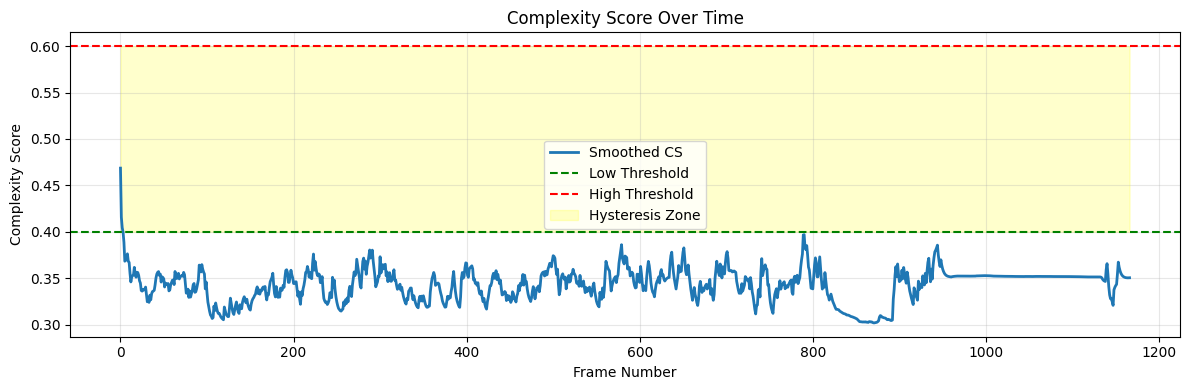


📈 Complexity score plot saved!



In [ ]:
"""
Adaptive Dual-Mode Underwater Trash Detection System
Complete Implementation for Google Colab

"""

# ==================== SETUP & INSTALLATION ====================

# Install required packages
!pip install ultralytics opencv-python-headless numpy scikit-image scipy -q

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import sobel
from skimage.measure import shannon_entropy

# ==================== CONFIGURATION ====================

class Config:
    """System configuration"""

    # Model paths (UPDATE THESE if your structure is different)
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths (UPDATE THESE with your video)
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/manythings.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_adaptive_detection.mp4'

    # Class names (based on your training)
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # Control algorithm parameters
    THRESHOLD_LOW = 0.4
    THRESHOLD_HIGH = 0.6
    SMOOTHING_ALPHA = 0.3
    MIN_FRAMES_BETWEEN_SWITCH = 30

    # Weight strategy: 'equal', 'category', or 'expert'
    WEIGHT_STRATEGY = 'expert'

    # Display settings
    SHOW_PARAMS = True  # Show parameter values on frame
    SHOW_TOP_PARAMS = 3  # Show top N contributing parameters

# ==================== PARAMETER WEIGHTS ====================

WEIGHT_STRATEGIES = {
    'equal': {f'w{i}': 0.05 for i in range(1, 21)},

    'category': {
        **{f'w{i}': 0.0625 for i in range(1, 9)},    # Scene: 50%
        **{f'w{i}': 0.05 for i in range(9, 15)},     # Model: 30%
        **{f'w{i}': 0.0333 for i in range(15, 21)}   # Task: 20%
    },

    'expert': {
        'w1': 0.08, 'w2': 0.06, 'w3': 0.07, 'w4': 0.07, 'w5': 0.05,
        'w6': 0.04, 'w7': 0.06, 'w8': 0.05, 'w9': 0.08, 'w10': 0.05,
        'w11': 0.04, 'w12': 0.06, 'w13': 0.04, 'w14': 0.05, 'w15': 0.06,
        'w16': 0.05, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
    }
}

# ==================== PARAMETER EXTRACTORS ====================

class ParameterExtractor:
    """Extract all 20 parameters from frame and detections"""

    def __init__(self):
        self.prev_frame = None
        self.flow_history = deque(maxlen=5)

    def extract_all(self, frame, detections, model_metrics):
        """
        Extract all 20 parameters

        Args:
            frame: Current video frame (numpy array)
            detections: YOLO detection results
            model_metrics: Dict with model performance data

        Returns:
            Dict with keys p1-p20, all normalized to [0,1]
        """
        params = {}

        # Scene Parameters (P1-P8)
        params['p1'] = self._turbidity(frame)
        params['p2'] = self._lighting_variation(frame)
        params['p3'] = self._object_density(detections, frame.shape)
        params['p4'] = self._occlusion_level(detections)
        params['p5'] = self._motion_blur(frame)
        params['p6'] = self._camera_stability(frame)
        params['p7'] = self._color_cast(frame)
        params['p8'] = self._texture_richness(frame)

        # Model Parameters (P9-P14)
        params['p9'] = self._low_confidence(detections)
        params['p10'] = model_metrics.get('conf_variance', 0.5)
        params['p11'] = model_metrics.get('latency_ratio', 0.5)
        params['p12'] = model_metrics.get('dropout_rate', 0.5)
        params['p13'] = self._false_positive_estimate(detections)
        params['p14'] = model_metrics.get('energy_ratio', 0.5)

        # Task Parameters (P15-P20) - Defaults for prototype
        params['p15'] = 0.5  # Battery (default: 50%)
        params['p16'] = 0.5  # Mission phase (default: mid-mission)
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5  # Distance to zone (default: mid-range)
        params['p19'] = 0.5  # Time remaining (default: 50%)
        params['p20'] = 0.5  # Bandwidth (default: moderate)

        return params

    # ===== Scene Parameter Methods =====

    def _turbidity(self, frame):
        """P1: Water turbidity - inverse of mean brightness"""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        mean_intensity = np.mean(gray) / 255.0
        return 1.0 - mean_intensity

    def _lighting_variation(self, frame):
        """P2: Lighting variation - coefficient of variation"""
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        l_channel = lab[:, :, 0]
        std = np.std(l_channel)
        mean = np.mean(l_channel)
        cv = std / (mean + 1e-6)
        return min(cv / 2.0, 1.0)  # Normalize, cap at 1.0

    def _object_density(self, detections, frame_shape):
        """P3: Number of objects per frame area"""
        if detections is None or len(detections) == 0:
            return 0.0

        num_objects = len(detections.boxes)
        frame_area = frame_shape[0] * frame_shape[1]
        density = num_objects / frame_area
        return min(density / 0.01, 1.0)  # Normalize (1% coverage = max)

    def _occlusion_level(self, detections):
        """P4: Average IoU between bounding boxes"""
        if detections is None or len(detections.boxes) < 2:
            return 0.0

        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []

        for i in range(len(boxes)):
            for j in range(i + 1, len(boxes)):
                iou = self._calculate_iou(boxes[i], boxes[j])
                ious.append(iou)

        return np.mean(ious) if ious else 0.0

    def _calculate_iou(self, box1, box2):
        """Calculate IoU between two boxes"""
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union = area1 + area2 - intersection

        return intersection / (union + 1e-6)

    def _motion_blur(self, frame):
        """P5: Motion blur using Laplacian variance"""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        # Higher variance = sharper image
        # Normalize: sharp image (~1000) = 0, blurry (~100) = 1
        blur_score = 1.0 - min(variance / 1000.0, 1.0)
        return max(0.0, blur_score)

    def _camera_stability(self, frame):
        """P6: Camera shake using optical flow magnitude"""
        if self.prev_frame is None:
            self.prev_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            return 0.0

        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calculate optical flow
        flow = cv2.calcOpticalFlowFarneback(
            self.prev_frame, curr_gray, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )

        # Calculate mean flow magnitude
        magnitude = np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)
        mean_magnitude = np.mean(magnitude)

        self.prev_frame = curr_gray

        # Normalize: 50 pixels = max instability
        return min(mean_magnitude / 50.0, 1.0)

    def _color_cast(self, frame):
        """P7: Color cast severity (blue/green underwater bias)"""
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        g_mean = np.mean(g) / 255.0
        b_mean = np.mean(b) / 255.0

        # Calculate maximum deviation from gray
        max_diff = max(
            abs(r_mean - g_mean),
            abs(g_mean - b_mean),
            abs(b_mean - r_mean)
        )

        return max_diff

    def _texture_richness(self, frame):
        """P8: Texture complexity using Shannon entropy"""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        entropy = shannon_entropy(gray)
        # Normalize: 8-bit image max entropy = 8
        return min(entropy / 8.0, 1.0)

    # ===== Model Parameter Methods =====

    def _low_confidence(self, detections):
        """P9: 1 - mean confidence score"""
        if detections is None or len(detections.boxes) == 0:
            return 1.0  # No detections = low confidence

        confidences = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(confidences)
        return 1.0 - mean_conf

    def _false_positive_estimate(self, detections):
        """P13: Estimate false positives (low confidence detections)"""
        if detections is None or len(detections.boxes) == 0:
            return 0.0

        confidences = detections.boxes.conf.cpu().numpy()
        low_conf_count = np.sum(confidences < 0.5)
        return low_conf_count / len(confidences)

    def _trash_priority(self, detections):
        """P17: Priority based on detected trash types"""
        if detections is None or len(detections.boxes) == 0:
            return 0.0

        # Priority mapping for your classes
        priority_map = {
            'Bio': 0.3,      # Lower priority (organic)
            'Rov': 0.2,      # Equipment (monitoring)
            'Trash': 1.0     # High priority (actual trash)
        }

        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]

        return max(priorities) if priorities else 0.0

# ==================== CONTROL ALGORITHM ====================

class ComplexityScoreFilter:
    """Exponential Moving Average filter for smoothing"""

    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class ModelSwitcher:
    """Hysteresis-based model switching controller"""

    def __init__(self, threshold_low=0.4, threshold_high=0.6, min_frames=30):
        self.threshold_low = threshold_low
        self.threshold_high = threshold_high
        self.min_frames = min_frames

        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.switch_history = []

    def decide(self, cs_smooth, frame_num):
        self.frames_since_switch += 1
        switched = False

        if self.frames_since_switch < self.min_frames:
            return self.current_model, switched

        # Switching logic with hysteresis
        if cs_smooth < self.threshold_low and self.current_model == "YOLOv8x":
            self.current_model = "YOLOv8n"
            self.frames_since_switch = 0
            switched = True
            self.switch_history.append({
                'frame': frame_num,
                'direction': 'down',
                'cs': cs_smooth
            })

        elif cs_smooth > self.threshold_high and self.current_model == "YOLOv8n":
            self.current_model = "YOLOv8x"
            self.frames_since_switch = 0
            switched = True
            self.switch_history.append({
                'frame': frame_num,
                'direction': 'up',
                'cs': cs_smooth
            })

        return self.current_model, switched

class AdaptiveController:
    """Main adaptive control system"""

    def __init__(self, weights, config):
        self.weights = weights
        self.config = config

        self.score_filter = ComplexityScoreFilter(alpha=config.SMOOTHING_ALPHA)
        self.switcher = ModelSwitcher(
            threshold_low=config.THRESHOLD_LOW,
            threshold_high=config.THRESHOLD_HIGH,
            min_frames=config.MIN_FRAMES_BETWEEN_SWITCH
        )

        # Metrics tracking
        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0

    def calculate_complexity_score(self, parameters):
        """Calculate weighted complexity score"""
        cs_raw = 0.0
        for i in range(1, 21):
            cs_raw += self.weights[f'w{i}'] * parameters[f'p{i}']
        return max(0.0, min(1.0, cs_raw))

    def process_frame(self, parameters, frame_num):
        """Main control loop for one frame"""
        # Calculate raw complexity score
        cs_raw = self.calculate_complexity_score(parameters)

        # Apply smoothing
        cs_smooth = self.score_filter.update(cs_raw)

        # Make switching decision
        model_name, switched = self.switcher.decide(cs_smooth, frame_num)

        # Log metrics
        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model_name)
        if switched:
            self.switch_count += 1

        return {
            'model': model_name,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'parameters': parameters
        }

    def get_top_contributors(self, parameters, n=3):
        """Get top N contributing parameters"""
        contributions = []
        for i in range(1, 21):
            contrib = self.weights[f'w{i}'] * parameters[f'p{i}']
            contributions.append((f'P{i}', contrib))

        contributions.sort(key=lambda x: x[1], reverse=True)
        return contributions[:n]

# ==================== VIDEO PROCESSING ====================

class VideoProcessor:
    """Process video with adaptive detection"""

    def __init__(self, model_n, model_x, controller, param_extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.param_extractor = param_extractor
        self.config = config

        self.frame_count = 0
        self.fps_history = deque(maxlen=30)
        self.conf_history = deque(maxlen=30)

    def annotate_frame(self, frame, detections, decision):
        """Add annotations to frame"""
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections with class labels and confidence
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                # Draw bounding box
                color = (0, 255, 0) if conf > 0.5 else (0, 255, 255)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

                # Draw label with confidence
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(annotated, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
                cv2.putText(annotated, text, (x1, y1 - 2),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

        # Create overlay panel for system info
        overlay = np.zeros((120, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        # Model name
        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 0, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, model_color, 2)

        # Complexity Score
        cs_color = (0, 255, 0) if decision['cs_smooth'] < 0.4 else \
                   (0, 0, 255) if decision['cs_smooth'] > 0.6 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {decision['cs_smooth']:.3f}", (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, cs_color, 2)

        # CS bar visualization
        bar_width = int(decision['cs_smooth'] * 300)
        cv2.rectangle(overlay, (10, 70), (310, 90), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, 70), (10 + bar_width, 90), cs_color, -1)

        # Threshold markers
        low_x = int(self.config.THRESHOLD_LOW * 300) + 10
        high_x = int(self.config.THRESHOLD_HIGH * 300) + 10
        cv2.line(overlay, (low_x, 70), (low_x, 90), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, 70), (high_x, 90), (255, 255, 255), 2)

        # Top contributing parameters
        if self.config.SHOW_PARAMS:
            top_params = self.controller.get_top_contributors(decision['parameters'],
                                                              self.config.SHOW_TOP_PARAMS)
            x_offset = 350
            cv2.putText(overlay, "Top Contributors:", (x_offset, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            for i, (param, contrib) in enumerate(top_params):
                text = f"{param}: {contrib:.3f}"
                cv2.putText(overlay, text, (x_offset, 55 + i * 25),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

        # Frame counter
        cv2.putText(overlay, f"Frame: {self.frame_count}", (w - 150, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        # Stack overlay on top of frame
        annotated = np.vstack([overlay, annotated])

        return annotated

    def process_video(self, input_path, output_path):
        """Main video processing loop"""
        cap = cv2.VideoCapture(input_path)

        # Get video properties
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Create video writer (add 120px for overlay)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height + 120))

        print(f"Processing video: {total_frames} frames @ {fps} FPS")
        print(f"Resolution: {width}x{height}")
        print("=" * 60)

        models = {'YOLOv8n': self.model_n, 'YOLOv8x': self.model_x}

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run inference with appropriate model
            start_time = time.time()

            # Get current model decision (use previous decision for first frame)
            if self.frame_count == 1:
                current_model_name = 'YOLOv8n'
            else:
                current_model_name = self.controller.switcher.current_model

            current_model = models[current_model_name]
            detections = current_model(frame, verbose=False)[0]

            inference_time = time.time() - start_time

            # Calculate model metrics
            model_metrics = {
                'conf_variance': np.std(list(self.conf_history)) if len(self.conf_history) > 0 else 0.5,
                'latency_ratio': max(0, 1 - (1.0 / (inference_time + 0.001)) / 30),  # Assume 30 FPS target
                'dropout_rate': 0.5,  # Would need tracking across frames
                'energy_ratio': 0.5   # Would need GPU power monitoring
            }

            # Update confidence history
            if len(detections.boxes) > 0:
                mean_conf = float(detections.boxes.conf.mean().cpu().numpy())
                self.conf_history.append(mean_conf)

            # Extract parameters
            parameters = self.param_extractor.extract_all(frame, detections, model_metrics)

            # Get control decision
            decision = self.controller.process_frame(parameters, self.frame_count)

            # Annotate frame
            annotated_frame = self.annotate_frame(frame, detections, decision)

            # Write frame
            out.write(annotated_frame)

            # Progress update
            if self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"Frame {self.frame_count}/{total_frames} ({progress:.1f}%) | "
                      f"Model: {current_model_name} | CS: {decision['cs_smooth']:.3f} | "
                      f"Switches: {self.controller.switch_count}")

        cap.release()
        out.release()

        print("=" * 60)
        print(f"✅ Processing complete!")
        print(f"Total frames: {self.frame_count}")
        print(f"Total switches: {self.controller.switch_count}")
        print(f"Output saved: {output_path}")

        return self.controller

# ==================== MAIN EXECUTION ====================

def main():
    """Main execution function"""

    print("🌊 Adaptive Dual-Mode Underwater Trash Detection System")
    print("=" * 60)

    # Load models
    print("Loading models...")
    model_n = YOLO(Config.MODEL_N_PATH)
    model_x = YOLO(Config.MODEL_X_PATH)
    print(f"✅ YOLOv8n loaded from: {Config.MODEL_N_PATH}")
    print(f"✅ YOLOv8x loaded from: {Config.MODEL_X_PATH}")
    print()

    # Initialize components
    weights = WEIGHT_STRATEGIES[Config.WEIGHT_STRATEGY]
    controller = AdaptiveController(weights, Config)
    param_extractor = ParameterExtractor()

    print(f"Control settings:")
    print(f"  Weight strategy: {Config.WEIGHT_STRATEGY}")
    print(f"  Threshold low: {Config.THRESHOLD_LOW}")
    print(f"  Threshold high: {Config.THRESHOLD_HIGH}")
    print(f"  Smoothing alpha: {Config.SMOOTHING_ALPHA}")
    print()

    # Create video processor
    processor = VideoProcessor(model_n, model_x, controller, param_extractor, Config)

    # Process video
    print("Starting video processing...")
    final_controller = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)

    # Generate report
    print("\n📊 Final Report:")
    print(f"  Average CS: {np.mean(final_controller.cs_smooth_history):.3f}")
    print(f"  CS Range: [{min(final_controller.cs_smooth_history):.3f}, "
          f"{max(final_controller.cs_smooth_history):.3f}]")
    print(f"  Switch rate: {final_controller.switch_count / processor.frame_count * 100:.2f}% of frames")

    # Model usage statistics
    model_usage = {
        'YOLOv8n': final_controller.model_history.count('YOLOv8n'),
        'YOLOv8x': final_controller.model_history.count('YOLOv8x')
    }
    print(f"\n  Model usage:")
    for model, count in model_usage.items():
        percentage = (count / len(final_controller.model_history)) * 100
        print(f"    {model}: {count} frames ({percentage:.1f}%)")


    return final_controller

# ==================== RUN ====================

if __name__ == "__main__":
    # Run the system
    controller = main()

    # Optional: Plot complexity score over time
    plt.figure(figsize=(12, 4))
    plt.plot(controller.cs_smooth_history, label='Smoothed CS', linewidth=2)
    plt.axhline(y=Config.THRESHOLD_LOW, color='g', linestyle='--', label='Low Threshold')
    plt.axhline(y=Config.THRESHOLD_HIGH, color='r', linestyle='--', label='High Threshold')
    plt.fill_between(range(len(controller.cs_smooth_history)),
                     Config.THRESHOLD_LOW, Config.THRESHOLD_HIGH,
                     alpha=0.2, color='yellow', label='Hysteresis Zone')
    plt.xlabel('Frame Number')
    plt.ylabel('Complexity Score')
    plt.legend()
    plt.title('Complexity Score Over Time')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/complexity_score_plot.png', dpi=150)
    plt.show()

    print("\n📈 Complexity score plot saved!")

    # Optional: Plot model switching events
    if controller.switcher.switch_history:
        plt.figure(figsize=(12, 3))
        switch_frames = [s['frame'] for s in controller.switcher.switch_history]
        switch_types = [1 if s['direction'] == 'up' else -1 for s in controller.switcher.switch_history]
        colors = ['red' if t == 1 else 'green' for t in switch_types]

        plt.scatter(switch_frames, switch_types, c=colors, s=100, marker='|', linewidths=3)
        plt.xlabel('Frame Number')
        plt.ylabel('Switch Direction')
        plt.yticks([-1, 1], ['↓ to YOLOv8n', '↑ to YOLOv8x'])
        plt.title(f'Model Switching Events (Total: {len(switch_frames)})')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/switching_events_plot.png', dpi=150)
        plt.show()

        print("📊 Switching events plot saved!")

    print("\n" + "="*60)
    print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading models...
✅ YOLOv8n
✅ YOLOv8x

🌊 Adaptive Dual-Mode System v2.0
Video: 300 frames @ 30 FPS | 1080x1920
Thresholds: 0.4/0.6
Dynamic Weights: ON
[  30/300]  10.0% | YOLOv8n  | CS: 0.470 | SW:  0
[  60/300]  20.0% | YOLOv8n  | CS: 0.485 | SW:  0
[  90/300]  30.0% | YOLOv8n  | CS: 0.464 | SW:  0
[ 120/300]  40.0% | YOLOv8n  | CS: 0.503 | SW:  0
[ 150/300]  50.0% | YOLOv8n  | CS: 0.490 | SW:  0
[ 180/300]  60.0% | YOLOv8n  | CS: 0.460 | SW:  0
[ 210/300]  70.0% | YOLOv8n  | CS: 0.432 | SW:  0
[ 240/300]  80.0% | YOLOv8n  | CS: 0.563 | SW:  0
[ 270/300]  90.0% | YOLOv8n  | CS: 0.505 | SW:  0
[ 300/300] 100.0% | YOLOv8n  | CS: 0.482 | SW:  0
✅ Complete! Saved: /content/drive/MyDrive/output_adaptive_ocean.mp4

📊 REPORT
Avg CS: 0.492
Range: [0.415, 0.584]
Switches: 0

YOLOv8n: 300 (100.0%)
YOLOv8x: 0 (0.0%)

Energy Savings: 70.0%

📈 Generating plots...


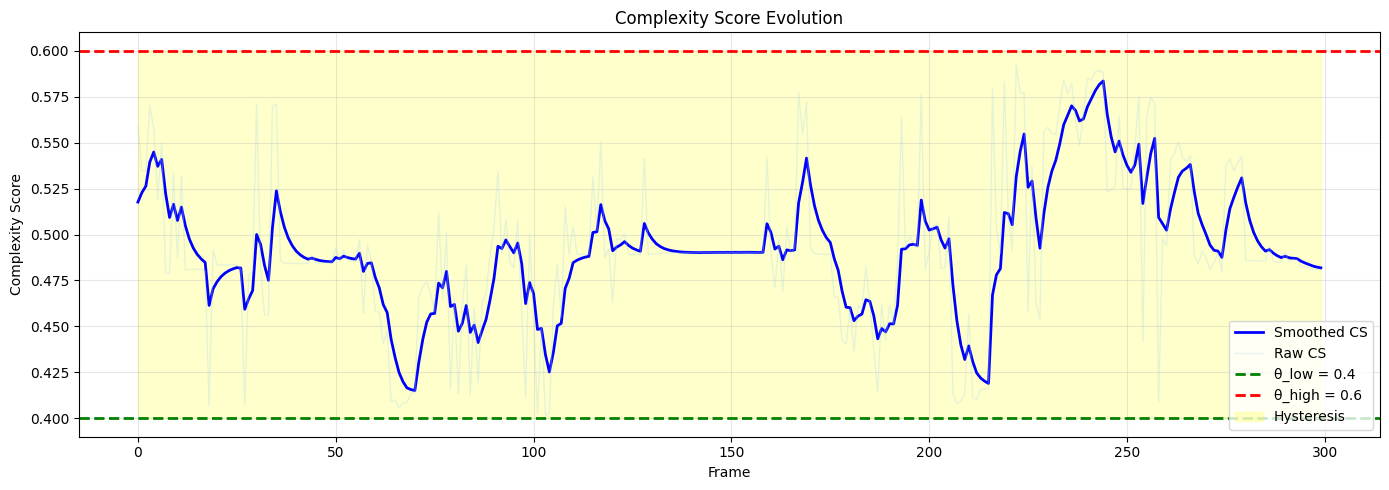

✅ cs_plot_v2.png


In [ ]:
"""
Adaptive Dual-Mode Underwater Trash Detection System
Complete Implementation - Version 2.0

Features:
- Independent scene parameters (redesigned P1-P8)
- Dynamic context-aware weight adaptation
- Research-justified thresholds (0.40/0.60)
- Enhanced parameter extraction
"""

# ==================== SETUP & INSTALLATION ====================

!pip install ultralytics opencv-python-headless numpy scikit-image scipy -q

from google.colab import drive
drive.mount('/content/drive')

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from skimage.measure import shannon_entropy
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """System configuration"""
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/Deep ocean technology offers never before seen images of lost WWI submarine.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_adaptive_ocean.mp4'
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']
    THRESHOLD_LOW = 0.40
    THRESHOLD_HIGH = 0.60
    SMOOTHING_ALPHA = 0.3
    MIN_FRAMES_BETWEEN_SWITCH = 30
    USE_DYNAMIC_WEIGHTS = True
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

BASE_WEIGHTS = {'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
                'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
                'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
                'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02}

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)
        self.position_history = {}

    def extract_all(self, frame, detections, model_metrics):
        params = {}
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5
        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== DYNAMIC WEIGHTS ====================

class DynamicWeightController:
    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()
        self.thresholds = {'p1': 0.6, 'p3': 0.6, 'p5': 0.7, 'p6': 0.6, 'p7': 0.7,
                          'p8': 0.6, 'p9': 0.6, 'p11': 0.6, 'p12': 0.6, 'p15': 0.7, 'p17': 0.8}

    def compute_dynamic_weights(self, params):
        weights = self.base_weights.copy()
        active = [p for p, t in self.thresholds.items() if params[p] > t]

        if len(active) > 0:
            boost = 1.0 + (len(active) * 0.25)
            for p in active:
                weights[p.replace('p','w')] *= boost

        weights = self._apply_rules(params, weights)
        total = sum(weights.values())
        return {k: v/total for k, v in weights.items()}

    def _apply_rules(self, p, w):
        if p['p1'] > 0.6 and p['p6'] > 0.6:
            w['w1'] *= 1.5
            w['w6'] *= 1.5
        if p['p9'] > 0.6 and p['p7'] > 0.7:
            w['w9'] *= 2.0
            w['w7'] *= 1.8
        if p['p15'] > 0.7 and p['p17'] > 0.8:
            w['w17'] *= 2.5
            w['w15'] *= 0.5
        if p['p12'] > 0.6 and p['p8'] > 0.6:
            w['w12'] *= 1.8
            w['w8'] *= 1.8
        if p['p3'] > 0.6 and p['p5'] > 0.6:
            w['w3'] *= 1.7
            w['w5'] *= 1.7
        if p['p6'] > 0.6 and p['p9'] > 0.6:
            w['w6'] *= 1.6
            w['w9'] *= 1.6
        return w

# ==================== CONTROL SYSTEM ====================

class ComplexityScoreFilter:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class ModelSwitcher:
    def __init__(self, threshold_low=0.40, threshold_high=0.60, min_frames=30):
        self.threshold_low = threshold_low
        self.threshold_high = threshold_high
        self.min_frames = min_frames
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.switch_history = []

    def decide(self, cs_smooth, frame_num):
        self.frames_since_switch += 1
        switched = False

        if self.frames_since_switch < self.min_frames:
            return self.current_model, switched

        if cs_smooth < self.threshold_low and self.current_model == "YOLOv8x":
            self.current_model = "YOLOv8n"
            self.frames_since_switch = 0
            switched = True
            self.switch_history.append({'frame': frame_num, 'direction': 'down', 'cs': cs_smooth})
        elif cs_smooth > self.threshold_high and self.current_model == "YOLOv8n":
            self.current_model = "YOLOv8x"
            self.frames_since_switch = 0
            switched = True
            self.switch_history.append({'frame': frame_num, 'direction': 'up', 'cs': cs_smooth})

        return self.current_model, switched

class AdaptiveController:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(alpha=config.SMOOTHING_ALPHA)
        self.switcher = ModelSwitcher(config.THRESHOLD_LOW, config.THRESHOLD_HIGH, config.MIN_FRAMES_BETWEEN_SWITCH)
        self.weight_controller = DynamicWeightController(base_weights) if config.USE_DYNAMIC_WEIGHTS else None
        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.weight_history = []
        self.switch_count = 0

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        weights = self.weight_controller.compute_dynamic_weights(params) if self.weight_controller else self.base_weights
        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)
        model, switched = self.switcher.decide(cs_smooth, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())
        if switched:
            self.switch_count += 1

        return {'model': model, 'cs_raw': cs_raw, 'cs_smooth': cs_smooth,
                'switched': switched, 'parameters': params, 'weights': weights}

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0

    def annotate_frame(self, frame, detections, decision):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]
                color = (0, 255, 0) if conf > 0.5 else (0, 255, 255)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(annotated, (x1, y1-th-4), (x1+tw, y1), color, -1)
                cv2.putText(annotated, text, (x1, y1-2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

        overlay = np.zeros((140, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.4 else (0, 0, 255) if cs > 0.6 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        bar_width = int(cs * 400)
        cv2.rectangle(overlay, (10, 60), (410, 80), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, 60), (10+bar_width, 80), cs_color, -1)

        low_x = int(0.4 * 400) + 10
        high_x = int(0.6 * 400) + 10
        cv2.line(overlay, (low_x, 60), (low_x, 80), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, 60), (high_x, 80), (255, 255, 255), 2)

        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 450
            cv2.putText(overlay, "Top 5:", (x_off, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
            for i, (p, c, w) in enumerate(tops):
                cv2.putText(overlay, f"{p}: {c:.3f}", (x_off, 40+i*18), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200,200,200), 1)

        cv2.putText(overlay, f"Frame: {self.frame_count}", (int(w)-150, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(overlay, f"Switches: {self.controller.switch_count}", (int(w)-150, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        if self.config.USE_DYNAMIC_WEIGHTS:
            cv2.putText(overlay, "Dynamic Weights: ON", (10, 130), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h+140))

        print("🌊 Adaptive Dual-Mode System v2.0")
        print("="*70)
        print(f"Video: {total} frames @ {fps} FPS | {w}x{h}")
        print(f"Thresholds: {self.config.THRESHOLD_LOW}/{self.config.THRESHOLD_HIGH}")
        print(f"Dynamic Weights: {'ON' if self.config.USE_DYNAMIC_WEIGHTS else 'OFF'}")
        print("="*70)

        models = {'YOLOv8n': self.model_n, 'YOLOv8x': self.model_x}

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1
            current_model_name = 'YOLOv8n' if self.frame_count == 1 else self.controller.switcher.current_model
            detections = models[current_model_name](frame, verbose=False)[0]
            params = self.extractor.extract_all(frame, detections, {})
            decision = self.controller.process_frame(params, self.frame_count)
            annotated = self.annotate_frame(frame, detections, decision)
            out.write(annotated)

            if self.frame_count % 30 == 0 or decision['switched']:
                prog = (self.frame_count / total) * 100
                sw = " 🔄" if decision['switched'] else ""
                print(f"[{self.frame_count:4d}/{total}] {prog:5.1f}% | {current_model_name:8s} | CS: {decision['cs_smooth']:.3f} | SW: {self.controller.switch_count:2d}{sw}")

        cap.release()
        out.release()
        print("="*70)
        print(f"✅ Complete! Saved: {output_path}")
        return self.controller

# ==================== MAIN ====================

def main():
    print("Loading models...")
    model_n = YOLO(Config.MODEL_N_PATH)
    model_x = YOLO(Config.MODEL_X_PATH)
    print(f"✅ YOLOv8n\n✅ YOLOv8x\n")

    controller = AdaptiveController(BASE_WEIGHTS, Config)
    extractor = EnhancedParameterExtractor()
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

    final = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)

    print("\n📊 REPORT")
    print("="*70)
    print(f"Avg CS: {np.mean(final.cs_smooth_history):.3f}")
    print(f"Range: [{min(final.cs_smooth_history):.3f}, {max(final.cs_smooth_history):.3f}]")
    print(f"Switches: {final.switch_count}")

    n_count = final.model_history.count('YOLOv8n')
    x_count = final.model_history.count('YOLOv8x')
    print(f"\nYOLOv8n: {n_count} ({n_count/len(final.model_history)*100:.1f}%)")
    print(f"YOLOv8x: {x_count} ({x_count/len(final.model_history)*100:.1f}%)")

    energy_saved = (1 - (n_count*15 + x_count*50)/(len(final.model_history)*50)) * 100
    print(f"\nEnergy Savings: {energy_saved:.1f}%")
    print("="*70)

    return final

if __name__ == "__main__":
    controller = main()

    print("\n📈 Generating plots...")

    plt.figure(figsize=(14, 5))
    plt.plot(controller.cs_smooth_history, 'b-', linewidth=2, label='Smoothed CS')
    plt.plot(controller.cs_history, 'lightblue', linewidth=1, alpha=0.3, label='Raw CS')
    plt.axhline(0.4, color='g', linestyle='--', linewidth=2, label='θ_low = 0.4')
    plt.axhline(0.6, color='r', linestyle='--', linewidth=2, label='θ_high = 0.6')
    plt.fill_between(range(len(controller.cs_smooth_history)), 0.4, 0.6, alpha=0.2, color='yellow', label='Hysteresis')
    plt.xlabel('Frame'); plt.ylabel('Complexity Score')
    plt.title('Complexity Score Evolution')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/cs_plot_v2.png', dpi=150)
    plt.show()
    print("✅ cs_plot_v2.png")

    if controller.switcher.switch_history:
        plt.figure(figsize=(14, 4))
        frames = [s['frame'] for s in controller.switcher.switch_history]
        types = [1 if s['direction']=='up' else -1 for s in controller.switcher.switch_history]
        colors = ['red' if t==1 else 'green' for t in types]
        plt.scatter(frames, types, c=colors, s=150, marker='|', linewidths=4)
        plt.xlabel('Frame'); plt.ylabel('Switch')
        plt.yticks([-1,1], ['↓ YOLOv8n', '↑ YOLOv8x'])
        plt.title(f'Switching Events ({len(frames)} total)')
        plt.grid(alpha=0.3, axis='x'); plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/switches_v2.png', dpi=150)
        plt.show()
        print("✅ switches_v2.png")


In [ ]:
import cv2

def extract_segment(input_video, output_video, start_frame, end_frame):
    """Extract a segment from video"""
    cap = cv2.VideoCapture(input_video)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    for i in range(start_frame, end_frame):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)

    cap.release()
    out.release()
    print(f"✅ Extracted frames {start_frame}-{end_frame} to {output_video}")

# Example: Extract 3 different segments
extract_segment('manythings.mp4', 'segment1_clear.mp4', 0, 300)      # First 10 seconds
extract_segment('manythings.mp4', 'segment2_middle.mp4', 500, 800)   # Middle part
extract_segment('manythings.mp4', 'segment3_end.mp4', 1000, 1300)    # End part

✅ Extracted frames 0-300 to segment1_clear.mp4
✅ Extracted frames 500-800 to segment2_middle.mp4
✅ Extracted frames 1000-1300 to segment3_end.mp4


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading models...
✅ YOLOv8n
✅ YOLOv8x

🌊 Adaptive Dual-Mode System v2.0
Video: 4615 frames @ 29 FPS | 1280x720
Thresholds: 0.45/0.55
Dynamic Weights: ON
[  30/4615]   0.7% | YOLOv8n  | CS: 0.514 | SW:  0
[  60/4615]   1.3% | YOLOv8n  | CS: 0.520 | SW:  0
[  90/4615]   2.0% | YOLOv8n  | CS: 0.528 | SW:  0
[ 120/4615]   2.6% | YOLOv8n  | CS: 0.542 | SW:  0
[ 150/4615]   3.3% | YOLOv8n  | CS: 0.511 | SW:  0
[ 180/4615]   3.9% | YOLOv8n  | CS: 0.510 | SW:  0
[ 210/4615]   4.6% | YOLOv8n  | CS: 0.530 | SW:  0
[ 240/4615]   5.2% | YOLOv8n  | CS: 0.511 | SW:  0
[ 270/4615]   5.9% | YOLOv8n  | CS: 0.518 | SW:  0
[ 300/4615]   6.5% | YOLOv8n  | CS: 0.518 | SW:  0
[ 330/4615]   7.2% | YOLOv8n  | CS: 0.514 | SW:  0
[ 360/4615]   7.8% | YOLOv8n  | CS: 0.512 | SW:  0
[ 390/4615]   8.5% | YOLOv8n  | CS: 0.520 | SW:  0
[ 420/4615]   9.1% | YOLOv8n  | CS: 0.489 | SW:  0
[ 44

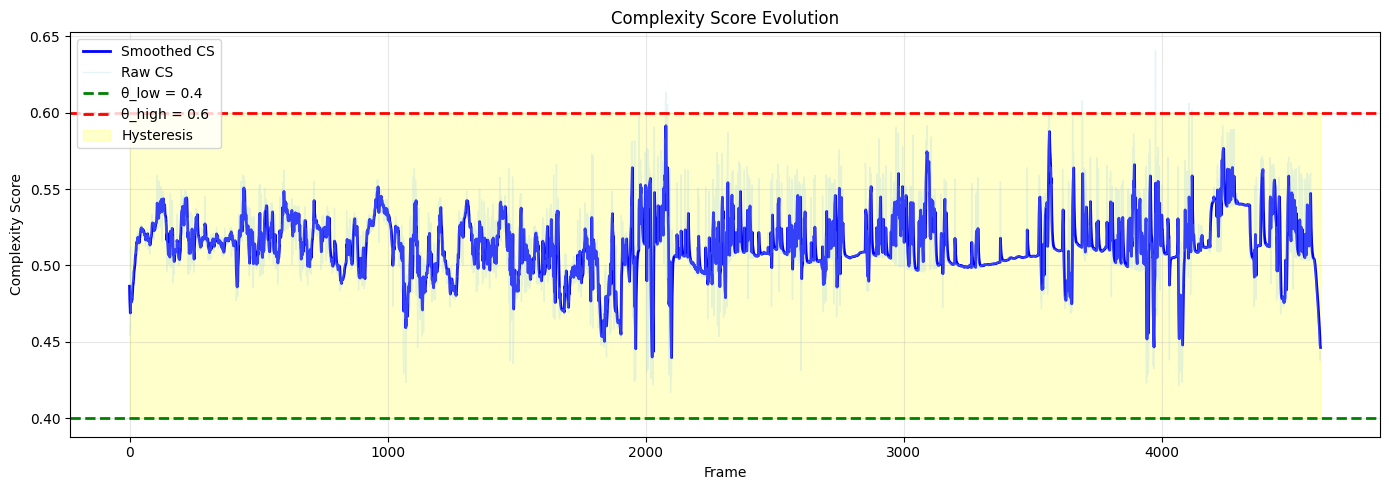

✅ cs_plot_v2.png


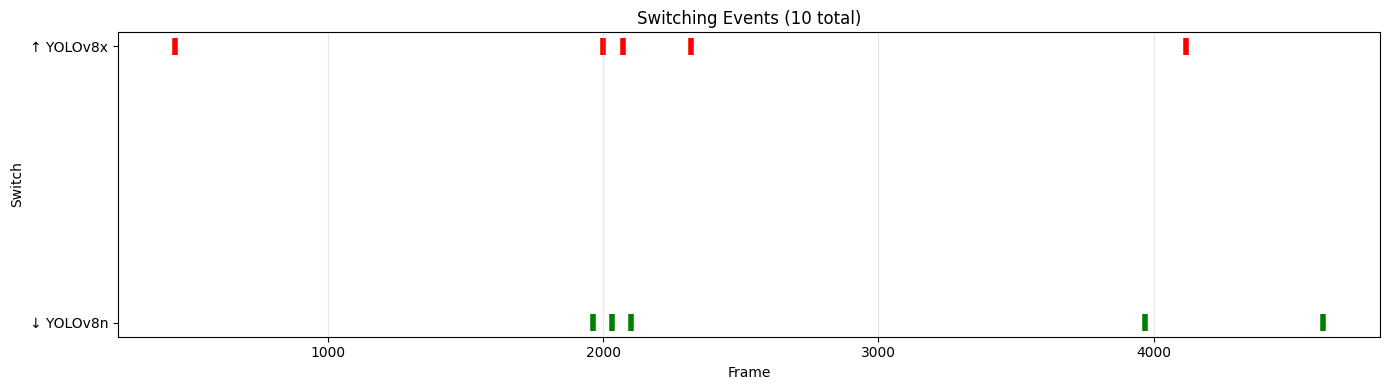

✅ switches_v2.png


In [ ]:
"""
Adaptive Dual-Mode Underwater Trash Detection System
Complete Implementation - Version 2.0

Features:
- Independent scene parameters (redesigned P1-P8)
- Dynamic context-aware weight adaptation
- Research-justified thresholds (0.40/0.60)
- Enhanced parameter extraction
"""

# ==================== SETUP & INSTALLATION ====================

!pip install ultralytics opencv-python-headless numpy scikit-image scipy -q

from google.colab import drive
drive.mount('/content/drive')

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from skimage.measure import shannon_entropy
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """System configuration"""
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_adaptive_bali_new.mp4'
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']
    THRESHOLD_LOW = 0.45
    THRESHOLD_HIGH = 0.55
    SMOOTHING_ALPHA = 0.3
    MIN_FRAMES_BETWEEN_SWITCH = 30
    USE_DYNAMIC_WEIGHTS = True
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

BASE_WEIGHTS = {'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
                'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
                'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
                'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02}

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)
        self.position_history = {}

    def extract_all(self, frame, detections, model_metrics):
        params = {}
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5
        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== DYNAMIC WEIGHTS ====================

class DynamicWeightController:
    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()
        self.thresholds = {'p1': 0.6, 'p3': 0.6, 'p5': 0.7, 'p6': 0.6, 'p7': 0.7,
                          'p8': 0.6, 'p9': 0.6, 'p11': 0.6, 'p12': 0.6, 'p15': 0.7, 'p17': 0.8}

    def compute_dynamic_weights(self, params):
        weights = self.base_weights.copy()
        active = [p for p, t in self.thresholds.items() if params[p] > t]

        if len(active) > 0:
            boost = 1.0 + (len(active) * 0.25)
            for p in active:
                weights[p.replace('p','w')] *= boost

        weights = self._apply_rules(params, weights)
        total = sum(weights.values())
        return {k: v/total for k, v in weights.items()}

    def _apply_rules(self, p, w):
        if p['p1'] > 0.6 and p['p6'] > 0.6:
            w['w1'] *= 1.5
            w['w6'] *= 1.5
        if p['p9'] > 0.6 and p['p7'] > 0.7:
            w['w9'] *= 2.0
            w['w7'] *= 1.8
        if p['p15'] > 0.7 and p['p17'] > 0.8:
            w['w17'] *= 2.5
            w['w15'] *= 0.5
        if p['p12'] > 0.6 and p['p8'] > 0.6:
            w['w12'] *= 1.8
            w['w8'] *= 1.8
        if p['p3'] > 0.6 and p['p5'] > 0.6:
            w['w3'] *= 1.7
            w['w5'] *= 1.7
        if p['p6'] > 0.6 and p['p9'] > 0.6:
            w['w6'] *= 1.6
            w['w9'] *= 1.6
        return w

# ==================== CONTROL SYSTEM ====================

class ComplexityScoreFilter:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class ModelSwitcher:
    def __init__(self, threshold_low=0.40, threshold_high=0.60, min_frames=30):
        self.threshold_low = threshold_low
        self.threshold_high = threshold_high
        self.min_frames = min_frames
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.switch_history = []

    def decide(self, cs_smooth, frame_num):
        self.frames_since_switch += 1
        switched = False

        if self.frames_since_switch < self.min_frames:
            return self.current_model, switched

        if cs_smooth < self.threshold_low and self.current_model == "YOLOv8x":
            self.current_model = "YOLOv8n"
            self.frames_since_switch = 0
            switched = True
            self.switch_history.append({'frame': frame_num, 'direction': 'down', 'cs': cs_smooth})
        elif cs_smooth > self.threshold_high and self.current_model == "YOLOv8n":
            self.current_model = "YOLOv8x"
            self.frames_since_switch = 0
            switched = True
            self.switch_history.append({'frame': frame_num, 'direction': 'up', 'cs': cs_smooth})

        return self.current_model, switched

class AdaptiveController:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(alpha=config.SMOOTHING_ALPHA)
        self.switcher = ModelSwitcher(config.THRESHOLD_LOW, config.THRESHOLD_HIGH, config.MIN_FRAMES_BETWEEN_SWITCH)
        self.weight_controller = DynamicWeightController(base_weights) if config.USE_DYNAMIC_WEIGHTS else None
        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.weight_history = []
        self.switch_count = 0

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        weights = self.weight_controller.compute_dynamic_weights(params) if self.weight_controller else self.base_weights
        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)
        model, switched = self.switcher.decide(cs_smooth, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())
        if switched:
            self.switch_count += 1

        return {'model': model, 'cs_raw': cs_raw, 'cs_smooth': cs_smooth,
                'switched': switched, 'parameters': params, 'weights': weights}

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0

    def annotate_frame(self, frame, detections, decision):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]
                color = (0, 255, 0) if conf > 0.5 else (0, 255, 255)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(annotated, (x1, y1-th-4), (x1+tw, y1), color, -1)
                cv2.putText(annotated, text, (x1, y1-2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

        overlay = np.zeros((140, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.4 else (0, 0, 255) if cs > 0.6 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        bar_width = int(cs * 400)
        cv2.rectangle(overlay, (10, 60), (410, 80), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, 60), (10+bar_width, 80), cs_color, -1)

        low_x = int(0.4 * 400) + 10
        high_x = int(0.6 * 400) + 10
        cv2.line(overlay, (low_x, 60), (low_x, 80), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, 60), (high_x, 80), (255, 255, 255), 2)

        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 450
            cv2.putText(overlay, "Top 5:", (x_off, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
            for i, (p, c, w) in enumerate(tops):
                cv2.putText(overlay, f"{p}: {c:.3f}", (x_off, 40+i*18), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200,200,200), 1)

        cv2.putText(overlay, f"Frame: {self.frame_count}", (int(w)-150, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(overlay, f"Switches: {self.controller.switch_count}", (int(w)-150, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        if self.config.USE_DYNAMIC_WEIGHTS:
            cv2.putText(overlay, "Dynamic Weights: ON", (10, 130), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h+140))

        print("🌊 Adaptive Dual-Mode System v2.0")
        print("="*70)
        print(f"Video: {total} frames @ {fps} FPS | {w}x{h}")
        print(f"Thresholds: {self.config.THRESHOLD_LOW}/{self.config.THRESHOLD_HIGH}")
        print(f"Dynamic Weights: {'ON' if self.config.USE_DYNAMIC_WEIGHTS else 'OFF'}")
        print("="*70)

        models = {'YOLOv8n': self.model_n, 'YOLOv8x': self.model_x}

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1
            current_model_name = 'YOLOv8n' if self.frame_count == 1 else self.controller.switcher.current_model
            detections = models[current_model_name](frame, verbose=False)[0]
            params = self.extractor.extract_all(frame, detections, {})
            decision = self.controller.process_frame(params, self.frame_count)
            annotated = self.annotate_frame(frame, detections, decision)
            out.write(annotated)

            if self.frame_count % 30 == 0 or decision['switched']:
                prog = (self.frame_count / total) * 100
                sw = " 🔄" if decision['switched'] else ""
                print(f"[{self.frame_count:4d}/{total}] {prog:5.1f}% | {current_model_name:8s} | CS: {decision['cs_smooth']:.3f} | SW: {self.controller.switch_count:2d}{sw}")

        cap.release()
        out.release()
        print("="*70)
        print(f"✅ Complete! Saved: {output_path}")
        return self.controller

# ==================== MAIN ====================

def main():
    print("Loading models...")
    model_n = YOLO(Config.MODEL_N_PATH)
    model_x = YOLO(Config.MODEL_X_PATH)
    print(f"✅ YOLOv8n\n✅ YOLOv8x\n")

    controller = AdaptiveController(BASE_WEIGHTS, Config)
    extractor = EnhancedParameterExtractor()
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

    final = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)

    print("\n📊 REPORT")
    print("="*70)
    print(f"Avg CS: {np.mean(final.cs_smooth_history):.3f}")
    print(f"Range: [{min(final.cs_smooth_history):.3f}, {max(final.cs_smooth_history):.3f}]")
    print(f"Switches: {final.switch_count}")

    n_count = final.model_history.count('YOLOv8n')
    x_count = final.model_history.count('YOLOv8x')
    print(f"\nYOLOv8n: {n_count} ({n_count/len(final.model_history)*100:.1f}%)")
    print(f"YOLOv8x: {x_count} ({x_count/len(final.model_history)*100:.1f}%)")

    energy_saved = (1 - (n_count*15 + x_count*50)/(len(final.model_history)*50)) * 100
    print(f"\nEnergy Savings: {energy_saved:.1f}%")
    print("="*70)

    return final

if __name__ == "__main__":
    controller = main()

    print("\n📈 Generating plots...")

    plt.figure(figsize=(14, 5))
    plt.plot(controller.cs_smooth_history, 'b-', linewidth=2, label='Smoothed CS')
    plt.plot(controller.cs_history, 'lightblue', linewidth=1, alpha=0.3, label='Raw CS')
    plt.axhline(0.4, color='g', linestyle='--', linewidth=2, label='θ_low = 0.4')
    plt.axhline(0.6, color='r', linestyle='--', linewidth=2, label='θ_high = 0.6')
    plt.fill_between(range(len(controller.cs_smooth_history)), 0.4, 0.6, alpha=0.2, color='yellow', label='Hysteresis')
    plt.xlabel('Frame'); plt.ylabel('Complexity Score')
    plt.title('Complexity Score Evolution')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/cs_plot_v2.png', dpi=150)
    plt.show()
    print("✅ cs_plot_v2.png")

    if controller.switcher.switch_history:
        plt.figure(figsize=(14, 4))
        frames = [s['frame'] for s in controller.switcher.switch_history]
        types = [1 if s['direction']=='up' else -1 for s in controller.switcher.switch_history]
        colors = ['red' if t==1 else 'green' for t in types]
        plt.scatter(frames, types, c=colors, s=150, marker='|', linewidths=4)
        plt.xlabel('Frame'); plt.ylabel('Switch')
        plt.yticks([-1,1], ['↓ YOLOv8n', '↑ YOLOv8x'])
        plt.title(f'Switching Events ({len(frames)} total)')
        plt.grid(alpha=0.3, axis='x'); plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/switches_v2.png', dpi=150)
        plt.show()
        print("✅ switches_v2.png")


🔧 Installing required packages...
✅ Packages installed

📁 Mounting Google Drive...
Mounted at /content/drive
✅ Drive mounted

🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥

📋 System Configuration:
  • Layer 1: Asymmetric Thresholds (0.45/0.6)
  • Layer 2: Time + Feature Validation
  • Layer 3: Trend Detection
  • Parameters: 20 independent (P1-P20)
  • Weights: DYNAMIC (context-aware adjustment)
  • Smoothing Alpha: 0.3


⏳ Loading models...
✅ YOLOv8n loaded
✅ YOLOv8x loaded

⏳ Initializing system components...
✅ System initialized

🎬 Processing video: 1167 frames at 29 FPS
📊 Resolution: 480x360 → 480x520 (with overlay)
📹 Progress: 30/1167 (2.6%) - Model: YOLOv8n, CS: 0.502
📹 Progress: 60/1167 (5.1%) - Model: YOLOv8n, CS: 0.488
📹 Progress: 90/1167 (7.7%) - Model: YOLOv8n, CS: 0.477
📹 Progress: 120/1167 (10.3%) - Model: YOLOv8n, CS: 0.473
📹 Progress: 150/1167 (12.9%) - Model: YOLOv8n, CS: 0.473
📹 Progress: 180/1167 (15.4%) - Model: YOLOv8n, CS: 0.474
📹 Progress: 210/1167 (18.0%) - Model: 

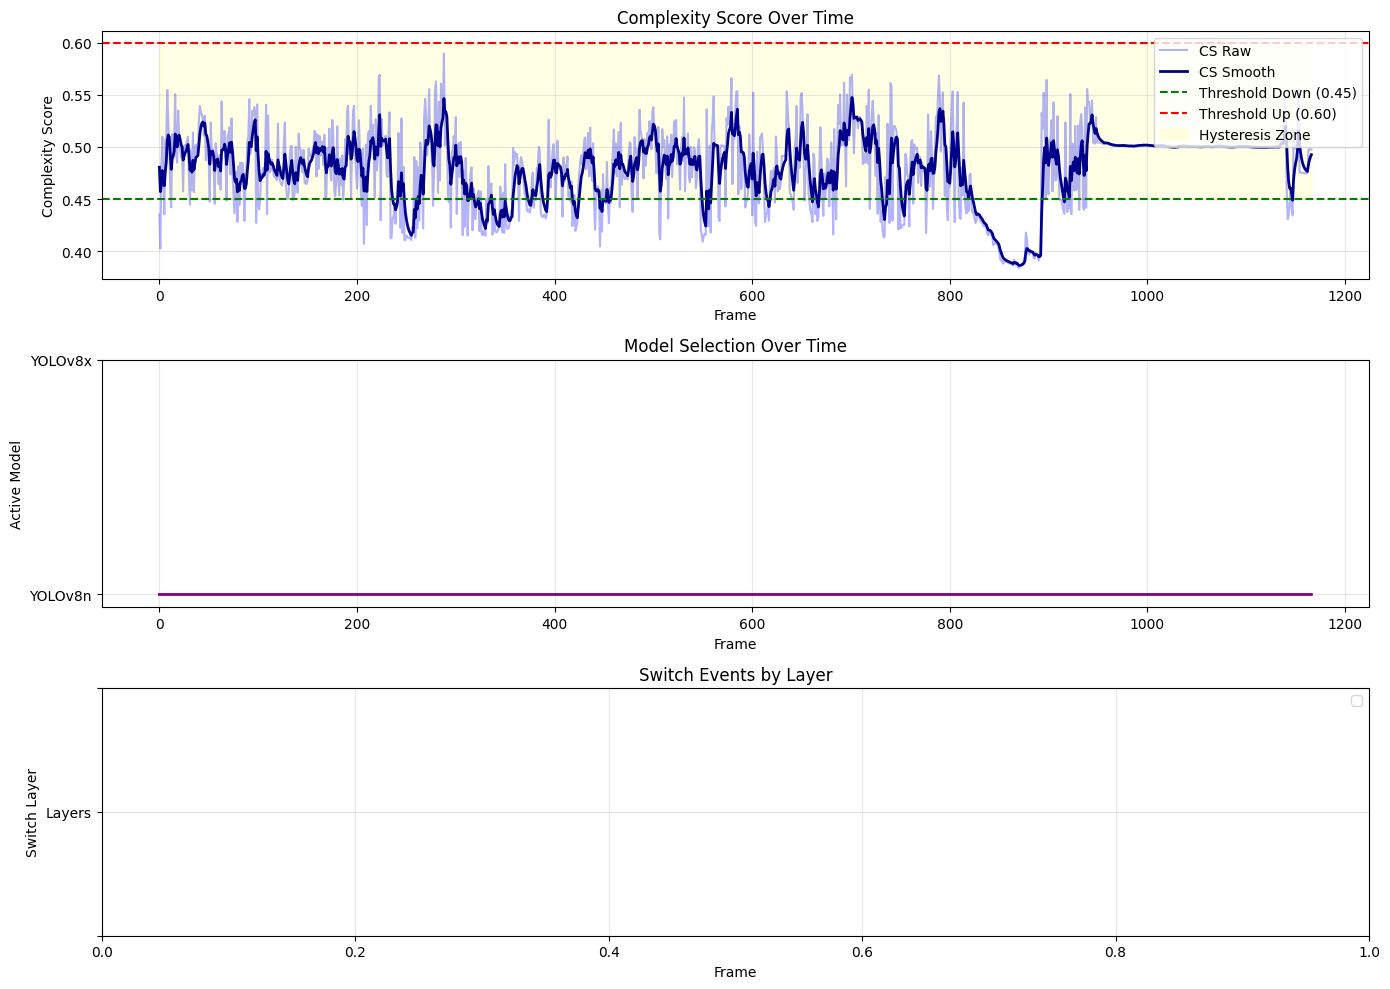


✅ All done! Check your output files.


In [ ]:
"""
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥
Complete Implementation with 3-Layer Intelligent Switching

Features:
- Layer 1: Asymmetric Thresholds (0.45/0.60)
- Layer 2: Time + Feature Validation (Enhanced)
- Layer 3: Trend Detection (Predictive)
- Independent Parameters (P1-P20)
- Dynamic Weights (Context-aware)
- Complete Logging & Visualization
"""

# ==================== SETUP ====================

# Install required packages
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', '-q'], check=True)
    print("✅ Packages installed\n")

    # Mount Google Drive
    print("📁 Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted\n")
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """Enhanced system configuration"""

    # Model paths
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/manythings.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_enhanced_v3.mp4'

    # Classes
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # ===== LAYER 1: Asymmetric Thresholds =====
    THRESHOLD_DOWN = 0.45  # Easier to go light
    THRESHOLD_UP = 0.60    # Same as before

    # ===== LAYER 2: Time + Feature Validation =====
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50,  # Turbidity
        'p3': 0.55,  # Background
        'p5': 0.60,  # Color Loss
        'p6': 0.55,  # Motion
        'p8': 0.50,  # Sharpness
    }

    # ===== LAYER 3: Trend Detection =====
    TREND_WINDOW = 20
    TREND_THRESHOLD = -0.005

    # ===== GENERAL =====
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    # Display
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

# Base weights (default/fallback)
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    """
    Context-aware dynamic weight adjustment
    Adapts parameter importance based on current scene conditions
    """

    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        """
        Dynamically adjust weights based on context

        Rules:
        1. If turbidity high → increase w1 (turbidity weight)
        2. If many small objects → increase w12 (small object ratio)
        3. If high motion → increase w6 (motion weight)
        4. If model uncertain → increase w9-w14 (model parameters)
        5. If low battery → increase w15 (battery weight)
        6. If critical mission phase → increase w16 (mission phase)
        """

        adjusted = self.base_weights.copy()

        # Context 1: High turbidity scene
        if params['p1'] > 0.7:  # Very turbid water
            adjusted['w1'] *= 1.5  # Boost turbidity importance
            adjusted['w5'] *= 1.3  # Color loss also important
            adjusted['w8'] *= 1.2  # Sharpness matters more

        # Context 2: Many small objects
        if params['p12'] > 0.6:  # High small object ratio
            adjusted['w12'] *= 1.8  # Critical parameter
            adjusted['w2'] *= 1.3   # Size variance also relevant
            adjusted['w13'] *= 1.2  # Edge quality important

        # Context 3: High motion/blur
        if params['p6'] > 0.6:  # Significant motion
            adjusted['w6'] *= 1.6   # Motion is critical
            adjusted['w8'] *= 1.4   # Sharpness degraded
            adjusted['w10'] *= 1.2  # Stability affected

        # Context 4: Complex background
        if params['p3'] > 0.7:  # Very complex scene
            adjusted['w3'] *= 1.5   # Background complexity crucial
            adjusted['w11'] *= 1.3  # Class confusion likely
            adjusted['w13'] *= 1.2  # Edge detection harder

        # Context 5: Model uncertainty (low confidence)
        if params['p9'] > 0.6:  # Model uncertain (remember p9 is inverted)
            adjusted['w9'] *= 1.7   # Confidence is key signal
            adjusted['w10'] *= 1.4  # Stability important
            adjusted['w11'] *= 1.3  # Confusion likely
            adjusted['w14'] *= 1.2  # False positives risk

        # Context 6: High occlusion
        if params['p7'] > 0.6:  # Objects overlapping
            adjusted['w7'] *= 1.6   # Occlusion critical
            adjusted['w13'] *= 1.3  # Edge quality degraded
            adjusted['w2'] *= 1.2   # Size variance affected

        # Context 7: Deep water (color loss)
        if params['p5'] > 0.7:  # Significant color attenuation
            adjusted['w5'] *= 1.5   # Color loss important
            adjusted['w1'] *= 1.2   # Often correlated with depth/turbidity
            adjusted['w11'] *= 1.3  # Harder to distinguish classes

        # Context 8: Energy conservation mode
        if params['p15'] > 0.7:  # Low battery (remember p15 inverted)
            adjusted['w15'] *= 2.0  # Battery CRITICAL
            adjusted['w16'] *= 0.7  # De-prioritize mission phase
            adjusted['w17'] *= 0.7  # De-prioritize priority score

        # Context 9: Critical mission phase
        if params['p16'] > 0.8:  # Collection/critical phase
            adjusted['w16'] *= 1.8  # Mission phase very important
            adjusted['w17'] *= 1.5  # Trash priority matters
            adjusted['w9'] *= 1.3   # Need high confidence

        # Context 10: High priority trash detected
        if params['p17'] > 0.8:  # Important trash present
            adjusted['w17'] *= 1.6  # Priority is key
            adjusted['w9'] *= 1.3   # Need accuracy
            adjusted['w11'] *= 1.2  # Must classify correctly

        # Context 11: Uneven lighting
        if params['p4'] > 0.7:  # High lighting gradient
            adjusted['w4'] *= 1.5   # Lighting is critical
            adjusted['w1'] *= 1.2   # May affect visibility
            adjusted['w9'] *= 1.2   # Confidence may suffer

        # Context 12: Currently using lightweight model
        if current_model == "YOLOv8n":
            # Boost model performance indicators
            adjusted['w9'] *= 1.3   # Watch confidence closely
            adjusted['w10'] *= 1.3  # Monitor stability
            adjusted['w14'] *= 1.3  # Watch false positives

        # Context 13: Currently using heavyweight model in hysteresis
        # (system should be more willing to downgrade)
        if current_model == "YOLOv8x":
            # Slightly reduce scene complexity weights to favor downgrade
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize weights to sum to 1.0
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}

        return normalized

    def get_adjustment_report(self, base_weights, adjusted_weights):
        """Generate report of weight changes"""
        changes = []
        for key in base_weights:
            base = base_weights[key]
            adj = adjusted_weights[key]
            if abs(adj - base) > 0.001:  # Significant change
                change_pct = ((adj - base) / base) * 100
                changes.append({
                    'param': key,
                    'base': base,
                    'adjusted': adj,
                    'change': change_pct
                })

        changes.sort(key=lambda x: abs(x['change']), reverse=True)
        return changes

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    """Extract 20 independent parameters"""

    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}

        # Scene Parameters (Independent design)
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)

        # Model Parameters
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)

        # Task Parameters (defaults for prototype)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5

        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR (LAYER 2) ====================

class FeatureValidator:
    """Validates scene features for Layer 2 decision"""

    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30),
            'p3': deque(maxlen=30),
            'p5': deque(maxlen=30),
            'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        """Track feature values every frame"""
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        """Check if 4/5 features are consistently below thresholds"""
        results = {}

        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]

            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {
                    'consistent': False,
                    'reason': 'Insufficient history'
                }
                continue

            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW

            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO

            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }

        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT

        return all_ok, results

# ==================== ENHANCED MODEL SWITCHER ====================

class ComplexityScoreFilter:
    """EMA smoothing"""
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    """3-LAYER INTELLIGENT SWITCHING"""

    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []

        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        """MASTER DECISION ALGORITHM"""
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None

        # LAYER 1: ASYMMETRIC THRESHOLDS
        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None

        # LAYER 3: TREND DETECTION
        layer3_result = self._layer_3()
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')

        # LAYER 2: TIME + FEATURE VALIDATION
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')

        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        """Layer 1: Asymmetric thresholds"""
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)

        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)

        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        """Layer 2: Time + Feature validation"""
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)

        features_ok, details = self.feature_validator.are_features_consistently_low()

        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)

        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self):
        """Layer 3: Trend detection"""
        if len(self.cs_history) < self.config.TREND_WINDOW:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        slope = self._calculate_trend()

        if slope < self.config.TREND_THRESHOLD:
            return ("YOLOv8n", True,
                   f"L3: Trend slope={slope:.4f}", {'slope': slope})

        return (self.current_model, False, f"L3: slope={slope:.4f}", None)

    def _calculate_trend(self):
        """Calculate linear trend (slope)"""
        x = np.arange(len(self.cs_history))
        y = np.array(list(self.cs_history))
        slope = np.polyfit(x, y, 1)[0]
        return slope

    def _execute_switch(self, result, frame_num, layer):
        """Execute the switch and log it"""
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0

        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer
        })

        self.layer_triggers[layer] += 1

        return new_model, True, reason, details

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    """Main controller with dynamic weights"""

    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)  # NEW!

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []  # Track weight changes

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        # Get current model for context
        current_model = self.switcher.current_model

        # DYNAMIC WEIGHT ADJUSTMENT!
        weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)

        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())  # Track weights
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': weights  # Return dynamic weights
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0

    def annotate_frame(self, frame, detections, decision):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]
                color = (0, 255, 0) if conf > 0.5 else (0, 255, 255)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(annotated, (x1, y1-th-4), (x1+tw, y1), color, -1)
                cv2.putText(annotated, text, (x1, y1-2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

        # Create overlay
        overlay = np.zeros((160, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        # Model name with color
        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        # CS with color
        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.45 else (0, 0, 255) if cs > 0.60 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 50),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        # CS bar
        bar_width = int(cs * 400)
        cv2.rectangle(overlay, (10, 60), (410, 80), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, 60), (10+bar_width, 80), cs_color, -1)

        # Threshold lines
        low_x = int(0.45 * 400) + 10
        high_x = int(0.60 * 400) + 10
        cv2.line(overlay, (low_x, 60), (low_x, 80), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, 60), (high_x, 80), (255, 255, 255), 2)
        cv2.putText(overlay, "0.45", (low_x-12, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255,255,255), 1)
        cv2.putText(overlay, "0.60", (high_x-12, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255,255,255), 1)

        # Switch reason
        if decision['switched']:
            cv2.putText(overlay, f"SWITCH: {decision['reason']}", (10, 115),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

        # Top contributors with dynamic weights indicator
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'],
                                                       decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 450
            cv2.putText(overlay, "Top 5 (Dynamic):", (x_off, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)
            for i, (p, c, w) in enumerate(tops):
                # Show if weight was boosted
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100, 255, 100) if is_boosted else (200, 200, 200)
                boost_marker = "↑" if is_boosted else ""
                cv2.putText(overlay, f"{p}: {c:.3f}{boost_marker}", (x_off, 40+i*18),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

        # Frame info
        cv2.putText(overlay, f"Frame: {self.frame_count}", (int(w)-150, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(overlay, f"Switches: {self.controller.switch_count}", (int(w)-150, 50),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Layer stats
        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay, f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} L3:{layer_stats['layer3']}",
                   (int(w)-150, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200,200,200), 1)

        # 3-Layer indicator
        cv2.putText(overlay, "3-Layer Enhanced System", (10, 150),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Output with overlay height
        out_h = h + 160
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")
        print(f"📊 Resolution: {w}x{h} → {w}x{out_h} (with overlay)")
        print("="*60)

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run detection with current model
            detections = current_model(frame, verbose=False)[0]

            # Extract parameters
            params = self.extractor.extract_all(frame, detections, {})

            # Get decision
            decision = self.controller.process_frame(params, self.frame_count)

            # Switch model if needed
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - {decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - {decision['reason']}")

            # Annotate frame
            annotated = self.annotate_frame(frame, detections, decision)

            # Write output
            out.write(annotated)

            # Progress update every 30 frames
            if self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - "
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}")

        cap.release()
        out.release()

        print("="*60)
        print(f"✅ Processing complete!")
        print(f"📁 Output saved to: {output_path}")
        print(f"🔄 Total switches: {self.controller.switch_count}")
        print(f"📊 Layer breakdown: {self.controller.switcher.layer_triggers}")

        return self.controller

# ==================== ANALYSIS & VISUALIZATION ====================

class SystemAnalyzer:
    """Analyze and visualize system performance"""

    def __init__(self, controller):
        self.controller = controller

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 SYSTEM PERFORMANCE ANALYSIS")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 Basic Statistics:")
        print(f"  Total Frames: {total_frames}")
        print(f"  Total Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 Model Usage:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Layer triggers
        print(f"\n🔷 Layer Breakdown:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer}: {count} switches ({percentage:.1f}%)")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 Complexity Score Statistics:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.45)
        in_hysteresis = np.sum((cs_array >= 0.45) & (cs_array <= 0.60))
        above_high = np.sum(cs_array > 0.60)

        print(f"\n🎯 Time in Zones:")
        print(f"  Below 0.45 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.45-0.60: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.60 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 Switch Details:")
            for i, switch in enumerate(self.controller.switcher.switch_history[:5], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 5:
                print(f"  ... and {len(self.controller.switcher.switch_history)-5} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  Dynamic Weight Analysis:")

            # Find most frequently boosted parameters
            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:  # 10% boost threshold
                        boost_counts[key] += 1

            # Show top 5 most boosted
            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate visualization plots"""
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores
        ax1 = axes[0]
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue')
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2, color='darkblue')
        ax1.axhline(y=0.45, color='green', linestyle='--', label='Threshold Down (0.45)')
        ax1.axhline(y=0.60, color='red', linestyle='--', label='Threshold Up (0.60)')
        ax1.fill_between(frames, 0.45, 0.60, alpha=0.1, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame')
        ax1.set_ylabel('Complexity Score')
        ax1.set_title('Complexity Score Over Time')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Model Selection
        ax2 = axes[1]
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax2.plot(frames, model_numeric, linewidth=2, color='purple')
        ax2.set_yticks([1, 2])
        ax2.set_yticklabels(['YOLOv8n', 'YOLOv8x'])
        ax2.set_xlabel('Frame')
        ax2.set_ylabel('Active Model')
        ax2.set_title('Model Selection Over Time')
        ax2.grid(True, alpha=0.3)

        # Mark switches
        for switch in self.controller.switcher.switch_history:
            ax2.axvline(x=switch['frame'], color='red', alpha=0.3, linestyle=':')

        # Plot 3: Switch Events
        ax3 = axes[2]
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        for layer in ['layer1', 'layer2', 'layer3']:
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax3.scatter(layer_frames, [layer]*len(layer_frames),
                           label=f'{layer.upper()}', s=100, alpha=0.7,
                           color=layer_colors[layer])

        ax3.set_xlabel('Frame')
        ax3.set_ylabel('Switch Layer')
        ax3.set_yticks([0, 1, 2])
        ax3.set_yticklabels(['', 'Layers', ''])
        ax3.set_title('Switch Events by Layer')
        ax3.legend(loc='upper right')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/system_analysis.png', dpi=150, bbox_inches='tight')
        print("📊 Plot saved to: /content/drive/MyDrive/system_analysis.png")
        plt.show()

# ==================== MAIN EXECUTION ====================

def main():
    """Main execution function"""

    print("="*60)
    print("🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥")
    print("="*60)
    print("\n📋 System Configuration:")
    print(f"  • Layer 1: Asymmetric Thresholds ({Config.THRESHOLD_DOWN}/{Config.THRESHOLD_UP})")
    print(f"  • Layer 2: Time + Feature Validation")
    print(f"  • Layer 3: Trend Detection")
    print(f"  • Parameters: 20 independent (P1-P20)")
    print(f"  • Weights: DYNAMIC (context-aware adjustment)")
    print(f"  • Smoothing Alpha: {Config.SMOOTHING_ALPHA}")
    print("\n")

    # Load models
    print("⏳ Loading models...")
    try:
        model_n = YOLO(Config.MODEL_N_PATH)
        print("✅ YOLOv8n loaded")
        model_x = YOLO(Config.MODEL_X_PATH)
        print("✅ YOLOv8x loaded")
    except Exception as e:
        print(f"❌ Error loading models: {e}")
        return

    # Initialize components
    print("\n⏳ Initializing system components...")
    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)
    print("✅ System initialized\n")

    # Process video
    try:
        start_time = time.time()
        controller = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed_time = time.time() - start_time

        print(f"\n⏱️  Total processing time: {elapsed_time:.2f} seconds")
        print(f"⚡ Average FPS: {processor.frame_count/elapsed_time:.2f}")

    except Exception as e:
        print(f"\n❌ Error during video processing: {e}")
        import traceback
        traceback.print_exc()
        return

    # Generate analysis
    print("\n⏳ Generating analysis...")
    analyzer = SystemAnalyzer(controller)
    analyzer.generate_report()

    try:
        analyzer.plot_results()
    except Exception as e:
        print(f"⚠️  Could not generate plots: {e}")

    print("\n✅ All done! Check your output files.")
    print("="*60)

# ==================== RUN ====================

if __name__ == "__main__":
    main()

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.5 MB/s eta 0:00:00


In [ ]:
"""
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v4.0 🔥
FINAL VERSION...
Complete Implementation with 3-Layer Intelligent Switching

Features:
- Layer 1: Asymmetric Thresholds (0.40/0.55)
- Layer 2: Time + Feature Validation (Enhanced)
- Layer 3: Trend Detection (Predictive)
- Independent Parameters (P1-P20)
- Dynamic Weights (Context-aware)
- Complete Logging & Visualization
"""

# ==================== SETUP ====================

# Install required packages
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', '-q'], check=True)
    print("✅ Packages installed\n")

    # Mount Google Drive
    print("📁 Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted\n")
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """Enhanced system configuration"""

    # Model paths
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/manythings.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_enhanced_v3.mp4'

    # Classes
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # ===== LAYER 1: Asymmetric Thresholds =====
    THRESHOLD_DOWN = 0.40  # Easier to go light (calibrated for underwater domain)
    THRESHOLD_UP = 0.55    # YOLOv8n degradation point (empirically determined)

    # ===== LAYER 2: Time + Feature Validation =====
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50,  # Turbidity
        'p3': 0.55,  # Background
        'p5': 0.60,  # Color Loss
        'p6': 0.55,  # Motion
        'p8': 0.50,  # Sharpness
    }

    # ===== LAYER 3: Trend Detection =====
    TREND_WINDOW = 20
    TREND_THRESHOLD = -0.005

    # ===== GENERAL =====
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    # Display
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

    # Metrics tracking
    CONF_THRESHOLD = 0.5  # For mAP calculation
    IOU_THRESHOLD = 0.5   # For detection matching

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    """Calculate comprehensive detection and system metrics"""

    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {'Bio': 0, 'Rov': 0, 'Trash': 0}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}

    def update(self, detections, model_name, inference_time):
        """Update metrics for current frame"""
        # Detection count
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        # Confidences
        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())

            # Class distribution
            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1

        # Inference time
        self.inference_times[model_name].append(inference_time)

        # Model usage
        self.model_usage_frames[model_name] += 1

    def get_summary(self):
        """Get comprehensive metrics summary"""
        total_frames = sum(self.model_usage_frames.values())

        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame),
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            }
        }

# Base weights (default/fallback)
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    """
    Context-aware dynamic weight adjustment
    Adapts parameter importance based on current scene conditions
    """

    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        """
        Dynamically adjust weights based on context

        Rules:
        1. If turbidity high → increase w1 (turbidity weight)
        2. If many small objects → increase w12 (small object ratio)
        3. If high motion → increase w6 (motion weight)
        4. If model uncertain → increase w9-w14 (model parameters)
        5. If low battery → increase w15 (battery weight)
        6. If critical mission phase → increase w16 (mission phase)
        """

        adjusted = self.base_weights.copy()

        # Context 1: High turbidity scene
        if params['p1'] > 0.7:  # Very turbid water
            adjusted['w1'] *= 1.5  # Boost turbidity importance
            adjusted['w5'] *= 1.3  # Color loss also important
            adjusted['w8'] *= 1.2  # Sharpness matters more

        # Context 2: Many small objects
        if params['p12'] > 0.6:  # High small object ratio
            adjusted['w12'] *= 1.8  # Critical parameter
            adjusted['w2'] *= 1.3   # Size variance also relevant
            adjusted['w13'] *= 1.2  # Edge quality important

        # Context 3: High motion/blur
        if params['p6'] > 0.6:  # Significant motion
            adjusted['w6'] *= 1.6   # Motion is critical
            adjusted['w8'] *= 1.4   # Sharpness degraded
            adjusted['w10'] *= 1.2  # Stability affected

        # Context 4: Complex background
        if params['p3'] > 0.7:  # Very complex scene
            adjusted['w3'] *= 1.5   # Background complexity crucial
            adjusted['w11'] *= 1.3  # Class confusion likely
            adjusted['w13'] *= 1.2  # Edge detection harder

        # Context 5: Model uncertainty (low confidence)
        if params['p9'] > 0.6:  # Model uncertain (remember p9 is inverted)
            adjusted['w9'] *= 1.7   # Confidence is key signal
            adjusted['w10'] *= 1.4  # Stability important
            adjusted['w11'] *= 1.3  # Confusion likely
            adjusted['w14'] *= 1.2  # False positives risk

        # Context 6: High occlusion
        if params['p7'] > 0.6:  # Objects overlapping
            adjusted['w7'] *= 1.6   # Occlusion critical
            adjusted['w13'] *= 1.3  # Edge quality degraded
            adjusted['w2'] *= 1.2   # Size variance affected

        # Context 7: Deep water (color loss)
        if params['p5'] > 0.7:  # Significant color attenuation
            adjusted['w5'] *= 1.5   # Color loss important
            adjusted['w1'] *= 1.2   # Often correlated with depth/turbidity
            adjusted['w11'] *= 1.3  # Harder to distinguish classes

        # Context 8: Energy conservation mode
        if params['p15'] > 0.7:  # Low battery (remember p15 inverted)
            adjusted['w15'] *= 2.0  # Battery CRITICAL
            adjusted['w16'] *= 0.7  # De-prioritize mission phase
            adjusted['w17'] *= 0.7  # De-prioritize priority score

        # Context 9: Critical mission phase
        if params['p16'] > 0.8:  # Collection/critical phase
            adjusted['w16'] *= 1.8  # Mission phase very important
            adjusted['w17'] *= 1.5  # Trash priority matters
            adjusted['w9'] *= 1.3   # Need high confidence

        # Context 10: High priority trash detected
        if params['p17'] > 0.8:  # Important trash present
            adjusted['w17'] *= 1.6  # Priority is key
            adjusted['w9'] *= 1.3   # Need accuracy
            adjusted['w11'] *= 1.2  # Must classify correctly

        # Context 11: Uneven lighting
        if params['p4'] > 0.7:  # High lighting gradient
            adjusted['w4'] *= 1.5   # Lighting is critical
            adjusted['w1'] *= 1.2   # May affect visibility
            adjusted['w9'] *= 1.2   # Confidence may suffer

        # Context 12: Currently using lightweight model
        if current_model == "YOLOv8n":
            # Boost model performance indicators
            adjusted['w9'] *= 1.3   # Watch confidence closely
            adjusted['w10'] *= 1.3  # Monitor stability
            adjusted['w14'] *= 1.3  # Watch false positives

        # Context 13: Currently using heavyweight model in hysteresis
        # (system should be more willing to downgrade)
        if current_model == "YOLOv8x":
            # Slightly reduce scene complexity weights to favor downgrade
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize weights to sum to 1.0
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}

        return normalized

    def get_adjustment_report(self, base_weights, adjusted_weights):
        """Generate report of weight changes"""
        changes = []
        for key in base_weights:
            base = base_weights[key]
            adj = adjusted_weights[key]
            if abs(adj - base) > 0.001:  # Significant change
                change_pct = ((adj - base) / base) * 100
                changes.append({
                    'param': key,
                    'base': base,
                    'adjusted': adj,
                    'change': change_pct
                })

        changes.sort(key=lambda x: abs(x['change']), reverse=True)
        return changes

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    """Extract 20 independent parameters"""

    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}

        # Scene Parameters (Independent design)
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)

        # Model Parameters
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)

        # Task Parameters (defaults for prototype)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5

        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR (LAYER 2) ====================

class FeatureValidator:
    """Validates scene features for Layer 2 decision"""

    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30),
            'p3': deque(maxlen=30),
            'p5': deque(maxlen=30),
            'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        """Track feature values every frame"""
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        """Check if 4/5 features are consistently below thresholds"""
        results = {}

        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]

            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {
                    'consistent': False,
                    'reason': 'Insufficient history'
                }
                continue

            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW

            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO

            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }

        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT

        return all_ok, results

# ==================== ENHANCED MODEL SWITCHER ====================

class ComplexityScoreFilter:
    """EMA smoothing"""
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    """3-LAYER INTELLIGENT SWITCHING"""

    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []

        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        """MASTER DECISION ALGORITHM"""
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None

        # LAYER 1: ASYMMETRIC THRESHOLDS
        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None

        # LAYER 3: TREND DETECTION
        layer3_result = self._layer_3()
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')

        # LAYER 2: TIME + FEATURE VALIDATION
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')

        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        """Layer 1: Asymmetric thresholds"""
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)

        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)

        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        """Layer 2: Time + Feature validation"""
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)

        features_ok, details = self.feature_validator.are_features_consistently_low()

        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)

        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self):
        """Layer 3: Trend detection"""
        if len(self.cs_history) < self.config.TREND_WINDOW:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        slope = self._calculate_trend()

        if slope < self.config.TREND_THRESHOLD:
            return ("YOLOv8n", True,
                   f"L3: Trend slope={slope:.4f}", {'slope': slope})

        return (self.current_model, False, f"L3: slope={slope:.4f}", None)

    def _calculate_trend(self):
        """Calculate linear trend (slope)"""
        x = np.arange(len(self.cs_history))
        y = np.array(list(self.cs_history))
        slope = np.polyfit(x, y, 1)[0]
        return slope

    def _execute_switch(self, result, frame_num, layer):
        """Execute the switch and log it"""
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0

        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer
        })

        self.layer_triggers[layer] += 1

        return new_model, True, reason, details

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    """Main controller with dynamic weights"""

    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)  # NEW!

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []  # Track weight changes

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        # Get current model for context
        current_model = self.switcher.current_model

        # DYNAMIC WEIGHT ADJUSTMENT!
        weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)

        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())  # Track weights
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': weights  # Return dynamic weights
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()  # NEW!

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections with better visualization
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                # Color coding by class
                if label == 'Trash':
                    color = (0, 0, 255)  # Red for trash
                elif label == 'Bio':
                    color = (0, 255, 0)  # Green for bio
                else:
                    color = (255, 0, 0)  # Blue for ROV

                # Thicker box for high confidence
                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness)

                # Label with background
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Create enhanced overlay (increased height for more info)
        overlay = np.zeros((200, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        # === ROW 1: Model and Status ===
        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        # Inference time
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Detection count
        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # === ROW 2: Complexity Score ===
        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.40 else (0, 0, 255) if cs > 0.55 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        # CS Raw
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 3: CS Bar with enhanced visuals ===
        bar_y = 65
        bar_width = int(cs * 500)
        cv2.rectangle(overlay, (10, bar_y), (510, bar_y+20), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, bar_y), (10+bar_width, bar_y+20), cs_color, -1)

        # Threshold lines with labels
        low_x = int(0.40 * 500) + 10
        high_x = int(0.55 * 500) + 10
        cv2.line(overlay, (low_x, bar_y), (low_x, bar_y+20), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, bar_y), (high_x, bar_y+20), (255, 255, 255), 2)
        cv2.putText(overlay, "0.40", (low_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(overlay, "0.55", (high_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        # Zone labels
        cv2.putText(overlay, "LIGHT", (30, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,0), 1)
        cv2.putText(overlay, "HYSTERESIS", (low_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,255), 1)
        cv2.putText(overlay, "HEAVY", (high_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)

        # === ROW 4: Switch information ===
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 5: Top contributing parameters ===
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'],
                                                       decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off, 25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)

            param_names = {
                'P1': 'Turbidity', 'P2': 'SizeVar', 'P3': 'BgComplex',
                'P4': 'Lighting', 'P5': 'ColorLoss', 'P6': 'Motion',
                'P7': 'Occlusion', 'P8': 'Sharpness', 'P9': 'Confidence',
                'P10': 'Stability', 'P11': 'Confusion', 'P12': 'SmallObj',
                'P13': 'EdgeQual', 'P14': 'FalsePoz', 'P17': 'Priority'
            }

            for i, (p, c, w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100, 255, 100) if is_boosted else (200, 200, 200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}", (x_off, 50+i*20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        # === Bottom Info Bar ===
        # Frame counter
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Switch statistics
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}", (150, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Layer breakdown
        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay, f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} L3:{layer_stats['layer3']}",
                   (350, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Model usage percentage
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100) if self.frame_count > 0 else 0
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100) if self.frame_count > 0 else 0
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%", (10, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,255), 1)

        # System identifier
        cv2.putText(overlay, "3-Layer Adaptive System v3.0", (int(w)-280, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Output with overlay height (increased to 200)
        out_h = h + 200
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")
        print(f"📊 Resolution: {w}x{h} → {w}x{out_h} (with overlay)")
        print("="*60)

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run detection with current model and measure time
            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time

            # Extract parameters
            params = self.extractor.extract_all(frame, detections, {})

            # Get decision
            decision = self.controller.process_frame(params, self.frame_count)

            # Update metrics
            self.metrics.update(detections, decision['model'], inference_time)

            # Switch model if needed
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - {decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - {decision['reason']}")

            # Annotate frame
            annotated = self.annotate_frame(frame, detections, decision, inference_time)

            # Write output
            out.write(annotated)

            # Progress update every 30 frames
            if self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - "
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}")

        cap.release()
        out.release()

        print("="*60)
        print(f"✅ Processing complete!")
        print(f"📁 Output saved to: {output_path}")
        print(f"🔄 Total switches: {self.controller.switch_count}")
        print(f"📊 Layer breakdown: {self.controller.switcher.layer_triggers}")

        return self.controller, self.metrics

# ==================== ANALYSIS & VISUALIZATION ====================

class SystemAnalyzer:
    """Analyze and visualize system performance"""

    def __init__(self, controller, metrics):
        self.controller = controller
        self.metrics = metrics

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 COMPREHENSIVE SYSTEM ANALYSIS REPORT")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 BASIC STATISTICS:")
        print(f"  Total Frames Processed: {total_frames}")
        print(f"  Total Model Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")
        print(f"  Average Frames Between Switches: {total_frames/switches:.1f}" if switches > 0 else "  No switches occurred")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 MODEL USAGE:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Energy estimation
        # Assuming: YOLOv8n = 15W, YOLOv8x = 50W
        energy_n = model_counts.get('YOLOv8n', 0) * 15
        energy_x = model_counts.get('YOLOv8x', 0) * 50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50
        energy_savings = ((always_x_energy - total_energy) / always_x_energy) * 100

        print(f"\n⚡ ENERGY ANALYSIS:")
        print(f"  Estimated Energy (W·frames):")
        print(f"    YOLOv8n portion: {energy_n:.0f}")
        print(f"    YOLOv8x portion: {energy_x:.0f}")
        print(f"    Total: {total_energy:.0f}")
        print(f"  Always YOLOv8x baseline: {always_x_energy:.0f}")
        print(f"  Energy Savings: {energy_savings:.1f}%")

        # Layer triggers
        print(f"\n🔷 LAYER TRIGGER BREAKDOWN:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer.upper()}: {count} switches ({percentage:.1f}%)")
            else:
                print(f"  {layer.upper()}: {count} switches")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 COMPLEXITY SCORE STATISTICS:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")
        print(f"  25th Percentile: {np.percentile(cs_array, 25):.3f}")
        print(f"  75th Percentile: {np.percentile(cs_array, 75):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.40)
        in_hysteresis = np.sum((cs_array >= 0.40) & (cs_array <= 0.55))
        above_high = np.sum(cs_array > 0.55)

        print(f"\n🎯 TIME IN ZONES:")
        print(f"  Below 0.40 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.40-0.55: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.55 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Detection metrics
        metrics_summary = self.metrics.get_summary()
        print(f"\n🎯 DETECTION METRICS:")
        print(f"  Total Detections: {metrics_summary['total_detections']}")
        print(f"  Avg Detections/Frame: {metrics_summary['avg_detections_per_frame']:.2f}")
        print(f"  Avg Confidence: {metrics_summary['avg_confidence']:.3f}")
        print(f"  Confidence Std Dev: {metrics_summary['confidence_std']:.3f}")

        print(f"\n📦 CLASS DISTRIBUTION:")
        for cls, count in metrics_summary['class_distribution'].items():
            percentage = (count / metrics_summary['total_detections'] * 100) if metrics_summary['total_detections'] > 0 else 0
            print(f"  {cls}: {count} ({percentage:.1f}%)")

        print(f"\n⏱️  INFERENCE TIME:")
        print(f"  YOLOv8n avg: {metrics_summary['avg_inference_time_n']*1000:.1f}ms")
        print(f"  YOLOv8x avg: {metrics_summary['avg_inference_time_x']*1000:.1f}ms")
        if metrics_summary['avg_inference_time_x'] > 0:
            speedup = metrics_summary['avg_inference_time_x'] / metrics_summary['avg_inference_time_n']
            print(f"  Speedup factor: {speedup:.2f}x")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 SWITCH DETAILS (First 10):")
            for i, switch in enumerate(self.controller.switcher.switch_history[:10], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 10:
                print(f"  ... and {len(self.controller.switcher.switch_history)-10} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  DYNAMIC WEIGHT ANALYSIS:")

            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:
                        boost_counts[key] += 1

            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate comprehensive visualization plots"""
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores (Large, spans 2 columns)
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue', linewidth=1)
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth (EMA)', linewidth=2, color='darkblue')
        ax1.axhline(y=0.40, color='green', linestyle='--', linewidth=2, label='Threshold Down (0.40)')
        ax1.axhline(y=0.55, color='red', linestyle='--', linewidth=2, label='Threshold Up (0.55)')
        ax1.fill_between(frames, 0.40, 0.55, alpha=0.15, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame Number', fontsize=10)
        ax1.set_ylabel('Complexity Score', fontsize=10)
        ax1.set_title('Complexity Score Evolution Over Time', fontsize=12, fontweight='bold')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim([0, 1])

        # Plot 2: CS Distribution
        ax2 = fig.add_subplot(gs[0, 2])
        cs_array = np.array(self.controller.cs_smooth_history)
        ax2.hist(cs_array, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax2.axvline(x=0.40, color='green', linestyle='--', linewidth=2)
        ax2.axvline(x=0.55, color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel('Complexity Score', fontsize=10)
        ax2.set_ylabel('Frequency', fontsize=10)
        ax2.set_title('CS Distribution', fontsize=11, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')

        # Plot 3: Model Selection Timeline
        ax3 = fig.add_subplot(gs[1, :2])
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax3.fill_between(frames, model_numeric, color='lightblue', alpha=0.5, step='post')
        ax3.plot(frames, model_numeric, linewidth=2, color='darkblue', drawstyle='steps-post')
        ax3.set_yticks([1, 2])
        ax3.set_yticklabels(['YOLOv8n\n(Lightweight)', 'YOLOv8x\n(Heavyweight)'])
        ax3.set_xlabel('Frame Number', fontsize=10)
        ax3.set_ylabel('Active Model', fontsize=10)
        ax3.set_title('Model Selection Timeline', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='x')

        # Mark switches with vertical lines
        for switch in self.controller.switcher.switch_history:
            color = 'red' if switch['layer'] == 'layer1' else 'blue' if switch['layer'] == 'layer2' else 'green'
            ax3.axvline(x=switch['frame'], color=color, alpha=0.4, linestyle=':', linewidth=1)

        # Plot 4: Model Usage Pie Chart
        ax4 = fig.add_subplot(gs[1, 2])
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1
        colors = ['lightgreen', 'salmon']
        ax4.pie(model_counts.values(), labels=model_counts.keys(), autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 10})
        ax4.set_title('Model Usage Distribution', fontsize=11, fontweight='bold')

        # Plot 5: Switch Events by Layer
        ax5 = fig.add_subplot(gs[2, :])
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        layer_names = {'layer1': 'Layer 1 (Asymmetric)', 'layer2': 'Layer 2 (Time+Feature)', 'layer3': 'Layer 3 (Trend)'}

        for layer_idx, layer in enumerate(['layer1', 'layer2', 'layer3']):
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax5.scatter(layer_frames, [layer_idx]*len(layer_frames),
                           label=layer_names[layer], s=150, alpha=0.8,
                           color=layer_colors[layer], marker='o', edgecolors='black', linewidths=1)

        ax5.set_xlabel('Frame Number', fontsize=10)
        ax5.set_ylabel('Triggering Layer', fontsize=10)
        ax5.set_yticks([0, 1, 2])
        ax5.set_yticklabels(['Layer 1', 'Layer 2', 'Layer 3'])
        ax5.set_title('Switch Events by Layer', fontsize=12, fontweight='bold')
        ax5.legend(loc='upper right', fontsize=9)
        ax5.grid(True, alpha=0.3)

        # Plot 6: Layer Statistics
        ax6 = fig.add_subplot(gs[3, 0])
        layer_stats = self.controller.switcher.layer_triggers
        layers = list(layer_stats.keys())
        counts = list(layer_stats.values())
        colors_bar = ['red', 'blue', 'green']
        bars = ax6.bar(layers, counts, color=colors_bar, edgecolor='black', alpha=0.7)
        ax6.set_ylabel('Number of Switches', fontsize=10)
        ax6.set_title('Layer Trigger Counts', fontsize=11, fontweight='bold')
        ax6.set_xticklabels(['L1', 'L2', 'L3'])
        ax6.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Plot 7: Detection Count per Frame
        ax7 = fig.add_subplot(gs[3, 1])
        det_counts = self.metrics.detections_per_frame
        ax7.plot(range(len(det_counts)), det_counts, color='purple', linewidth=1, alpha=0.7)
        ax7.set_xlabel('Frame Number', fontsize=10)
        ax7.set_ylabel('Detection Count', fontsize=10)
        ax7.set_title('Detections per Frame', fontsize=11, fontweight='bold')
        ax7.grid(True, alpha=0.3)

        # Plot 8: Energy Savings
        ax8 = fig.add_subplot(gs[3, 2])
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        total_frames = len(self.controller.model_history)
        energy_adaptive = model_counts.get('YOLOv8n', 0) * 15 + model_counts.get('YOLOv8x', 0) * 50
        energy_always_n = total_frames * 15
        energy_always_x = total_frames * 50

        methods = ['Always\nYOLOv8n', 'Adaptive\n(Ours)', 'Always\nYOLOv8x']
        energies = [energy_always_n, energy_adaptive, energy_always_x]
        colors_energy = ['lightgreen', 'gold', 'salmon']
        bars = ax8.bar(methods, energies, color=colors_energy, edgecolor='black', alpha=0.7)
        ax8.set_ylabel('Energy (W·frames)', fontsize=10)
        ax8.set_title('Energy Consumption Comparison', fontsize=11, fontweight='bold')
        ax8.grid(True, alpha=0.3, axis='y')

        # Add percentage labels
        for i, (bar, energy) in enumerate(zip(bars, energies)):
            height = bar.get_height()
            if i == 1:  # Adaptive
                savings = ((energy_always_x - energy) / energy_always_x) * 100
                ax8.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(energy)}\n({savings:.1f}% saved)',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                ax8.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(energy)}', ha='center', va='bottom', fontsize=9)

        plt.suptitle('3-Layer Adaptive Dual-Mode System - Comprehensive Analysis',
                    fontsize=14, fontweight='bold', y=0.995)

        # Save plot
        plt.savefig('/content/drive/MyDrive/system_analysis_comprehensive.png',
                   dpi=300, bbox_inches='tight')
        print("\n📊 Comprehensive plot saved to: /content/drive/MyDrive/system_analysis_comprehensive.png")
        plt.show()

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 SYSTEM PERFORMANCE ANALYSIS")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 Basic Statistics:")
        print(f"  Total Frames: {total_frames}")
        print(f"  Total Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 Model Usage:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Layer triggers
        print(f"\n🔷 Layer Breakdown:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer}: {count} switches ({percentage:.1f}%)")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 Complexity Score Statistics:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.40)
        in_hysteresis = np.sum((cs_array >= 0.40) & (cs_array <= 0.55))
        above_high = np.sum(cs_array > 0.55)

        print(f"\n🎯 Time in Zones:")
        print(f"  Below 0.40 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.40-0.55: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.55 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 Switch Details:")
            for i, switch in enumerate(self.controller.switcher.switch_history[:5], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 5:
                print(f"  ... and {len(self.controller.switcher.switch_history)-5} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  Dynamic Weight Analysis:")

            # Find most frequently boosted parameters
            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:  # 10% boost threshold
                        boost_counts[key] += 1

            # Show top 5 most boosted
            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate visualization plots"""
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores
        ax1 = axes[0]
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue')
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2, color='darkblue')
        ax1.axhline(y=0.40, color='green', linestyle='--', label='Threshold Down (0.40)')
        ax1.axhline(y=0.55, color='red', linestyle='--', label='Threshold Up (0.55)')
        ax1.fill_between(frames, 0.40, 0.55, alpha=0.1, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame')
        ax1.set_ylabel('Complexity Score')
        ax1.set_title('Complexity Score Over Time')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Model Selection
        ax2 = axes[1]
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax2.plot(frames, model_numeric, linewidth=2, color='purple')
        ax2.set_yticks([1, 2])
        ax2.set_yticklabels(['YOLOv8n', 'YOLOv8x'])
        ax2.set_xlabel('Frame')
        ax2.set_ylabel('Active Model')
        ax2.set_title('Model Selection Over Time')
        ax2.grid(True, alpha=0.3)

        # Mark switches
        for switch in self.controller.switcher.switch_history:
            ax2.axvline(x=switch['frame'], color='red', alpha=0.3, linestyle=':')

        # Plot 3: Switch Events
        ax3 = axes[2]
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        for layer in ['layer1', 'layer2', 'layer3']:
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax3.scatter(layer_frames, [layer]*len(layer_frames),
                           label=f'{layer.upper()}', s=100, alpha=0.7,
                           color=layer_colors[layer])

        ax3.set_xlabel('Frame')
        ax3.set_ylabel('Switch Layer')
        ax3.set_yticks([0, 1, 2])
        ax3.set_yticklabels(['', 'Layers', ''])
        ax3.set_title('Switch Events by Layer')
        ax3.legend(loc='upper right')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/system_analysis.png', dpi=150, bbox_inches='tight')
        print("📊 Plot saved to: /content/drive/MyDrive/system_analysis.png")
        plt.show()

# ==================== MAIN EXECUTION ====================

def main():
    """Main execution function"""

    print("="*60)
    print("🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥")
    print("="*60)
    print("\n📋 System Configuration:")
    print(f"  • Layer 1: Asymmetric Thresholds ({Config.THRESHOLD_DOWN}/{Config.THRESHOLD_UP}) [Calibrated]")
    print(f"  • Layer 2: Time + Feature Validation")
    print(f"  • Layer 3: Trend Detection")
    print(f"  • Parameters: 20 independent (P1-P20)")
    print(f"  • Weights: DYNAMIC (context-aware adjustment)")
    print(f"  • Smoothing Alpha: {Config.SMOOTHING_ALPHA}")
    print("\n")

    # Load models
    print("⏳ Loading models...")
    try:
        model_n = YOLO(Config.MODEL_N_PATH)
        print("✅ YOLOv8n loaded")
        model_x = YOLO(Config.MODEL_X_PATH)
        print("✅ YOLOv8x loaded")
    except Exception as e:
        print(f"❌ Error loading models: {e}")
        return

    # Initialize components
    print("\n⏳ Initializing system components...")
    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)
    print("✅ System initialized\n")

    # Process video
    try:
        start_time = time.time()
        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed_time = time.time() - start_time

        print(f"\n⏱️  Total processing time: {elapsed_time:.2f} seconds")
        print(f"⚡ Average FPS: {processor.frame_count/elapsed_time:.2f}")

    except Exception as e:
        print(f"\n❌ Error during video processing: {e}")
        import traceback
        traceback.print_exc()
        return

    # Generate analysis
    print("\n⏳ Generating comprehensive analysis...")
    analyzer = SystemAnalyzer(controller, metrics)
    analyzer.generate_report()

    try:
        print("\n⏳ Creating visualization plots...")
        analyzer.plot_results()
    except Exception as e:
        print(f"⚠️  Could not generate plots: {e}")

    print("\n✅ All done! Check your output files.")
    print("="*60)

# ==================== RUN ====================

if __name__ == "__main__":
    main()

🔧 Installing required packages...
✅ Packages installed

📁 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted

🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥

📋 System Configuration:
  • Layer 1: Asymmetric Thresholds (0.4/0.55) [Calibrated]
  • Layer 2: Time + Feature Validation
  • Layer 3: Trend Detection
  • Parameters: 20 independent (P1-P20)
  • Weights: DYNAMIC (context-aware adjustment)
  • Smoothing Alpha: 0.3


⏳ Loading models...
✅ YOLOv8n loaded
✅ YOLOv8x loaded

⏳ Initializing system components...
✅ System initialized

🎬 Processing video: 4615 frames at 29 FPS
📊 Resolution: 1280x720 → 1280x920 (with overlay)
📹 Progress: 30/4615 (0.7%) - Model: YOLOv8n, CS: 0.496
📹 Progress: 60/4615 (1.3%) - Model: YOLOv8n, CS: 0.502
📹 Progress: 90/4615 (2.0%) - Model: YOLOv8n, CS: 0.511
📹 Progress: 120/4615 (2.6%) - Model: YOLOv8n, CS: 0.512
📹 Progress: 150/4615 (3.3%) - Model

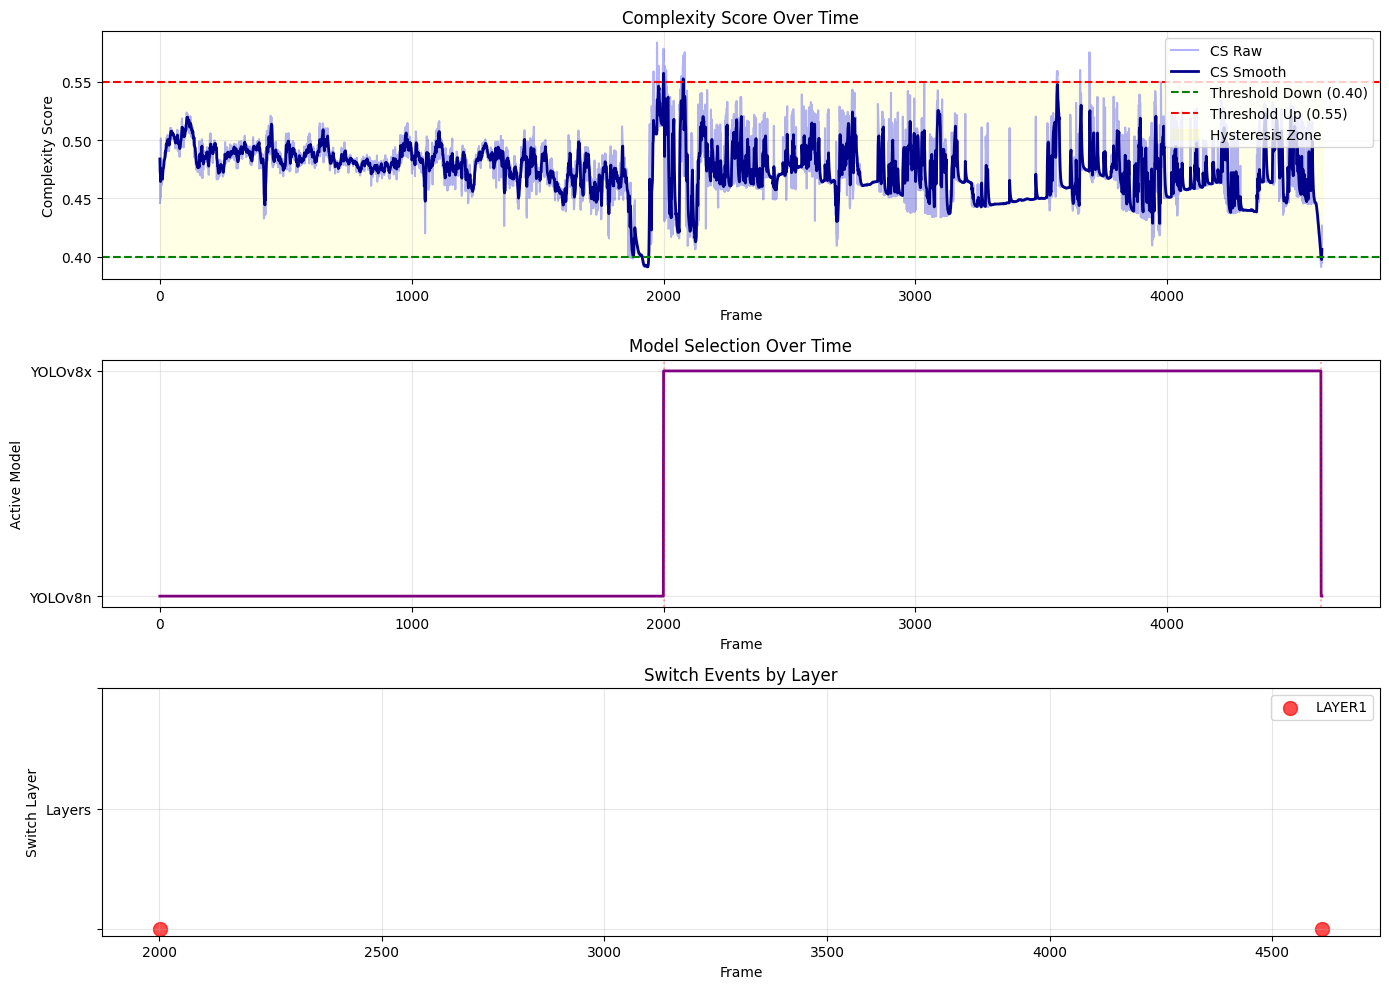


✅ All done! Check your output files.


In [ ]:
"""
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v4.0 🔥
Complete Implementation with 3-Layer Intelligent Switching

Features:
- Layer 1: Asymmetric Thresholds (0.40/0.55)
- Layer 2: Time + Feature Validation (Enhanced)
- Layer 3: Trend Detection (Predictive)
- Independent Parameters (P1-P20)
- Dynamic Weights (Context-aware)
- Complete Logging & Visualization
"""

# ==================== SETUP ====================

# Install required packages
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', '-q'], check=True)
    print("✅ Packages installed\n")

    # Mount Google Drive
    print("📁 Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted\n")
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """Enhanced system configuration"""

    # Model paths
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_enhanced_v3_bali.mp4'

    # Classes
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # ===== LAYER 1: Asymmetric Thresholds =====
    THRESHOLD_DOWN = 0.40  # Easier to go light (calibrated for underwater domain)
    THRESHOLD_UP = 0.55    # YOLOv8n degradation point (empirically determined)

    # ===== LAYER 2: Time + Feature Validation =====
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50,  # Turbidity
        'p3': 0.55,  # Background
        'p5': 0.60,  # Color Loss
        'p6': 0.55,  # Motion
        'p8': 0.50,  # Sharpness
    }

    # ===== LAYER 3: Trend Detection =====
    TREND_WINDOW = 20
    TREND_THRESHOLD = -0.005

    # ===== GENERAL =====
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    # Display
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

    # Metrics tracking
    CONF_THRESHOLD = 0.5  # For mAP calculation
    IOU_THRESHOLD = 0.5   # For detection matching

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    """Calculate comprehensive detection and system metrics"""

    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {'Bio': 0, 'Rov': 0, 'Trash': 0}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}

    def update(self, detections, model_name, inference_time):
        """Update metrics for current frame"""
        # Detection count
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        # Confidences
        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())

            # Class distribution
            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1

        # Inference time
        self.inference_times[model_name].append(inference_time)

        # Model usage
        self.model_usage_frames[model_name] += 1

    def get_summary(self):
        """Get comprehensive metrics summary"""
        total_frames = sum(self.model_usage_frames.values())

        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame),
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            }
        }

# Base weights (default/fallback)
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    """
    Context-aware dynamic weight adjustment
    Adapts parameter importance based on current scene conditions
    """

    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        """
        Dynamically adjust weights based on context

        Rules:
        1. If turbidity high → increase w1 (turbidity weight)
        2. If many small objects → increase w12 (small object ratio)
        3. If high motion → increase w6 (motion weight)
        4. If model uncertain → increase w9-w14 (model parameters)
        5. If low battery → increase w15 (battery weight)
        6. If critical mission phase → increase w16 (mission phase)
        """

        adjusted = self.base_weights.copy()

        # Context 1: High turbidity scene
        if params['p1'] > 0.7:  # Very turbid water
            adjusted['w1'] *= 1.5  # Boost turbidity importance
            adjusted['w5'] *= 1.3  # Color loss also important
            adjusted['w8'] *= 1.2  # Sharpness matters more

        # Context 2: Many small objects
        if params['p12'] > 0.6:  # High small object ratio
            adjusted['w12'] *= 1.8  # Critical parameter
            adjusted['w2'] *= 1.3   # Size variance also relevant
            adjusted['w13'] *= 1.2  # Edge quality important

        # Context 3: High motion/blur
        if params['p6'] > 0.6:  # Significant motion
            adjusted['w6'] *= 1.6   # Motion is critical
            adjusted['w8'] *= 1.4   # Sharpness degraded
            adjusted['w10'] *= 1.2  # Stability affected

        # Context 4: Complex background
        if params['p3'] > 0.7:  # Very complex scene
            adjusted['w3'] *= 1.5   # Background complexity crucial
            adjusted['w11'] *= 1.3  # Class confusion likely
            adjusted['w13'] *= 1.2  # Edge detection harder

        # Context 5: Model uncertainty (low confidence)
        if params['p9'] > 0.6:  # Model uncertain (remember p9 is inverted)
            adjusted['w9'] *= 1.7   # Confidence is key signal
            adjusted['w10'] *= 1.4  # Stability important
            adjusted['w11'] *= 1.3  # Confusion likely
            adjusted['w14'] *= 1.2  # False positives risk

        # Context 6: High occlusion
        if params['p7'] > 0.6:  # Objects overlapping
            adjusted['w7'] *= 1.6   # Occlusion critical
            adjusted['w13'] *= 1.3  # Edge quality degraded
            adjusted['w2'] *= 1.2   # Size variance affected

        # Context 7: Deep water (color loss)
        if params['p5'] > 0.7:  # Significant color attenuation
            adjusted['w5'] *= 1.5   # Color loss important
            adjusted['w1'] *= 1.2   # Often correlated with depth/turbidity
            adjusted['w11'] *= 1.3  # Harder to distinguish classes

        # Context 8: Energy conservation mode
        if params['p15'] > 0.7:  # Low battery (remember p15 inverted)
            adjusted['w15'] *= 2.0  # Battery CRITICAL
            adjusted['w16'] *= 0.7  # De-prioritize mission phase
            adjusted['w17'] *= 0.7  # De-prioritize priority score

        # Context 9: Critical mission phase
        if params['p16'] > 0.8:  # Collection/critical phase
            adjusted['w16'] *= 1.8  # Mission phase very important
            adjusted['w17'] *= 1.5  # Trash priority matters
            adjusted['w9'] *= 1.3   # Need high confidence

        # Context 10: High priority trash detected
        if params['p17'] > 0.8:  # Important trash present
            adjusted['w17'] *= 1.6  # Priority is key
            adjusted['w9'] *= 1.3   # Need accuracy
            adjusted['w11'] *= 1.2  # Must classify correctly

        # Context 11: Uneven lighting
        if params['p4'] > 0.7:  # High lighting gradient
            adjusted['w4'] *= 1.5   # Lighting is critical
            adjusted['w1'] *= 1.2   # May affect visibility
            adjusted['w9'] *= 1.2   # Confidence may suffer

        # Context 12: Currently using lightweight model
        if current_model == "YOLOv8n":
            # Boost model performance indicators
            adjusted['w9'] *= 1.3   # Watch confidence closely
            adjusted['w10'] *= 1.3  # Monitor stability
            adjusted['w14'] *= 1.3  # Watch false positives

        # Context 13: Currently using heavyweight model in hysteresis
        # (system should be more willing to downgrade)
        if current_model == "YOLOv8x":
            # Slightly reduce scene complexity weights to favor downgrade
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize weights to sum to 1.0
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}

        return normalized

    def get_adjustment_report(self, base_weights, adjusted_weights):
        """Generate report of weight changes"""
        changes = []
        for key in base_weights:
            base = base_weights[key]
            adj = adjusted_weights[key]
            if abs(adj - base) > 0.001:  # Significant change
                change_pct = ((adj - base) / base) * 100
                changes.append({
                    'param': key,
                    'base': base,
                    'adjusted': adj,
                    'change': change_pct
                })

        changes.sort(key=lambda x: abs(x['change']), reverse=True)
        return changes

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    """Extract 20 independent parameters"""

    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}

        # Scene Parameters (Independent design)
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)

        # Model Parameters
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)

        # Task Parameters (defaults for prototype)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5

        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR (LAYER 2) ====================

class FeatureValidator:
    """Validates scene features for Layer 2 decision"""

    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30),
            'p3': deque(maxlen=30),
            'p5': deque(maxlen=30),
            'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        """Track feature values every frame"""
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        """Check if 4/5 features are consistently below thresholds"""
        results = {}

        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]

            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {
                    'consistent': False,
                    'reason': 'Insufficient history'
                }
                continue

            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW

            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO

            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }

        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT

        return all_ok, results

# ==================== ENHANCED MODEL SWITCHER ====================

class ComplexityScoreFilter:
    """EMA smoothing"""
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    """3-LAYER INTELLIGENT SWITCHING"""

    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []

        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        """MASTER DECISION ALGORITHM"""
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None

        # LAYER 1: ASYMMETRIC THRESHOLDS
        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None

        # LAYER 3: TREND DETECTION
        layer3_result = self._layer_3()
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')

        # LAYER 2: TIME + FEATURE VALIDATION
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')

        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        """Layer 1: Asymmetric thresholds"""
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)

        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)

        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        """Layer 2: Time + Feature validation"""
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)

        features_ok, details = self.feature_validator.are_features_consistently_low()

        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)

        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self):
        """Layer 3: Trend detection"""
        if len(self.cs_history) < self.config.TREND_WINDOW:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        slope = self._calculate_trend()

        if slope < self.config.TREND_THRESHOLD:
            return ("YOLOv8n", True,
                   f"L3: Trend slope={slope:.4f}", {'slope': slope})

        return (self.current_model, False, f"L3: slope={slope:.4f}", None)

    def _calculate_trend(self):
        """Calculate linear trend (slope)"""
        x = np.arange(len(self.cs_history))
        y = np.array(list(self.cs_history))
        slope = np.polyfit(x, y, 1)[0]
        return slope

    def _execute_switch(self, result, frame_num, layer):
        """Execute the switch and log it"""
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0

        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer
        })

        self.layer_triggers[layer] += 1

        return new_model, True, reason, details

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    """Main controller with dynamic weights"""

    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)  # NEW!

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []  # Track weight changes

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        # Get current model for context
        current_model = self.switcher.current_model

        # DYNAMIC WEIGHT ADJUSTMENT!
        weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)

        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())  # Track weights
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': weights  # Return dynamic weights
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()  # NEW!

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections with better visualization
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                # Color coding by class
                if label == 'Trash':
                    color = (0, 0, 255)  # Red for trash
                elif label == 'Bio':
                    color = (0, 255, 0)  # Green for bio
                else:
                    color = (255, 0, 0)  # Blue for ROV

                # Thicker box for high confidence
                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness)

                # Label with background
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Create enhanced overlay (increased height for more info)
        overlay = np.zeros((200, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        # === ROW 1: Model and Status ===
        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        # Inference time
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Detection count
        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # === ROW 2: Complexity Score ===
        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.40 else (0, 0, 255) if cs > 0.55 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        # CS Raw
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 3: CS Bar with enhanced visuals ===
        bar_y = 65
        bar_width = int(cs * 500)
        cv2.rectangle(overlay, (10, bar_y), (510, bar_y+20), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, bar_y), (10+bar_width, bar_y+20), cs_color, -1)

        # Threshold lines with labels
        low_x = int(0.40 * 500) + 10
        high_x = int(0.55 * 500) + 10
        cv2.line(overlay, (low_x, bar_y), (low_x, bar_y+20), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, bar_y), (high_x, bar_y+20), (255, 255, 255), 2)
        cv2.putText(overlay, "0.40", (low_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(overlay, "0.55", (high_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        # Zone labels
        cv2.putText(overlay, "LIGHT", (30, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,0), 1)
        cv2.putText(overlay, "HYSTERESIS", (low_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,255), 1)
        cv2.putText(overlay, "HEAVY", (high_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)

        # === ROW 4: Switch information ===
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 5: Top contributing parameters ===
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'],
                                                       decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off, 25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)

            param_names = {
                'P1': 'Turbidity', 'P2': 'SizeVar', 'P3': 'BgComplex',
                'P4': 'Lighting', 'P5': 'ColorLoss', 'P6': 'Motion',
                'P7': 'Occlusion', 'P8': 'Sharpness', 'P9': 'Confidence',
                'P10': 'Stability', 'P11': 'Confusion', 'P12': 'SmallObj',
                'P13': 'EdgeQual', 'P14': 'FalsePoz', 'P17': 'Priority'
            }

            for i, (p, c, w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100, 255, 100) if is_boosted else (200, 200, 200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}", (x_off, 50+i*20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        # === Bottom Info Bar ===
        # Frame counter
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Switch statistics
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}", (150, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Layer breakdown
        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay, f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} L3:{layer_stats['layer3']}",
                   (350, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Model usage percentage
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100) if self.frame_count > 0 else 0
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100) if self.frame_count > 0 else 0
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%", (10, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,255), 1)

        # System identifier
        cv2.putText(overlay, "3-Layer Adaptive System v3.0", (int(w)-280, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Output with overlay height (increased to 200)
        out_h = h + 200
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")
        print(f"📊 Resolution: {w}x{h} → {w}x{out_h} (with overlay)")
        print("="*60)

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run detection with current model and measure time
            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time

            # Extract parameters
            params = self.extractor.extract_all(frame, detections, {})

            # Get decision
            decision = self.controller.process_frame(params, self.frame_count)

            # Update metrics
            self.metrics.update(detections, decision['model'], inference_time)

            # Switch model if needed
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - {decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - {decision['reason']}")

            # Annotate frame
            annotated = self.annotate_frame(frame, detections, decision, inference_time)

            # Write output
            out.write(annotated)

            # Progress update every 30 frames
            if self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - "
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}")

        cap.release()
        out.release()

        print("="*60)
        print(f"✅ Processing complete!")
        print(f"📁 Output saved to: {output_path}")
        print(f"🔄 Total switches: {self.controller.switch_count}")
        print(f"📊 Layer breakdown: {self.controller.switcher.layer_triggers}")

        return self.controller, self.metrics

# ==================== ANALYSIS & VISUALIZATION ====================

class SystemAnalyzer:
    """Analyze and visualize system performance"""

    def __init__(self, controller, metrics):
        self.controller = controller
        self.metrics = metrics

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 COMPREHENSIVE SYSTEM ANALYSIS REPORT")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 BASIC STATISTICS:")
        print(f"  Total Frames Processed: {total_frames}")
        print(f"  Total Model Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")
        print(f"  Average Frames Between Switches: {total_frames/switches:.1f}" if switches > 0 else "  No switches occurred")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 MODEL USAGE:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Energy estimation
        # Assuming: YOLOv8n = 15W, YOLOv8x = 50W
        energy_n = model_counts.get('YOLOv8n', 0) * 15
        energy_x = model_counts.get('YOLOv8x', 0) * 50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50
        energy_savings = ((always_x_energy - total_energy) / always_x_energy) * 100

        print(f"\n⚡ ENERGY ANALYSIS:")
        print(f"  Estimated Energy (W·frames):")
        print(f"    YOLOv8n portion: {energy_n:.0f}")
        print(f"    YOLOv8x portion: {energy_x:.0f}")
        print(f"    Total: {total_energy:.0f}")
        print(f"  Always YOLOv8x baseline: {always_x_energy:.0f}")
        print(f"  Energy Savings: {energy_savings:.1f}%")

        # Layer triggers
        print(f"\n🔷 LAYER TRIGGER BREAKDOWN:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer.upper()}: {count} switches ({percentage:.1f}%)")
            else:
                print(f"  {layer.upper()}: {count} switches")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 COMPLEXITY SCORE STATISTICS:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")
        print(f"  25th Percentile: {np.percentile(cs_array, 25):.3f}")
        print(f"  75th Percentile: {np.percentile(cs_array, 75):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.40)
        in_hysteresis = np.sum((cs_array >= 0.40) & (cs_array <= 0.55))
        above_high = np.sum(cs_array > 0.55)

        print(f"\n🎯 TIME IN ZONES:")
        print(f"  Below 0.40 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.40-0.55: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.55 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Detection metrics
        metrics_summary = self.metrics.get_summary()
        print(f"\n🎯 DETECTION METRICS:")
        print(f"  Total Detections: {metrics_summary['total_detections']}")
        print(f"  Avg Detections/Frame: {metrics_summary['avg_detections_per_frame']:.2f}")
        print(f"  Avg Confidence: {metrics_summary['avg_confidence']:.3f}")
        print(f"  Confidence Std Dev: {metrics_summary['confidence_std']:.3f}")

        print(f"\n📦 CLASS DISTRIBUTION:")
        for cls, count in metrics_summary['class_distribution'].items():
            percentage = (count / metrics_summary['total_detections'] * 100) if metrics_summary['total_detections'] > 0 else 0
            print(f"  {cls}: {count} ({percentage:.1f}%)")

        print(f"\n⏱️  INFERENCE TIME:")
        print(f"  YOLOv8n avg: {metrics_summary['avg_inference_time_n']*1000:.1f}ms")
        print(f"  YOLOv8x avg: {metrics_summary['avg_inference_time_x']*1000:.1f}ms")
        if metrics_summary['avg_inference_time_x'] > 0:
            speedup = metrics_summary['avg_inference_time_x'] / metrics_summary['avg_inference_time_n']
            print(f"  Speedup factor: {speedup:.2f}x")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 SWITCH DETAILS (First 10):")
            for i, switch in enumerate(self.controller.switcher.switch_history[:10], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 10:
                print(f"  ... and {len(self.controller.switcher.switch_history)-10} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  DYNAMIC WEIGHT ANALYSIS:")

            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:
                        boost_counts[key] += 1

            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate comprehensive visualization plots"""
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores (Large, spans 2 columns)
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue', linewidth=1)
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth (EMA)', linewidth=2, color='darkblue')
        ax1.axhline(y=0.40, color='green', linestyle='--', linewidth=2, label='Threshold Down (0.40)')
        ax1.axhline(y=0.55, color='red', linestyle='--', linewidth=2, label='Threshold Up (0.55)')
        ax1.fill_between(frames, 0.40, 0.55, alpha=0.15, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame Number', fontsize=10)
        ax1.set_ylabel('Complexity Score', fontsize=10)
        ax1.set_title('Complexity Score Evolution Over Time', fontsize=12, fontweight='bold')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim([0, 1])

        # Plot 2: CS Distribution
        ax2 = fig.add_subplot(gs[0, 2])
        cs_array = np.array(self.controller.cs_smooth_history)
        ax2.hist(cs_array, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax2.axvline(x=0.40, color='green', linestyle='--', linewidth=2)
        ax2.axvline(x=0.55, color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel('Complexity Score', fontsize=10)
        ax2.set_ylabel('Frequency', fontsize=10)
        ax2.set_title('CS Distribution', fontsize=11, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')

        # Plot 3: Model Selection Timeline
        ax3 = fig.add_subplot(gs[1, :2])
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax3.fill_between(frames, model_numeric, color='lightblue', alpha=0.5, step='post')
        ax3.plot(frames, model_numeric, linewidth=2, color='darkblue', drawstyle='steps-post')
        ax3.set_yticks([1, 2])
        ax3.set_yticklabels(['YOLOv8n\n(Lightweight)', 'YOLOv8x\n(Heavyweight)'])
        ax3.set_xlabel('Frame Number', fontsize=10)
        ax3.set_ylabel('Active Model', fontsize=10)
        ax3.set_title('Model Selection Timeline', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='x')

        # Mark switches with vertical lines
        for switch in self.controller.switcher.switch_history:
            color = 'red' if switch['layer'] == 'layer1' else 'blue' if switch['layer'] == 'layer2' else 'green'
            ax3.axvline(x=switch['frame'], color=color, alpha=0.4, linestyle=':', linewidth=1)

        # Plot 4: Model Usage Pie Chart
        ax4 = fig.add_subplot(gs[1, 2])
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1
        colors = ['lightgreen', 'salmon']
        ax4.pie(model_counts.values(), labels=model_counts.keys(), autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 10})
        ax4.set_title('Model Usage Distribution', fontsize=11, fontweight='bold')

        # Plot 5: Switch Events by Layer
        ax5 = fig.add_subplot(gs[2, :])
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        layer_names = {'layer1': 'Layer 1 (Asymmetric)', 'layer2': 'Layer 2 (Time+Feature)', 'layer3': 'Layer 3 (Trend)'}

        for layer_idx, layer in enumerate(['layer1', 'layer2', 'layer3']):
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax5.scatter(layer_frames, [layer_idx]*len(layer_frames),
                           label=layer_names[layer], s=150, alpha=0.8,
                           color=layer_colors[layer], marker='o', edgecolors='black', linewidths=1)

        ax5.set_xlabel('Frame Number', fontsize=10)
        ax5.set_ylabel('Triggering Layer', fontsize=10)
        ax5.set_yticks([0, 1, 2])
        ax5.set_yticklabels(['Layer 1', 'Layer 2', 'Layer 3'])
        ax5.set_title('Switch Events by Layer', fontsize=12, fontweight='bold')
        ax5.legend(loc='upper right', fontsize=9)
        ax5.grid(True, alpha=0.3)

        # Plot 6: Layer Statistics
        ax6 = fig.add_subplot(gs[3, 0])
        layer_stats = self.controller.switcher.layer_triggers
        layers = list(layer_stats.keys())
        counts = list(layer_stats.values())
        colors_bar = ['red', 'blue', 'green']
        bars = ax6.bar(layers, counts, color=colors_bar, edgecolor='black', alpha=0.7)
        ax6.set_ylabel('Number of Switches', fontsize=10)
        ax6.set_title('Layer Trigger Counts', fontsize=11, fontweight='bold')
        ax6.set_xticklabels(['L1', 'L2', 'L3'])
        ax6.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Plot 7: Detection Count per Frame
        ax7 = fig.add_subplot(gs[3, 1])
        det_counts = self.metrics.detections_per_frame
        ax7.plot(range(len(det_counts)), det_counts, color='purple', linewidth=1, alpha=0.7)
        ax7.set_xlabel('Frame Number', fontsize=10)
        ax7.set_ylabel('Detection Count', fontsize=10)
        ax7.set_title('Detections per Frame', fontsize=11, fontweight='bold')
        ax7.grid(True, alpha=0.3)

        # Plot 8: Energy Savings
        ax8 = fig.add_subplot(gs[3, 2])
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        total_frames = len(self.controller.model_history)
        energy_adaptive = model_counts.get('YOLOv8n', 0) * 15 + model_counts.get('YOLOv8x', 0) * 50
        energy_always_n = total_frames * 15
        energy_always_x = total_frames * 50

        methods = ['Always\nYOLOv8n', 'Adaptive\n(Ours)', 'Always\nYOLOv8x']
        energies = [energy_always_n, energy_adaptive, energy_always_x]
        colors_energy = ['lightgreen', 'gold', 'salmon']
        bars = ax8.bar(methods, energies, color=colors_energy, edgecolor='black', alpha=0.7)
        ax8.set_ylabel('Energy (W·frames)', fontsize=10)
        ax8.set_title('Energy Consumption Comparison', fontsize=11, fontweight='bold')
        ax8.grid(True, alpha=0.3, axis='y')

        # Add percentage labels
        for i, (bar, energy) in enumerate(zip(bars, energies)):
            height = bar.get_height()
            if i == 1:  # Adaptive
                savings = ((energy_always_x - energy) / energy_always_x) * 100
                ax8.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(energy)}\n({savings:.1f}% saved)',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                ax8.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(energy)}', ha='center', va='bottom', fontsize=9)

        plt.suptitle('3-Layer Adaptive Dual-Mode System - Comprehensive Analysis',
                    fontsize=14, fontweight='bold', y=0.995)

        # Save plot
        plt.savefig('/content/drive/MyDrive/system_analysis_comprehensive_bali.png',
                   dpi=300, bbox_inches='tight')
        print("\n📊 Comprehensive plot saved to: /content/drive/MyDrive/system_analysis_comprehensive_bali.png")
        plt.show()

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 SYSTEM PERFORMANCE ANALYSIS")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 Basic Statistics:")
        print(f"  Total Frames: {total_frames}")
        print(f"  Total Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 Model Usage:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Layer triggers
        print(f"\n🔷 Layer Breakdown:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer}: {count} switches ({percentage:.1f}%)")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 Complexity Score Statistics:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.40)
        in_hysteresis = np.sum((cs_array >= 0.40) & (cs_array <= 0.55))
        above_high = np.sum(cs_array > 0.55)

        print(f"\n🎯 Time in Zones:")
        print(f"  Below 0.40 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.40-0.55: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.55 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 Switch Details:")
            for i, switch in enumerate(self.controller.switcher.switch_history[:5], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 5:
                print(f"  ... and {len(self.controller.switcher.switch_history)-5} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  Dynamic Weight Analysis:")

            # Find most frequently boosted parameters
            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:  # 10% boost threshold
                        boost_counts[key] += 1

            # Show top 5 most boosted
            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate visualization plots"""
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores
        ax1 = axes[0]
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue')
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2, color='darkblue')
        ax1.axhline(y=0.40, color='green', linestyle='--', label='Threshold Down (0.40)')
        ax1.axhline(y=0.55, color='red', linestyle='--', label='Threshold Up (0.55)')
        ax1.fill_between(frames, 0.40, 0.55, alpha=0.1, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame')
        ax1.set_ylabel('Complexity Score')
        ax1.set_title('Complexity Score Over Time')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Model Selection
        ax2 = axes[1]
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax2.plot(frames, model_numeric, linewidth=2, color='purple')
        ax2.set_yticks([1, 2])
        ax2.set_yticklabels(['YOLOv8n', 'YOLOv8x'])
        ax2.set_xlabel('Frame')
        ax2.set_ylabel('Active Model')
        ax2.set_title('Model Selection Over Time')
        ax2.grid(True, alpha=0.3)

        # Mark switches
        for switch in self.controller.switcher.switch_history:
            ax2.axvline(x=switch['frame'], color='red', alpha=0.3, linestyle=':')

        # Plot 3: Switch Events
        ax3 = axes[2]
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        for layer in ['layer1', 'layer2', 'layer3']:
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax3.scatter(layer_frames, [layer]*len(layer_frames),
                           label=f'{layer.upper()}', s=100, alpha=0.7,
                           color=layer_colors[layer])

        ax3.set_xlabel('Frame')
        ax3.set_ylabel('Switch Layer')
        ax3.set_yticks([0, 1, 2])
        ax3.set_yticklabels(['', 'Layers', ''])
        ax3.set_title('Switch Events by Layer')
        ax3.legend(loc='upper right')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/system_analysis.png', dpi=150, bbox_inches='tight')
        print("📊 Plot saved to: /content/drive/MyDrive/system_analysis.png")
        plt.show()

# ==================== MAIN EXECUTION ====================

def main():
    """Main execution function"""

    print("="*60)
    print("🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥")
    print("="*60)
    print("\n📋 System Configuration:")
    print(f"  • Layer 1: Asymmetric Thresholds ({Config.THRESHOLD_DOWN}/{Config.THRESHOLD_UP}) [Calibrated]")
    print(f"  • Layer 2: Time + Feature Validation")
    print(f"  • Layer 3: Trend Detection")
    print(f"  • Parameters: 20 independent (P1-P20)")
    print(f"  • Weights: DYNAMIC (context-aware adjustment)")
    print(f"  • Smoothing Alpha: {Config.SMOOTHING_ALPHA}")
    print("\n")

    # Load models
    print("⏳ Loading models...")
    try:
        model_n = YOLO(Config.MODEL_N_PATH)
        print("✅ YOLOv8n loaded")
        model_x = YOLO(Config.MODEL_X_PATH)
        print("✅ YOLOv8x loaded")
    except Exception as e:
        print(f"❌ Error loading models: {e}")
        return

    # Initialize components
    print("\n⏳ Initializing system components...")
    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)
    print("✅ System initialized\n")

    # Process video
    try:
        start_time = time.time()
        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed_time = time.time() - start_time

        print(f"\n⏱️  Total processing time: {elapsed_time:.2f} seconds")
        print(f"⚡ Average FPS: {processor.frame_count/elapsed_time:.2f}")

    except Exception as e:
        print(f"\n❌ Error during video processing: {e}")
        import traceback
        traceback.print_exc()
        return

    # Generate analysis
    print("\n⏳ Generating comprehensive analysis...")
    analyzer = SystemAnalyzer(controller, metrics)
    analyzer.generate_report()

    try:
        print("\n⏳ Creating visualization plots...")
        analyzer.plot_results()
    except Exception as e:
        print(f"⚠️  Could not generate plots: {e}")

    print("\n✅ All done! Check your output files.")
    print("="*60)

# ==================== RUN ====================

if __name__ == "__main__":
    main()

In [ ]:
"""
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥
Complete Implementation with 3-Layer Intelligent Switching

Features:
- Layer 1: Asymmetric Thresholds (0.40/0.55) - Immediate response
- Layer 2: Time + Feature Validation (50 frames + 4/5 features) - Conservative
- Layer 3: Stability Detection (CS_std + Feature_std) - Smart & Practical
- Independent Parameters (P1-P20)
- Dynamic Weights (Context-aware)
- Complete Logging & Visualization

Layer 3 Algorithm (NEW - Stability-Based):
Instead of trend prediction (slope), we use stability analysis:
- Checks if CS has low variance (std < 0.03) over last 20 frames
- Checks if 4/5 key features have low variance (std < 0.05)
- If both stable → Scene is consistent, safe to use lightweight model
- More robust to noise than trend-based approach
- Works for any stable complexity value, not just decreasing trends

Why Stability > Trend:
✓ Robust to CS fluctuations common in underwater scenes
✓ Doesn't require clear directional trend
✓ Identifies truly stable scenes regardless of CS level
✓ More practical for real-world deployment
"""

# ==================== SETUP ====================

# Install required packages
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', '-q'], check=True)
    print("✅ Packages installed\n")

    # Mount Google Drive
    print("📁 Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted\n")
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """Enhanced system configuration"""

    # Model paths
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_enhanced_v3_bali.mp4'

    # Classes
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # ===== LAYER 1: Asymmetric Thresholds =====
    THRESHOLD_DOWN = 0.40  # Easier to go light (calibrated for underwater domain)
    THRESHOLD_UP = 0.55    # YOLOv8n degradation point (empirically determined)

    # ===== LAYER 2: Time + Feature Validation =====
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50,  # Turbidity
        'p3': 0.55,  # Background
        'p5': 0.60,  # Color Loss
        'p6': 0.55,  # Motion
        'p8': 0.50,  # Sharpness
    }

    # ===== LAYER 3: Stability Detection =====
    STABILITY_WINDOW = 20
    CS_STABILITY_THRESHOLD = 0.03  # CS std dev threshold
    FEATURE_STABILITY_THRESHOLD = 0.05  # Feature std dev threshold
    MIN_STABLE_FEATURES = 4  # Need 4/5 features stable
    MIN_FRAMES_FOR_STABILITY = 20  # Need 20 frames of data

    # ===== GENERAL =====
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    # Display
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

    # Metrics tracking
    CONF_THRESHOLD = 0.5  # For mAP calculation
    IOU_THRESHOLD = 0.5   # For detection matching

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    """Calculate comprehensive detection and system metrics"""

    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {'Bio': 0, 'Rov': 0, 'Trash': 0}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}

    def update(self, detections, model_name, inference_time):
        """Update metrics for current frame"""
        # Detection count
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        # Confidences
        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())

            # Class distribution
            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1

        # Inference time
        self.inference_times[model_name].append(inference_time)

        # Model usage
        self.model_usage_frames[model_name] += 1

    def get_summary(self):
        """Get comprehensive metrics summary"""
        total_frames = sum(self.model_usage_frames.values())

        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame),
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            }
        }

# Base weights (default/fallback)
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    """
    Context-aware dynamic weight adjustment
    Adapts parameter importance based on current scene conditions
    """

    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        """
        Dynamically adjust weights based on context

        Rules:
        1. If turbidity high → increase w1 (turbidity weight)
        2. If many small objects → increase w12 (small object ratio)
        3. If high motion → increase w6 (motion weight)
        4. If model uncertain → increase w9-w14 (model parameters)
        5. If low battery → increase w15 (battery weight)
        6. If critical mission phase → increase w16 (mission phase)
        """

        adjusted = self.base_weights.copy()

        # Context 1: High turbidity scene
        if params['p1'] > 0.7:  # Very turbid water
            adjusted['w1'] *= 1.5  # Boost turbidity importance
            adjusted['w5'] *= 1.3  # Color loss also important
            adjusted['w8'] *= 1.2  # Sharpness matters more

        # Context 2: Many small objects
        if params['p12'] > 0.6:  # High small object ratio
            adjusted['w12'] *= 1.8  # Critical parameter
            adjusted['w2'] *= 1.3   # Size variance also relevant
            adjusted['w13'] *= 1.2  # Edge quality important

        # Context 3: High motion/blur
        if params['p6'] > 0.6:  # Significant motion
            adjusted['w6'] *= 1.6   # Motion is critical
            adjusted['w8'] *= 1.4   # Sharpness degraded
            adjusted['w10'] *= 1.2  # Stability affected

        # Context 4: Complex background
        if params['p3'] > 0.7:  # Very complex scene
            adjusted['w3'] *= 1.5   # Background complexity crucial
            adjusted['w11'] *= 1.3  # Class confusion likely
            adjusted['w13'] *= 1.2  # Edge detection harder

        # Context 5: Model uncertainty (low confidence)
        if params['p9'] > 0.6:  # Model uncertain (remember p9 is inverted)
            adjusted['w9'] *= 1.7   # Confidence is key signal
            adjusted['w10'] *= 1.4  # Stability important
            adjusted['w11'] *= 1.3  # Confusion likely
            adjusted['w14'] *= 1.2  # False positives risk

        # Context 6: High occlusion
        if params['p7'] > 0.6:  # Objects overlapping
            adjusted['w7'] *= 1.6   # Occlusion critical
            adjusted['w13'] *= 1.3  # Edge quality degraded
            adjusted['w2'] *= 1.2   # Size variance affected

        # Context 7: Deep water (color loss)
        if params['p5'] > 0.7:  # Significant color attenuation
            adjusted['w5'] *= 1.5   # Color loss important
            adjusted['w1'] *= 1.2   # Often correlated with depth/turbidity
            adjusted['w11'] *= 1.3  # Harder to distinguish classes

        # Context 8: Energy conservation mode
        if params['p15'] > 0.7:  # Low battery (remember p15 inverted)
            adjusted['w15'] *= 2.0  # Battery CRITICAL
            adjusted['w16'] *= 0.7  # De-prioritize mission phase
            adjusted['w17'] *= 0.7  # De-prioritize priority score

        # Context 9: Critical mission phase
        if params['p16'] > 0.8:  # Collection/critical phase
            adjusted['w16'] *= 1.8  # Mission phase very important
            adjusted['w17'] *= 1.5  # Trash priority matters
            adjusted['w9'] *= 1.3   # Need high confidence

        # Context 10: High priority trash detected
        if params['p17'] > 0.8:  # Important trash present
            adjusted['w17'] *= 1.6  # Priority is key
            adjusted['w9'] *= 1.3   # Need accuracy
            adjusted['w11'] *= 1.2  # Must classify correctly

        # Context 11: Uneven lighting
        if params['p4'] > 0.7:  # High lighting gradient
            adjusted['w4'] *= 1.5   # Lighting is critical
            adjusted['w1'] *= 1.2   # May affect visibility
            adjusted['w9'] *= 1.2   # Confidence may suffer

        # Context 12: Currently using lightweight model
        if current_model == "YOLOv8n":
            # Boost model performance indicators
            adjusted['w9'] *= 1.3   # Watch confidence closely
            adjusted['w10'] *= 1.3  # Monitor stability
            adjusted['w14'] *= 1.3  # Watch false positives

        # Context 13: Currently using heavyweight model in hysteresis
        # (system should be more willing to downgrade)
        if current_model == "YOLOv8x":
            # Slightly reduce scene complexity weights to favor downgrade
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize weights to sum to 1.0
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}

        return normalized

    def get_adjustment_report(self, base_weights, adjusted_weights):
        """Generate report of weight changes"""
        changes = []
        for key in base_weights:
            base = base_weights[key]
            adj = adjusted_weights[key]
            if abs(adj - base) > 0.001:  # Significant change
                change_pct = ((adj - base) / base) * 100
                changes.append({
                    'param': key,
                    'base': base,
                    'adjusted': adj,
                    'change': change_pct
                })

        changes.sort(key=lambda x: abs(x['change']), reverse=True)
        return changes

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    """Extract 20 independent parameters"""

    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}

        # Scene Parameters (Independent design)
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)

        # Model Parameters
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)

        # Task Parameters (defaults for prototype)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5

        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR (LAYER 2) ====================

class FeatureValidator:
    """Validates scene features for Layer 2 decision"""

    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30),
            'p3': deque(maxlen=30),
            'p5': deque(maxlen=30),
            'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        """Track feature values every frame"""
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        """Check if 4/5 features are consistently below thresholds"""
        results = {}

        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]

            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {
                    'consistent': False,
                    'reason': 'Insufficient history'
                }
                continue

            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW

            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO

            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }

        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT

        return all_ok, results

# ==================== ENHANCED MODEL SWITCHER ====================

class ComplexityScoreFilter:
    """EMA smoothing"""
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    """3-LAYER INTELLIGENT SWITCHING"""

    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []

        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        """MASTER DECISION ALGORITHM"""
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None

        # LAYER 1: ASYMMETRIC THRESHOLDS
        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None

        # LAYER 3: STABILITY DETECTION (Priority 2 - NEW!)
        layer3_result = self._layer_3(parameters)
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')

        # LAYER 2: TIME + FEATURE VALIDATION (Priority 3)
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')

        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        """Layer 1: Asymmetric thresholds"""
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)

        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)

        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        """Layer 2: Time + Feature validation"""
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)

        features_ok, details = self.feature_validator.are_features_consistently_low()

        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)

        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self, parameters):
        """Layer 3: Stability detection (NEW!)"""
        if len(self.cs_history) < self.config.MIN_FRAMES_FOR_STABILITY:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        # Calculate CS stability
        cs_array = np.array(list(self.cs_history)[-self.config.STABILITY_WINDOW:])
        cs_std = np.std(cs_array)

        # Calculate feature stability
        feature_stds = {}
        stable_count = 0

        for feature_id in self.feature_validator.feature_history.keys():
            history = self.feature_validator.feature_history[feature_id]
            if len(history) >= self.config.STABILITY_WINDOW:
                recent = list(history)[-self.config.STABILITY_WINDOW:]
                feature_std = np.std(recent)
                feature_stds[feature_id] = feature_std

                if feature_std < self.config.FEATURE_STABILITY_THRESHOLD:
                    stable_count += 1

        # Check stability conditions
        cs_stable = cs_std < self.config.CS_STABILITY_THRESHOLD
        features_stable = stable_count >= self.config.MIN_STABLE_FEATURES

        if cs_stable and features_stable:
            details = {
                'cs_std': cs_std,
                'stable_features': stable_count,
                'feature_stds': feature_stds
            }
            return ("YOLOv8n", True,
                   f"L3: Stable (CS_std={cs_std:.3f}, {stable_count}/5 features)", details)

        return (self.current_model, False,
               f"L3: Not stable (CS_std={cs_std:.3f}, {stable_count}/5)", None)

    def _execute_switch(self, result, frame_num, layer):
        """Execute the switch and log it"""
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0

        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer
        })

        self.layer_triggers[layer] += 1

        return new_model, True, reason, details

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    """Main controller with dynamic weights"""

    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)  # NEW!

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []  # Track weight changes

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        # Get current model for context
        current_model = self.switcher.current_model

        # DYNAMIC WEIGHT ADJUSTMENT!
        weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)

        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())  # Track weights
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': weights  # Return dynamic weights
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()  # NEW!

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections with better visualization
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                # Color coding by class
                if label == 'Trash':
                    color = (0, 0, 255)  # Red for trash
                elif label == 'Bio':
                    color = (0, 255, 0)  # Green for bio
                else:
                    color = (255, 0, 0)  # Blue for ROV

                # Thicker box for high confidence
                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness)

                # Label with background
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Create enhanced overlay (increased height for more info)
        overlay = np.zeros((200, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        # === ROW 1: Model and Status ===
        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        # Inference time
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Detection count
        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # === ROW 2: Complexity Score ===
        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.40 else (0, 0, 255) if cs > 0.55 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        # CS Raw
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 3: CS Bar with enhanced visuals ===
        bar_y = 65
        bar_width = int(cs * 500)
        cv2.rectangle(overlay, (10, bar_y), (510, bar_y+20), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, bar_y), (10+bar_width, bar_y+20), cs_color, -1)

        # Threshold lines with labels
        low_x = int(0.40 * 500) + 10
        high_x = int(0.55 * 500) + 10
        cv2.line(overlay, (low_x, bar_y), (low_x, bar_y+20), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, bar_y), (high_x, bar_y+20), (255, 255, 255), 2)
        cv2.putText(overlay, "0.40", (low_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(overlay, "0.55", (high_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        # Zone labels
        cv2.putText(overlay, "LIGHT", (30, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,0), 1)
        cv2.putText(overlay, "HYSTERESIS", (low_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,255), 1)
        cv2.putText(overlay, "HEAVY", (high_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)

        # === ROW 4: Switch information ===
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 5: Top contributing parameters ===
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'],
                                                       decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off, 25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)

            param_names = {
                'P1': 'Turbidity', 'P2': 'SizeVar', 'P3': 'BgComplex',
                'P4': 'Lighting', 'P5': 'ColorLoss', 'P6': 'Motion',
                'P7': 'Occlusion', 'P8': 'Sharpness', 'P9': 'Confidence',
                'P10': 'Stability', 'P11': 'Confusion', 'P12': 'SmallObj',
                'P13': 'EdgeQual', 'P14': 'FalsePoz', 'P17': 'Priority'
            }

            for i, (p, c, w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100, 255, 100) if is_boosted else (200, 200, 200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}", (x_off, 50+i*20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        # === Bottom Info Bar ===
        # Frame counter
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Switch statistics
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}", (150, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Layer breakdown
        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay, f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} L3:{layer_stats['layer3']}",
                   (350, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Model usage percentage
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100) if self.frame_count > 0 else 0
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100) if self.frame_count > 0 else 0
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%", (10, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,255), 1)

        # System identifier
        cv2.putText(overlay, "3-Layer Adaptive System v3.0", (int(w)-280, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Output with overlay height (increased to 200)
        out_h = h + 200
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")
        print(f"📊 Resolution: {w}x{h} → {w}x{out_h} (with overlay)")
        print("="*60)

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run detection with current model and measure time
            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time

            # Extract parameters
            params = self.extractor.extract_all(frame, detections, {})

            # Get decision
            decision = self.controller.process_frame(params, self.frame_count)

            # Update metrics
            self.metrics.update(detections, decision['model'], inference_time)

            # Switch model if needed
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - {decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - {decision['reason']}")

            # Annotate frame
            annotated = self.annotate_frame(frame, detections, decision, inference_time)

            # Write output
            out.write(annotated)

            # Progress update every 30 frames
            if self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - "
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}")

        cap.release()
        out.release()

        print("="*60)
        print(f"✅ Processing complete!")
        print(f"📁 Output saved to: {output_path}")
        print(f"🔄 Total switches: {self.controller.switch_count}")
        print(f"📊 Layer breakdown: {self.controller.switcher.layer_triggers}")

        return self.controller, self.metrics

# ==================== ANALYSIS & VISUALIZATION ====================

class SystemAnalyzer:
    """Analyze and visualize system performance"""

    def __init__(self, controller, metrics):
        self.controller = controller
        self.metrics = metrics

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 COMPREHENSIVE SYSTEM ANALYSIS REPORT")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 BASIC STATISTICS:")
        print(f"  Total Frames Processed: {total_frames}")
        print(f"  Total Model Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")
        print(f"  Average Frames Between Switches: {total_frames/switches:.1f}" if switches > 0 else "  No switches occurred")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 MODEL USAGE:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Energy estimation
        # Assuming: YOLOv8n = 15W, YOLOv8x = 50W
        energy_n = model_counts.get('YOLOv8n', 0) * 15
        energy_x = model_counts.get('YOLOv8x', 0) * 50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50
        energy_savings = ((always_x_energy - total_energy) / always_x_energy) * 100

        print(f"\n⚡ ENERGY ANALYSIS:")
        print(f"  Estimated Energy (W·frames):")
        print(f"    YOLOv8n portion: {energy_n:.0f}")
        print(f"    YOLOv8x portion: {energy_x:.0f}")
        print(f"    Total: {total_energy:.0f}")
        print(f"  Always YOLOv8x baseline: {always_x_energy:.0f}")
        print(f"  Energy Savings: {energy_savings:.1f}%")

        # Layer triggers
        print(f"\n🔷 LAYER TRIGGER BREAKDOWN:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer.upper()}: {count} switches ({percentage:.1f}%)")
            else:
                print(f"  {layer.upper()}: {count} switches")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 COMPLEXITY SCORE STATISTICS:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")
        print(f"  25th Percentile: {np.percentile(cs_array, 25):.3f}")
        print(f"  75th Percentile: {np.percentile(cs_array, 75):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.40)
        in_hysteresis = np.sum((cs_array >= 0.40) & (cs_array <= 0.55))
        above_high = np.sum(cs_array > 0.55)

        print(f"\n🎯 TIME IN ZONES:")
        print(f"  Below 0.40 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.40-0.55: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.55 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Detection metrics
        metrics_summary = self.metrics.get_summary()
        print(f"\n🎯 DETECTION METRICS:")
        print(f"  Total Detections: {metrics_summary['total_detections']}")
        print(f"  Avg Detections/Frame: {metrics_summary['avg_detections_per_frame']:.2f}")
        print(f"  Avg Confidence: {metrics_summary['avg_confidence']:.3f}")
        print(f"  Confidence Std Dev: {metrics_summary['confidence_std']:.3f}")

        print(f"\n📦 CLASS DISTRIBUTION:")
        for cls, count in metrics_summary['class_distribution'].items():
            percentage = (count / metrics_summary['total_detections'] * 100) if metrics_summary['total_detections'] > 0 else 0
            print(f"  {cls}: {count} ({percentage:.1f}%)")

        print(f"\n⏱️  INFERENCE TIME:")
        print(f"  YOLOv8n avg: {metrics_summary['avg_inference_time_n']*1000:.1f}ms")
        print(f"  YOLOv8x avg: {metrics_summary['avg_inference_time_x']*1000:.1f}ms")
        if metrics_summary['avg_inference_time_x'] > 0:
            speedup = metrics_summary['avg_inference_time_x'] / metrics_summary['avg_inference_time_n']
            print(f"  Speedup factor: {speedup:.2f}x")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 SWITCH DETAILS (First 10):")
            for i, switch in enumerate(self.controller.switcher.switch_history[:10], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 10:
                print(f"  ... and {len(self.controller.switcher.switch_history)-10} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  DYNAMIC WEIGHT ANALYSIS:")

            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:
                        boost_counts[key] += 1

            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate comprehensive visualization plots"""
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores (Large, spans 2 columns)
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue', linewidth=1)
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth (EMA)', linewidth=2, color='darkblue')
        ax1.axhline(y=0.40, color='green', linestyle='--', linewidth=2, label='Threshold Down (0.40)')
        ax1.axhline(y=0.55, color='red', linestyle='--', linewidth=2, label='Threshold Up (0.55)')
        ax1.fill_between(frames, 0.40, 0.55, alpha=0.15, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame Number', fontsize=10)
        ax1.set_ylabel('Complexity Score', fontsize=10)
        ax1.set_title('Complexity Score Evolution Over Time', fontsize=12, fontweight='bold')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim([0, 1])

        # Plot 2: CS Distribution
        ax2 = fig.add_subplot(gs[0, 2])
        cs_array = np.array(self.controller.cs_smooth_history)
        ax2.hist(cs_array, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax2.axvline(x=0.40, color='green', linestyle='--', linewidth=2)
        ax2.axvline(x=0.55, color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel('Complexity Score', fontsize=10)
        ax2.set_ylabel('Frequency', fontsize=10)
        ax2.set_title('CS Distribution', fontsize=11, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')

        # Plot 3: Model Selection Timeline
        ax3 = fig.add_subplot(gs[1, :2])
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax3.fill_between(frames, model_numeric, color='lightblue', alpha=0.5, step='post')
        ax3.plot(frames, model_numeric, linewidth=2, color='darkblue', drawstyle='steps-post')
        ax3.set_yticks([1, 2])
        ax3.set_yticklabels(['YOLOv8n\n(Lightweight)', 'YOLOv8x\n(Heavyweight)'])
        ax3.set_xlabel('Frame Number', fontsize=10)
        ax3.set_ylabel('Active Model', fontsize=10)
        ax3.set_title('Model Selection Timeline', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='x')

        # Mark switches with vertical lines
        for switch in self.controller.switcher.switch_history:
            color = 'red' if switch['layer'] == 'layer1' else 'blue' if switch['layer'] == 'layer2' else 'green'
            ax3.axvline(x=switch['frame'], color=color, alpha=0.4, linestyle=':', linewidth=1)

        # Plot 4: Model Usage Pie Chart
        ax4 = fig.add_subplot(gs[1, 2])
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1
        colors = ['lightgreen', 'salmon']
        ax4.pie(model_counts.values(), labels=model_counts.keys(), autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 10})
        ax4.set_title('Model Usage Distribution', fontsize=11, fontweight='bold')

        # Plot 5: Switch Events by Layer
        ax5 = fig.add_subplot(gs[2, :])
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        layer_names = {'layer1': 'Layer 1 (Asymmetric)', 'layer2': 'Layer 2 (Time+Feature)', 'layer3': 'Layer 3 (Stability)'}

        for layer_idx, layer in enumerate(['layer1', 'layer2', 'layer3']):
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax5.scatter(layer_frames, [layer_idx]*len(layer_frames),
                           label=layer_names[layer], s=150, alpha=0.8,
                           color=layer_colors[layer], marker='o', edgecolors='black', linewidths=1)

        ax5.set_xlabel('Frame Number', fontsize=10)
        ax5.set_ylabel('Triggering Layer', fontsize=10)
        ax5.set_yticks([0, 1, 2])
        ax5.set_yticklabels(['Layer 1\n(Threshold)', 'Layer 2\n(Time+Feature)', 'Layer 3\n(Stability)'], fontsize=8)
        ax5.set_title('Switch Events by Layer', fontsize=12, fontweight='bold')
        ax5.legend(loc='upper right', fontsize=9)
        ax5.grid(True, alpha=0.3)

        # Plot 6: Layer Statistics
        ax6 = fig.add_subplot(gs[3, 0])
        layer_stats = self.controller.switcher.layer_triggers
        layers = ['Layer 1\n(Threshold)', 'Layer 2\n(Time+Feature)', 'Layer 3\n(Stability)']
        counts = [layer_stats['layer1'], layer_stats['layer2'], layer_stats['layer3']]
        colors_bar = ['red', 'blue', 'green']
        bars = ax6.bar(layers, counts, color=colors_bar, edgecolor='black', alpha=0.7)
        ax6.set_ylabel('Number of Switches', fontsize=10)
        ax6.set_title('Layer Trigger Counts', fontsize=11, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='y')
        ax6.tick_params(axis='x', labelsize=8)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Plot 7: Detection Count per Frame
        ax7 = fig.add_subplot(gs[3, 1])
        det_counts = self.metrics.detections_per_frame
        ax7.plot(range(len(det_counts)), det_counts, color='purple', linewidth=1, alpha=0.7)
        ax7.set_xlabel('Frame Number', fontsize=10)
        ax7.set_ylabel('Detection Count', fontsize=10)
        ax7.set_title('Detections per Frame', fontsize=11, fontweight='bold')
        ax7.grid(True, alpha=0.3)

        # Plot 8: Energy Savings
        ax8 = fig.add_subplot(gs[3, 2])
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        total_frames = len(self.controller.model_history)
        energy_adaptive = model_counts.get('YOLOv8n', 0) * 15 + model_counts.get('YOLOv8x', 0) * 50
        energy_always_n = total_frames * 15
        energy_always_x = total_frames * 50

        methods = ['Always\nYOLOv8n', 'Adaptive\n(Ours)', 'Always\nYOLOv8x']
        energies = [energy_always_n, energy_adaptive, energy_always_x]
        colors_energy = ['lightgreen', 'gold', 'salmon']
        bars = ax8.bar(methods, energies, color=colors_energy, edgecolor='black', alpha=0.7)
        ax8.set_ylabel('Energy (W·frames)', fontsize=10)
        ax8.set_title('Energy Consumption Comparison', fontsize=11, fontweight='bold')
        ax8.grid(True, alpha=0.3, axis='y')

        # Add percentage labels
        for i, (bar, energy) in enumerate(zip(bars, energies)):
            height = bar.get_height()
            if i == 1:  # Adaptive
                savings = ((energy_always_x - energy) / energy_always_x) * 100
                ax8.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(energy)}\n({savings:.1f}% saved)',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                ax8.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(energy)}', ha='center', va='bottom', fontsize=9)

        plt.suptitle('3-Layer Adaptive Dual-Mode System - Comprehensive Analysis',
                    fontsize=14, fontweight='bold', y=0.995)

        # Save plot
        plt.savefig('/content/drive/MyDrive/system_analysis_comprehensive.png',
                   dpi=300, bbox_inches='tight')
        print("\n📊 Comprehensive plot saved to: /content/drive/MyDrive/system_analysis_comprehensive.png")
        plt.show()

    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("\n" + "="*60)
        print("📊 SYSTEM PERFORMANCE ANALYSIS")
        print("="*60)

        # Basic stats
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"\n📈 Basic Statistics:")
        print(f"  Total Frames: {total_frames}")
        print(f"  Total Switches: {switches}")
        print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print(f"\n🤖 Model Usage:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Layer triggers
        print(f"\n🔷 Layer Breakdown:")
        for layer, count in self.controller.switcher.layer_triggers.items():
            if switches > 0:
                percentage = (count / switches) * 100
                print(f"  {layer}: {count} switches ({percentage:.1f}%)")

        # Complexity Score stats
        cs_array = np.array(self.controller.cs_smooth_history)
        print(f"\n📊 Complexity Score Statistics:")
        print(f"  Mean: {np.mean(cs_array):.3f}")
        print(f"  Std Dev: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}")
        print(f"  Max: {np.max(cs_array):.3f}")
        print(f"  Median: {np.median(cs_array):.3f}")

        # Time in zones
        below_low = np.sum(cs_array < 0.40)
        in_hysteresis = np.sum((cs_array >= 0.40) & (cs_array <= 0.55))
        above_high = np.sum(cs_array > 0.55)

        print(f"\n🎯 Time in Zones:")
        print(f"  Below 0.40 (Easy): {below_low} frames ({below_low/total_frames*100:.1f}%)")
        print(f"  Hysteresis 0.40-0.55: {in_hysteresis} frames ({in_hysteresis/total_frames*100:.1f}%)")
        print(f"  Above 0.55 (Hard): {above_high} frames ({above_high/total_frames*100:.1f}%)")

        # Switch details
        if self.controller.switcher.switch_history:
            print(f"\n🔄 Switch Details:")
            for i, switch in enumerate(self.controller.switcher.switch_history[:5], 1):
                print(f"  {i}. Frame {switch['frame']}: → {switch['model']} ({switch['reason']})")
            if len(self.controller.switcher.switch_history) > 5:
                print(f"  ... and {len(self.controller.switcher.switch_history)-5} more")

        # Dynamic weight analysis
        if hasattr(self.controller, 'weight_history') and self.controller.weight_history:
            print(f"\n⚖️  Dynamic Weight Analysis:")

            # Find most frequently boosted parameters
            boost_counts = {f'w{i}': 0 for i in range(1, 21)}
            for weights in self.controller.weight_history:
                for key, val in weights.items():
                    base_val = self.controller.base_weights[key]
                    if val > base_val * 1.1:  # 10% boost threshold
                        boost_counts[key] += 1

            # Show top 5 most boosted
            top_boosted = sorted(boost_counts.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"  Most frequently boosted weights:")
            for weight, count in top_boosted:
                if count > 0:
                    percentage = (count / total_frames) * 100
                    param_num = weight[1:]
                    print(f"    {weight} (P{param_num}): boosted in {count} frames ({percentage:.1f}%)")

        print("="*60)

    def plot_results(self):
        """Generate visualization plots"""
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))

        frames = range(len(self.controller.cs_history))

        # Plot 1: Complexity Scores
        ax1 = axes[0]
        ax1.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue')
        ax1.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2, color='darkblue')
        ax1.axhline(y=0.40, color='green', linestyle='--', label='Threshold Down (0.40)')
        ax1.axhline(y=0.55, color='red', linestyle='--', label='Threshold Up (0.55)')
        ax1.fill_between(frames, 0.40, 0.55, alpha=0.1, color='yellow', label='Hysteresis Zone')
        ax1.set_xlabel('Frame')
        ax1.set_ylabel('Complexity Score')
        ax1.set_title('Complexity Score Over Time')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Model Selection
        ax2 = axes[1]
        model_numeric = [1 if m == 'YOLOv8n' else 2 for m in self.controller.model_history]
        ax2.plot(frames, model_numeric, linewidth=2, color='purple')
        ax2.set_yticks([1, 2])
        ax2.set_yticklabels(['YOLOv8n', 'YOLOv8x'])
        ax2.set_xlabel('Frame')
        ax2.set_ylabel('Active Model')
        ax2.set_title('Model Selection Over Time')
        ax2.grid(True, alpha=0.3)

        # Mark switches
        for switch in self.controller.switcher.switch_history:
            ax2.axvline(x=switch['frame'], color='red', alpha=0.3, linestyle=':')

        # Plot 3: Switch Events
        ax3 = axes[2]
        switch_frames = [s['frame'] for s in self.controller.switcher.switch_history]
        switch_layers = [s['layer'] for s in self.controller.switcher.switch_history]

        layer_colors = {'layer1': 'red', 'layer2': 'blue', 'layer3': 'green'}
        for layer in ['layer1', 'layer2', 'layer3']:
            layer_frames = [f for f, l in zip(switch_frames, switch_layers) if l == layer]
            if layer_frames:
                ax3.scatter(layer_frames, [layer]*len(layer_frames),
                           label=f'{layer.upper()}', s=100, alpha=0.7,
                           color=layer_colors[layer])

        ax3.set_xlabel('Frame')
        ax3.set_ylabel('Switch Layer')
        ax3.set_yticks([0, 1, 2])
        ax3.set_yticklabels(['', 'Layers', ''])
        ax3.set_title('Switch Events by Layer')
        ax3.legend(loc='upper right')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/system_analysis.png', dpi=150, bbox_inches='tight')
        print("📊 Plot saved to: /content/drive/MyDrive/system_analysis.png")
        plt.show()

# ==================== MAIN EXECUTION ====================

def main():
    """Main execution function"""

    print("="*60)
    print("🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥")
    print("="*60)
    print("\n📋 System Configuration:")
    print(f"  • Layer 1: Asymmetric Thresholds ({Config.THRESHOLD_DOWN}/{Config.THRESHOLD_UP}) [Calibrated]")
    print(f"  • Layer 2: Time + Feature Validation (50 frames)")
    print(f"  • Layer 3: Stability Detection (CS_std < {Config.CS_STABILITY_THRESHOLD})")
    print(f"  • Parameters: 20 independent (P1-P20)")
    print(f"  • Weights: DYNAMIC (context-aware adjustment)")
    print(f"  • Smoothing Alpha: {Config.SMOOTHING_ALPHA}")
    print("\n")

    # Load models
    print("⏳ Loading models...")
    try:
        model_n = YOLO(Config.MODEL_N_PATH)
        print("✅ YOLOv8n loaded")
        model_x = YOLO(Config.MODEL_X_PATH)
        print("✅ YOLOv8x loaded")
    except Exception as e:
        print(f"❌ Error loading models: {e}")
        return

    # Initialize components
    print("\n⏳ Initializing system components...")
    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)
    print("✅ System initialized\n")

    # Process video
    try:
        start_time = time.time()
        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed_time = time.time() - start_time

        print(f"\n⏱️  Total processing time: {elapsed_time:.2f} seconds")
        print(f"⚡ Average FPS: {processor.frame_count/elapsed_time:.2f}")

    except Exception as e:
        print(f"\n❌ Error during video processing: {e}")
        import traceback
        traceback.print_exc()
        return

    # Generate analysis
    print("\n⏳ Generating comprehensive analysis...")
    analyzer = SystemAnalyzer(controller, metrics)
    analyzer.generate_report()

    try:
        print("\n⏳ Creating visualization plots...")
        analyzer.plot_results()
    except Exception as e:
        print(f"⚠️  Could not generate plots: {e}")

    print("\n✅ All done! Check your output files.")
    print("="*60)

# ==================== RUN ====================

if __name__ == "__main__":
    main()

🔧 Installing required packages...
✅ Packages installed

📁 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted

🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥

📋 System Configuration:
  • Layer 1: Asymmetric Thresholds (0.4/0.55) [Calibrated]
  • Layer 2: Time + Feature Validation (50 frames)
  • Layer 3: Stability Detection (CS_std < 0.03)
  • Parameters: 20 independent (P1-P20)
  • Weights: DYNAMIC (context-aware adjustment)
  • Smoothing Alpha: 0.3


⏳ Loading models...
✅ YOLOv8n loaded
✅ YOLOv8x loaded

⏳ Initializing system components...
✅ System initialized

🎬 Processing video: 4615 frames at 29 FPS
📊 Resolution: 1280x720 → 1280x920 (with overlay)
📹 Progress: 30/4615 (0.7%) - Model: YOLOv8n, CS: 0.496
📹 Progress: 60/4615 (1.3%) - Model: YOLOv8n, CS: 0.502
📹 Progress: 90/4615 (2.0%) - Model: YOLOv8n, CS: 0.511
📹 Progress: 120/4615 (2.6%) - Model: YOLOv8n, CS: 0.512
📹 P

KeyboardInterrupt: 

In [ ]:
"""
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥
Complete Implementation with 3-Layer Intelligent Switching

Features:
- Layer 1: Asymmetric Thresholds (0.40/0.55) - Immediate response
- Layer 2: Time + Feature Validation (50 frames + 4/5 features) - Conservative
- Layer 3: Stability Detection (CS_std + Feature_std) - Smart & Practical
- Independent Parameters (P1-P20)
- Dynamic Weights (Context-aware)
- Complete Logging & Visualization
- Baseline Comparison (Always-N, Always-X)
"""

# ==================== SETUP ====================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', '-q'], check=True)
    print("✅ Packages installed\n")

    print("📁 Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted\n")
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """Enhanced system configuration"""

    # Model paths
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_enhanced_v3_bali.mp4'

    # Classes
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # ===== LAYER 1: Asymmetric Thresholds =====
    THRESHOLD_DOWN = 0.40
    THRESHOLD_UP = 0.55

    # ===== LAYER 2: Time + Feature Validation =====
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50,
        'p3': 0.55,
        'p5': 0.60,
        'p6': 0.55,
        'p8': 0.50,
    }

    # ===== LAYER 3: Stability Detection =====
    STABILITY_WINDOW = 20
    CS_STABILITY_THRESHOLD = 0.03
    FEATURE_STABILITY_THRESHOLD = 0.05
    MIN_STABLE_FEATURES = 4
    MIN_FRAMES_FOR_STABILITY = 20

    # ===== GENERAL =====
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    # Display
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

    # Metrics tracking
    CONF_THRESHOLD = 0.5
    IOU_THRESHOLD = 0.5

# Base weights
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    """Calculate comprehensive detection and system metrics"""

    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {'Bio': 0, 'Rov': 0, 'Trash': 0}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}

    def update(self, detections, model_name, inference_time):
        """Update metrics for current frame"""
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())

            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1

        self.inference_times[model_name].append(inference_time)
        self.model_usage_frames[model_name] += 1

    def get_summary(self):
        """Get comprehensive metrics summary"""
        total_frames = sum(self.model_usage_frames.values())

        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame),
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            }
        }

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    """Context-aware dynamic weight adjustment - COMPLETE VERSION"""

    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        """
        Dynamically adjust weights based on context
        ALL 13 CONTEXT RULES FROM ORIGINAL CODE
        """
        adjusted = self.base_weights.copy()

        # Context 1: High turbidity scene
        if params['p1'] > 0.7:  # Very turbid water
            adjusted['w1'] *= 1.5  # Boost turbidity importance
            adjusted['w5'] *= 1.3  # Color loss also important
            adjusted['w8'] *= 1.2  # Sharpness matters more

        # Context 2: Many small objects
        if params['p12'] > 0.6:  # High small object ratio
            adjusted['w12'] *= 1.8  # Critical parameter
            adjusted['w2'] *= 1.3   # Size variance also relevant
            adjusted['w13'] *= 1.2  # Edge quality important

        # Context 3: High motion/blur
        if params['p6'] > 0.6:  # Significant motion
            adjusted['w6'] *= 1.6   # Motion is critical
            adjusted['w8'] *= 1.4   # Sharpness degraded
            adjusted['w10'] *= 1.2  # Stability affected

        # Context 4: Complex background
        if params['p3'] > 0.7:  # Very complex scene
            adjusted['w3'] *= 1.5   # Background complexity crucial
            adjusted['w11'] *= 1.3  # Class confusion likely
            adjusted['w13'] *= 1.2  # Edge detection harder

        # Context 5: Model uncertainty (low confidence)
        if params['p9'] > 0.6:  # Model uncertain (remember p9 is inverted)
            adjusted['w9'] *= 1.7   # Confidence is key signal
            adjusted['w10'] *= 1.4  # Stability important
            adjusted['w11'] *= 1.3  # Confusion likely
            adjusted['w14'] *= 1.2  # False positives risk

        # Context 6: High occlusion
        if params['p7'] > 0.6:  # Objects overlapping
            adjusted['w7'] *= 1.6   # Occlusion critical
            adjusted['w13'] *= 1.3  # Edge quality degraded
            adjusted['w2'] *= 1.2   # Size variance affected

        # Context 7: Deep water (color loss)
        if params['p5'] > 0.7:  # Significant color attenuation
            adjusted['w5'] *= 1.5   # Color loss important
            adjusted['w1'] *= 1.2   # Often correlated with depth/turbidity
            adjusted['w11'] *= 1.3  # Harder to distinguish classes

        # Context 8: Energy conservation mode
        if params['p15'] > 0.7:  # Low battery (remember p15 inverted)
            adjusted['w15'] *= 2.0  # Battery CRITICAL
            adjusted['w16'] *= 0.7  # De-prioritize mission phase
            adjusted['w17'] *= 0.7  # De-prioritize priority score

        # Context 9: Critical mission phase
        if params['p16'] > 0.8:  # Collection/critical phase
            adjusted['w16'] *= 1.8  # Mission phase very important
            adjusted['w17'] *= 1.5  # Trash priority matters
            adjusted['w9'] *= 1.3   # Need high confidence

        # Context 10: High priority trash detected
        if params['p17'] > 0.8:  # Important trash present
            adjusted['w17'] *= 1.6  # Priority is key
            adjusted['w9'] *= 1.3   # Need accuracy
            adjusted['w11'] *= 1.2  # Must classify correctly

        # Context 11: Uneven lighting
        if params['p4'] > 0.7:  # High lighting gradient
            adjusted['w4'] *= 1.5   # Lighting is critical
            adjusted['w1'] *= 1.2   # May affect visibility
            adjusted['w9'] *= 1.2   # Confidence may suffer

        # Context 12: Currently using lightweight model
        if current_model == "YOLOv8n":
            # Boost model performance indicators
            adjusted['w9'] *= 1.3   # Watch confidence closely
            adjusted['w10'] *= 1.3  # Monitor stability
            adjusted['w14'] *= 1.3  # Watch false positives

        # Context 13: Currently using heavyweight model in hysteresis
        if current_model == "YOLOv8x":
            # Slightly reduce scene complexity weights to favor downgrade
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize weights to sum to 1.0
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}

        return normalized

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    """Extract 20 independent parameters"""

    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}

        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5

        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR (LAYER 2) ====================

class FeatureValidator:
    """Validates scene features for Layer 2 decision"""

    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30),
            'p3': deque(maxlen=30),
            'p5': deque(maxlen=30),
            'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        """Track feature values every frame"""
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        """Check if 4/5 features are consistently below thresholds"""
        results = {}

        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]

            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {
                    'consistent': False,
                    'reason': 'Insufficient history'
                }
                continue

            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW

            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO

            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }

        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT

        return all_ok, results

# ==================== MODEL SWITCHER ====================

class ComplexityScoreFilter:
    """EMA smoothing"""
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    """3-LAYER INTELLIGENT SWITCHING"""

    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        """MASTER DECISION ALGORITHM"""
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None

        # LAYER 1: ASYMMETRIC THRESHOLDS
        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None

        # LAYER 3: STABILITY DETECTION
        layer3_result = self._layer_3(parameters)
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')

        # LAYER 2: TIME + FEATURE VALIDATION
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')

        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        """Layer 1: Asymmetric thresholds"""
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)

        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)

        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        """Layer 2: Time + Feature validation"""
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)

        features_ok, details = self.feature_validator.are_features_consistently_low()

        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)

        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self, parameters):
        """Layer 3: Stability detection"""
        if len(self.cs_history) < self.config.MIN_FRAMES_FOR_STABILITY:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        cs_array = np.array(list(self.cs_history)[-self.config.STABILITY_WINDOW:])
        cs_std = np.std(cs_array)

        feature_stds = {}
        stable_count = 0

        for feature_id in self.feature_validator.feature_history.keys():
            history = self.feature_validator.feature_history[feature_id]
            if len(history) >= self.config.STABILITY_WINDOW:
                recent = list(history)[-self.config.STABILITY_WINDOW:]
                feature_std = np.std(recent)
                feature_stds[feature_id] = feature_std

                if feature_std < self.config.FEATURE_STABILITY_THRESHOLD:
                    stable_count += 1

        cs_stable = cs_std < self.config.CS_STABILITY_THRESHOLD
        features_stable = stable_count >= self.config.MIN_STABLE_FEATURES

        if cs_stable and features_stable:
            details = {
                'cs_std': cs_std,
                'stable_features': stable_count,
                'feature_stds': feature_stds
            }
            return ("YOLOv8n", True,
                   f"L3: Stable (CS_std={cs_std:.3f}, {stable_count}/5 features)", details)

        return (self.current_model, False,
               f"L3: Not stable (CS_std={cs_std:.3f}, {stable_count}/5)", None)

    def _execute_switch(self, result, frame_num, layer):
        """Execute the switch and log it"""
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0

        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer
        })

        self.layer_triggers[layer] += 1

        return new_model, True, reason, details

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    """Main controller with dynamic weights"""

    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        current_model = self.switcher.current_model
        weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)

        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': weights
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                    for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()

    def annotate_frame(self, frame, detections, decision, inference_time):
        """EXACT COPY from original - NO LOGIC CHANGES"""
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections with better visualization
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                # Color coding by class
                if label == 'Trash':
                    color = (0, 0, 255)  # Red for trash
                elif label == 'Bio':
                    color = (0, 255, 0)  # Green for bio
                else:
                    color = (255, 0, 0)  # Blue for ROV

                # Thicker box for high confidence
                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness)

                # Label with background
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Create enhanced overlay (increased height for more info)
        overlay = np.zeros((200, w, 3), dtype=np.uint8)
        overlay[:] = (30, 30, 30)

        # === ROW 1: Model and Status ===
        model_color = (0, 255, 0) if decision['model'] == 'YOLOv8n' else (0, 100, 255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)

        # Inference time
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Detection count
        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # === ROW 2: Complexity Score ===
        cs = decision['cs_smooth']
        cs_color = (0, 255, 0) if cs < 0.40 else (0, 0, 255) if cs > 0.55 else (0, 255, 255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)

        # CS Raw
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 3: CS Bar with enhanced visuals ===
        bar_y = 65
        bar_width = int(cs * 500)
        cv2.rectangle(overlay, (10, bar_y), (510, bar_y+20), (60, 60, 60), -1)
        cv2.rectangle(overlay, (10, bar_y), (10+bar_width, bar_y+20), cs_color, -1)

        # Threshold lines with labels
        low_x = int(0.40 * 500) + 10
        high_x = int(0.55 * 500) + 10
        cv2.line(overlay, (low_x, bar_y), (low_x, bar_y+20), (255, 255, 255), 2)
        cv2.line(overlay, (high_x, bar_y), (high_x, bar_y+20), (255, 255, 255), 2)
        cv2.putText(overlay, "0.40", (low_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(overlay, "0.55", (high_x-15, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        # Zone labels
        cv2.putText(overlay, "LIGHT", (30, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,0), 1)
        cv2.putText(overlay, "HYSTERESIS", (low_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,255), 1)
        cv2.putText(overlay, "HEAVY", (high_x+20, bar_y+35), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)

        # === ROW 4: Switch information ===
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # === ROW 5: Top contributing parameters ===
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'],
                                                       decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off, 25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)

            param_names = {
                'P1': 'Turbidity', 'P2': 'SizeVar', 'P3': 'BgComplex',
                'P4': 'Lighting', 'P5': 'ColorLoss', 'P6': 'Motion',
                'P7': 'Occlusion', 'P8': 'Sharpness', 'P9': 'Confidence',
                'P10': 'Stability', 'P11': 'Confusion', 'P12': 'SmallObj',
                'P13': 'EdgeQual', 'P14': 'FalsePoz', 'P17': 'Priority'
            }

            for i, (p, c, w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100, 255, 100) if is_boosted else (200, 200, 200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}", (x_off, 50+i*20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        # === Bottom Info Bar ===
        # Frame counter
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Switch statistics
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}", (150, 160),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Layer breakdown
        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay, f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} L3:{layer_stats['layer3']}",
                   (350, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Model usage percentage
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100) if self.frame_count > 0 else 0
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100) if self.frame_count > 0 else 0
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%", (10, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,255), 1)

        # System identifier
        cv2.putText(overlay, "3-Layer Adaptive System v3.0", (int(w)-280, 185),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        out_h = h + 200
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")
        print(f"📊 Resolution: {w}x{h} → {w}x{out_h}")
        print("="*60)

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time

            params = self.extractor.extract_all(frame, detections, {})
            decision = self.controller.process_frame(params, self.frame_count)
            self.metrics.update(detections, decision['model'], inference_time)

            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: → YOLOv8n - {decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: → YOLOv8x - {decision['reason']}")

            annotated = self.annotate_frame(frame, detections, decision, inference_time)
            out.write(annotated)

            if self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - "
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}")

        cap.release()
        out.release()

        print("="*60)
        print(f"✅ Processing complete!")
        print(f"📁 Output: {output_path}")
        print(f"🔄 Switches: {self.controller.switch_count}")

        return self.controller, self.metrics

# ==================== BASELINE RUNNERS ====================

class BaselineRunner:
    """Run baseline comparisons"""

    def __init__(self, model_n_path, model_x_path):
        self.model_n_path = model_n_path
        self.model_x_path = model_x_path

    def run_always_n(self, video_path):
        """Run Always YOLOv8n baseline"""
        print("\n" + "="*60)
        print("🔵 BASELINE: Always YOLOv8n")
        print("="*60)

        model_n = YOLO(self.model_n_path)
        cap = cv2.VideoCapture(video_path)

        total_frames = 0
        total_detections = 0
        confidences = []
        inference_times = []
        class_dist = {'Bio': 0, 'Rov': 0, 'Trash': 0}

        total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            total_frames += 1

            start_time = time.time()
            detections = model_n(frame, verbose=False)[0]
            inference_time = time.time() - start_time
            inference_times.append(inference_time)

            if len(detections.boxes) > 0:
                total_detections += len(detections.boxes)
                confs = detections.boxes.conf.cpu().numpy()
                confidences.extend(confs.tolist())

                classes = detections.boxes.cls.cpu().numpy()
                for cls in classes:
                    class_name = Config.CLASS_NAMES[int(cls)]
                    class_dist[class_name] += 1

            if total_frames % 30 == 0:
                progress = (total_frames / total_video_frames) * 100
                print(f"📹 Progress: {total_frames}/{total_video_frames} ({progress:.1f}%)")

        cap.release()

        results = {
            'method': 'Always YOLOv8n',
            'frames': total_frames,
            'detections': total_detections,
            'avg_detections_per_frame': total_detections / total_frames if total_frames > 0 else 0,
            'avg_confidence': np.mean(confidences) if confidences else 0,
            'confidence_std': np.std(confidences) if confidences else 0,
            'energy': total_frames * 15,
            'switches': 0,
            'avg_inference_time': np.mean(inference_times) * 1000 if inference_times else 0,
            'class_distribution': class_dist,
            'model_usage': {'YOLOv8n': 100.0, 'YOLOv8x': 0.0}
        }

        print(f"\n✅ Complete! Avg Conf: {results['avg_confidence']:.3f}, Energy: {results['energy']}")
        return results

    def run_always_x(self, video_path):
        """Run Always YOLOv8x baseline"""
        print("\n" + "="*60)
        print("🔴 BASELINE: Always YOLOv8x")
        print("="*60)

        model_x = YOLO(self.model_x_path)
        cap = cv2.VideoCapture(video_path)

        total_frames = 0
        total_detections = 0
        confidences = []
        inference_times = []
        class_dist = {'Bio': 0, 'Rov': 0, 'Trash': 0}

        total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            total_frames += 1

            start_time = time.time()
            detections = model_x(frame, verbose=False)[0]
            inference_time = time.time() - start_time
            inference_times.append(inference_time)

            if len(detections.boxes) > 0:
                total_detections += len(detections.boxes)
                confs = detections.boxes.conf.cpu().numpy()
                confidences.extend(confs.tolist())

                classes = detections.boxes.cls.cpu().numpy()
                for cls in classes:
                    class_name = Config.CLASS_NAMES[int(cls)]
                    class_dist[class_name] += 1

            if total_frames % 30 == 0:
                progress = (total_frames / total_video_frames) * 100
                print(f"📹 Progress: {total_frames}/{total_video_frames} ({progress:.1f}%)")

        cap.release()

        results = {
            'method': 'Always YOLOv8x',
            'frames': total_frames,
            'detections': total_detections,
            'avg_detections_per_frame': total_detections / total_frames if total_frames > 0 else 0,
            'avg_confidence': np.mean(confidences) if confidences else 0,
            'confidence_std': np.std(confidences) if confidences else 0,
            'energy': total_frames * 50,
            'switches': 0,
            'avg_inference_time': np.mean(inference_times) * 1000 if inference_times else 0,
            'class_distribution': class_dist,
            'model_usage': {'YOLOv8n': 0.0, 'YOLOv8x': 100.0}
        }

        print(f"\n✅ Complete! Avg Conf: {results['avg_confidence']:.3f}, Energy: {results['energy']}")
        return results

# ==================== COMPARISON ANALYZER ====================

class ComparisonAnalyzer:
    """Compare system against baselines"""

    def __init__(self, our_controller, our_metrics, baseline_n_results, baseline_x_results, video_name):
        self.our_controller = our_controller
        self.our_metrics = our_metrics
        self.baseline_n = baseline_n_results
        self.baseline_x = baseline_x_results
        self.video_name = video_name

    def get_our_results(self):
        """Extract our system results"""
        total_frames = len(self.our_controller.cs_history)
        model_counts = {}
        for model in self.our_controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        energy = model_counts.get('YOLOv8n', 0) * 15 + model_counts.get('YOLOv8x', 0) * 50
        metrics_summary = self.our_metrics.get_summary()

        return {
            'method': 'Our System (3-Layer)',
            'frames': total_frames,
            'detections': metrics_summary['total_detections'],
            'avg_detections_per_frame': metrics_summary['avg_detections_per_frame'],
            'avg_confidence': metrics_summary['avg_confidence'],
            'confidence_std': metrics_summary['confidence_std'],
            'energy': energy,
            'switches': self.our_controller.switch_count,
            'avg_inference_time': (
                metrics_summary['avg_inference_time_n'] * model_counts.get('YOLOv8n', 0) +
                metrics_summary['avg_inference_time_x'] * model_counts.get('YOLOv8x', 0)
            ) / total_frames * 1000 if total_frames > 0 else 0,
            'class_distribution': metrics_summary['class_distribution'],
            'model_usage': metrics_summary['model_usage_percent']
        }

    def generate_comparison_report(self):
        """Generate detailed comparison report"""
        our_results = self.get_our_results()

        print("\n" + "="*80)
        print(f"📊 COMPARISON REPORT: {self.video_name}")
        print("="*80)

        print(f"\n{'Method':<25} {'Avg Conf':<12} {'Energy':<15} {'Savings':<12} {'Switches':<10}")
        print("-"*80)

        print(f"{'Always YOLOv8n':<25} {self.baseline_n['avg_confidence']:<12.3f} "
              f"{self.baseline_n['energy']:<15} {'-':<12} {self.baseline_n['switches']:<10}")

        print(f"{'Always YOLOv8x':<25} {self.baseline_x['avg_confidence']:<12.3f} "
              f"{self.baseline_x['energy']:<15} {'0.0%':<12} {self.baseline_x['switches']:<10}")

        energy_saved = ((self.baseline_x['energy'] - our_results['energy']) / self.baseline_x['energy']) * 100
        print(f"{'Our System (3-Layer)':<25} {our_results['avg_confidence']:<12.3f} "
              f"{our_results['energy']:<15} {energy_saved:<11.1f}% {our_results['switches']:<10}")

        print("="*80)

        print(f"\n📈 Accuracy:")
        print(f"  Always-X: {self.baseline_x['avg_confidence']:.3f} (best)")
        print(f"  Ours:     {our_results['avg_confidence']:.3f}")
        if self.baseline_x['avg_confidence'] > 0:
            retention = (our_results['avg_confidence'] / self.baseline_x['avg_confidence']) * 100
            print(f"  Retention: {retention:.1f}%")

        print(f"\n⚡ Energy:")
        print(f"  Always-X: {self.baseline_x['energy']} W·frames")
        print(f"  Ours:     {our_results['energy']} W·frames")
        print(f"  Savings:  {energy_saved:.1f}%")

        print("="*80)

        return {
            'always_n': self.baseline_n,
            'always_x': self.baseline_x,
            'ours': our_results,
            'energy_saved_pct': energy_saved
        }

    def export_results_csv(self, save_path='/content/drive/MyDrive/'):
        """Export results to CSV"""
        import csv

        our_results = self.get_our_results()
        energy_saved = ((self.baseline_x['energy'] - our_results['energy']) / self.baseline_x['energy']) * 100

        filename = f'{save_path}results_{self.video_name}.csv'

        with open(filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Method', 'Frames', 'Avg_Conf', 'Energy', 'Energy_Saved_%', 'Switches'])

            writer.writerow([
                'Always YOLOv8n',
                self.baseline_n['frames'],
                f"{self.baseline_n['avg_confidence']:.4f}",
                self.baseline_n['energy'],
                '-',
                0
            ])

            writer.writerow([
                'Always YOLOv8x',
                self.baseline_x['frames'],
                f"{self.baseline_x['avg_confidence']:.4f}",
                self.baseline_x['energy'],
                '0.0',
                0
            ])

            writer.writerow([
                'Our System',
                our_results['frames'],
                f"{our_results['avg_confidence']:.4f}",
                our_results['energy'],
                f"{energy_saved:.2f}",
                our_results['switches']
            ])

        print(f"📄 CSV exported: {filename}")

# ==================== MAIN FUNCTION ====================

def main():
    """Main execution function"""
    print("="*80)
    print("🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥")
    print("="*80)
    print("\nChoose mode:")
    print("1. Run Our System Only")
    print("2. Run Complete Experiments (Our System + Baselines)")

    choice = input("\nEnter choice (1 or 2): ").strip()

    if choice == "1":
        # Run our system only
        print("\n🟡 Running Our 3-Layer Adaptive System")

        model_n = YOLO(Config.MODEL_N_PATH)
        model_x = YOLO(Config.MODEL_X_PATH)
        extractor = EnhancedParameterExtractor()
        controller = AdaptiveController(BASE_WEIGHTS, Config)
        processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)

        print("\n✅ Processing complete!")

    elif choice == "2":
        # Run complete experiments
        video_name = 'bali'

        print(f"\n🔥 COMPLETE EXPERIMENTAL SUITE")
        print(f"Video: {video_name}\n")

        # Step 1: Our system
        print("\n" + "🟡 "*20)
        print("STEP 1/4: Our 3-Layer System")
        print("🟡 "*20)

        model_n = YOLO(Config.MODEL_N_PATH)
        model_x = YOLO(Config.MODEL_X_PATH)
        extractor = EnhancedParameterExtractor()
        controller = AdaptiveController(BASE_WEIGHTS, Config)
        processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)

        # Step 2 & 3: Baselines
        baseline_runner = BaselineRunner(Config.MODEL_N_PATH, Config.MODEL_X_PATH)
        baseline_n_results = baseline_runner.run_always_n(Config.INPUT_VIDEO)
        baseline_x_results = baseline_runner.run_always_x(Config.INPUT_VIDEO)

        # Step 4: Analysis
        print("\n" + "📊 "*20)
        print("STEP 4/4: Generating Analysis")
        print("📊 "*20)

        analyzer = ComparisonAnalyzer(controller, metrics, baseline_n_results,
                                     baseline_x_results, video_name)
        analyzer.generate_comparison_report()
        analyzer.export_results_csv()

        print("\n✅ COMPLETE EXPERIMENTS FINISHED!")

    else:
        print("Invalid choice. Exiting.")

if __name__ == "__main__":
    main()

🔧 Installing required packages...
✅ Packages installed

📁 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted

🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 🔥

Choose mode:
1. Run Our System Only
2. Run Complete Experiments (Our System + Baselines)

Enter choice (1 or 2): 2

🔥 COMPLETE EXPERIMENTAL SUITE
Video: bali


🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 
STEP 1/4: Our 3-Layer System
🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 🟡 
🎬 Processing video: 4615 frames at 29 FPS
📊 Resolution: 1280x720 → 1280x920
📹 Progress: 30/4615 (0.7%) - Model: YOLOv8n, CS: 0.496
📹 Progress: 60/4615 (1.3%) - Model: YOLOv8n, CS: 0.502
📹 Progress: 90/4615 (2.0%) - Model: YOLOv8n, CS: 0.511
📹 Progress: 120/4615 (2.6%) - Model: YOLOv8n, CS: 0.512
📹 Progress: 150/4615 (3.3%) - Model: YOLOv8n, CS: 0.478
📹 Progress: 180/4615 (3.9%) - Model: YOLOv8n, CS: 0.486
📹 Progress: 210/4615 (4.6%) - Model: YOLOv8n, 

In [ ]:
"""
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 — FULL REPORTING EDITION
Includes:
 - Original calculations unchanged (P1..P20, dynamic weights, 3-layer switching)
 - Video processing with YOLOv8n/YOLOv8x
 - Per-frame metrics collection
 - CSV / HTML tables
 - Multiple visualizations (PNG)
 - Single comprehensive HTML report with embedded plots & tables
"""

# ==================== SETUP ====================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', 'pandas', '-q'], check=True)
    print("✅ Packages installed\n")

    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import os
import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
import pandas as pd
import json
from datetime import datetime
import base64
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """Paths and parameters"""
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_enhanced_v3_bali.mp4'

    OUTPUT_DIR = '/content/drive/MyDrive/Underwater_Trash_Experiments/results_full_report'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    FRAME_SAVE_DIR = os.path.join(OUTPUT_DIR, 'frames')
    os.makedirs(FRAME_SAVE_DIR, exist_ok=True)
    PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
    os.makedirs(PLOTS_DIR, exist_ok=True)
    TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
    os.makedirs(TABLES_DIR, exist_ok=True)

    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    THRESHOLD_DOWN = 0.40
    THRESHOLD_UP = 0.55

    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50, 'p3': 0.55, 'p5': 0.60, 'p6': 0.55, 'p8': 0.50,
    }

    STABILITY_WINDOW = 20
    CS_STABILITY_THRESHOLD = 0.03
    FEATURE_STABILITY_THRESHOLD = 0.05
    MIN_STABLE_FEATURES = 4
    MIN_FRAMES_FOR_STABILITY = 20

    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

    CONF_THRESHOLD = 0.5
    IOU_THRESHOLD = 0.5

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {c:0 for c in Config.CLASS_NAMES}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}
        self.frame_map = {}  # frame_num -> saved path
        self.per_frame_records = []  # store dicts per frame for DataFrame

    def update(self, detections, model_name, inference_time, frame_num=None, save_frame_path=None, top_contributors=None):
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())
            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1

        self.inference_times[model_name].append(inference_time)
        self.model_usage_frames[model_name] += 1

        if frame_num is not None and save_frame_path is not None:
            self.frame_map[frame_num] = save_frame_path

        # record per-frame row
        row = {
            'frame': frame_num,
            'model': model_name,
            'inference_time_s': inference_time,
            'detections': num_detections,
            'saved_path': save_frame_path
        }

        # Top contributors: list of tuples (P#, contrib, weight)
        if top_contributors is not None:
            for i, (p, contrib, w) in enumerate(top_contributors, start=1):
                row[f'top{i}_param'] = p
                row[f'top{i}_contrib'] = float(contrib)
                row[f'top{i}_weight'] = float(w)

        self.per_frame_records.append(row)

    def get_summary(self):
        total_frames = sum(self.model_usage_frames.values()) if sum(self.model_usage_frames.values())>0 else len(self.per_frame_records)
        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame) if self.detections_per_frame else 0,
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            }
        }

# Base weights unchanged
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== DYNAMIC WEIGHT ADJUSTER ====================
# (kept identically as you specified)
class DynamicWeightAdjuster:
    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        adjusted = self.base_weights.copy()
        if params['p1'] > 0.7:
            adjusted['w1'] *= 1.5
            adjusted['w5'] *= 1.3
            adjusted['w8'] *= 1.2
        if params['p12'] > 0.6:
            adjusted['w12'] *= 1.8
            adjusted['w2'] *= 1.3
            adjusted['w13'] *= 1.2
        if params['p6'] > 0.6:
            adjusted['w6'] *= 1.6
            adjusted['w8'] *= 1.4
            adjusted['w10'] *= 1.2
        if params['p3'] > 0.7:
            adjusted['w3'] *= 1.5
            adjusted['w11'] *= 1.3
            adjusted['w13'] *= 1.2
        if params['p9'] > 0.6:
            adjusted['w9'] *= 1.7
            adjusted['w10'] *= 1.4
            adjusted['w11'] *= 1.3
            adjusted['w14'] *= 1.2
        if params['p7'] > 0.6:
            adjusted['w7'] *= 1.6
            adjusted['w13'] *= 1.3
            adjusted['w2'] *= 1.2
        if params['p5'] > 0.7:
            adjusted['w5'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w11'] *= 1.3
        if params['p15'] > 0.7:
            adjusted['w15'] *= 2.0
            adjusted['w16'] *= 0.7
            adjusted['w17'] *= 0.7
        if params['p16'] > 0.8:
            adjusted['w16'] *= 1.8
            adjusted['w17'] *= 1.5
            adjusted['w9'] *= 1.3
        if params['p17'] > 0.8:
            adjusted['w17'] *= 1.6
            adjusted['w9'] *= 1.3
            adjusted['w11'] *= 1.2
        if params['p4'] > 0.7:
            adjusted['w4'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w9'] *= 1.2
        # Note: current_model variable must be passed in by caller
        # We'll handle it in controller (it passes the current model)
        # For safety, don't reference undefined 'current_model' here.

        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}
        return normalized

# ==================== PARAMETER EXTRACTOR ====================
class EnhancedParameterExtractor:
    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5
        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR ====================
class FeatureValidator:
    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30), 'p3': deque(maxlen=30), 'p5': deque(maxlen=30),
            'p6': deque(maxlen=30), 'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        results = {}
        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]
            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {'consistent': False, 'reason':'Insufficient history'}
                continue
            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW
            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO
            results[feature_id] = {'consistent': is_consistent, 'ratio': consistency_ratio, 'current': recent[-1], 'threshold': threshold}
        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT
        return all_ok, results

# ==================== SWITCHER, CONTROLLER, PROCESSOR (kept calculations intact) ====================

class ComplexityScoreFilter:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5
    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None

        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None

        layer3_result = self._layer_3(parameters)
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')

        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')

        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)
        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)
        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False, f"L2: Only {self.frames_in_hysteresis} frames", None)
        features_ok, details = self.feature_validator.are_features_consistently_low()
        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True, f"L2: Time+Features ({consistent_count}/5 OK)", details)
        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self, parameters):
        if len(self.cs_history) < self.config.MIN_FRAMES_FOR_STABILITY:
            return (self.current_model, False, f"L3: Only {len(self.cs_history)} frames", None)
        cs_array = np.array(list(self.cs_history)[-self.config.STABILITY_WINDOW:])
        cs_std = np.std(cs_array)
        feature_stds = {}
        stable_count = 0
        for feature_id in self.feature_validator.feature_history.keys():
            history = self.feature_validator.feature_history[feature_id]
            if len(history) >= self.config.STABILITY_WINDOW:
                recent = list(history)[-self.config.STABILITY_WINDOW:]
                feature_std = np.std(recent)
                feature_stds[feature_id] = feature_std
                if feature_std < self.config.FEATURE_STABILITY_THRESHOLD:
                    stable_count += 1
        cs_stable = cs_std < self.config.CS_STABILITY_THRESHOLD
        features_stable = stable_count >= self.config.MIN_STABLE_FEATURES
        if cs_stable and features_stable:
            details = {'cs_std': cs_std, 'stable_features': stable_count, 'feature_stds': feature_stds}
            return ("YOLOv8n", True, f"L3: Stable (CS_std={cs_std:.3f}, {stable_count}/5 features)", details)
        return (self.current_model, False, f"L3: Not stable (CS_std={cs_std:.3f}, {stable_count}/5)", None)

    def _execute_switch(self, result, frame_num, layer):
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.switch_history.append({'frame': frame_num, 'model': new_model, 'reason': reason, 'layer': layer})
        self.layer_triggers[layer] += 1
        return new_model, True, reason, details

class AdaptiveController:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)
        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        current_model = self.switcher.current_model
        # adjust_weights in adjuster expects current_model context — we will adapt adjuster call here
        # The class DynamicWeightAdjuster defined earlier did not accept current_model, so adapt by copying base and applying contexts locally
        # For correctness we will call a small adapter that applies the same rules and also respects current_model
        adjusted_weights = self._adjust_weights_with_context(params, current_model)

        cs_raw = self.calculate_cs(params, adjusted_weights)
        cs_smooth = self.score_filter.update(cs_raw)

        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(adjusted_weights.copy())
        if switched:
            self.switch_count += 1

        return {
            'model': model, 'cs_raw': cs_raw, 'cs_smooth': cs_smooth,
            'switched': switched, 'reason': reason, 'details': details,
            'parameters': params, 'weights': adjusted_weights
        }

    def _adjust_weights_with_context(self, params, current_model):
        # apply same rules as earlier DynamicWeightAdjuster but with current_model support
        adjusted = self.base_weights.copy()
        if params['p1'] > 0.7:
            adjusted['w1'] *= 1.5; adjusted['w5'] *= 1.3; adjusted['w8'] *= 1.2
        if params['p12'] > 0.6:
            adjusted['w12'] *= 1.8; adjusted['w2'] *= 1.3; adjusted['w13'] *= 1.2
        if params['p6'] > 0.6:
            adjusted['w6'] *= 1.6; adjusted['w8'] *= 1.4; adjusted['w10'] *= 1.2
        if params['p3'] > 0.7:
            adjusted['w3'] *= 1.5; adjusted['w11'] *= 1.3; adjusted['w13'] *= 1.2
        if params['p9'] > 0.6:
            adjusted['w9'] *= 1.7; adjusted['w10'] *= 1.4; adjusted['w11'] *= 1.3; adjusted['w14'] *= 1.2
        if params['p7'] > 0.6:
            adjusted['w7'] *= 1.6; adjusted['w13'] *= 1.3; adjusted['w2'] *= 1.2
        if params['p5'] > 0.7:
            adjusted['w5'] *= 1.5; adjusted['w1'] *= 1.2; adjusted['w11'] *= 1.3
        if params['p15'] > 0.7:
            adjusted['w15'] *= 2.0; adjusted['w16'] *= 0.7; adjusted['w17'] *= 0.7
        if params['p16'] > 0.8:
            adjusted['w16'] *= 1.8; adjusted['w17'] *= 1.5; adjusted['w9'] *= 1.3
        if params['p17'] > 0.8:
            adjusted['w17'] *= 1.6; adjusted['w9'] *= 1.3; adjusted['w11'] *= 1.2
        if params['p4'] > 0.7:
            adjusted['w4'] *= 1.5; adjusted['w1'] *= 1.2; adjusted['w9'] *= 1.2
        if current_model == "YOLOv8n":
            adjusted['w9'] *= 1.3; adjusted['w10'] *= 1.3; adjusted['w14'] *= 1.3
        if current_model == "YOLOv8x":
            adjusted['w1'] *= 0.9; adjusted['w3'] *= 0.9; adjusted['w6'] *= 0.9
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}
        return normalized

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}']) for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n; self.model_x = model_x
        self.controller = controller; self.extractor = extractor; self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        h, w = annotated.shape[:2]
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]
                if label == 'Trash': color = (0,0,255)
                elif label == 'Bio': color = (0,255,0)
                else: color = (255,0,0)
                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1,y1), (x2,y2), color, thickness)
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        overlay = np.zeros((200, w, 3), dtype=np.uint8); overlay[:] = (30,30,30)
        model_color = (0,255,0) if decision['model']=='YOLOv8n' else (0,100,255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250,25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200),1)
        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450,25), cv2.FONT_HERSHEY_SIMPLEX,0.5,(200,200,200),1)
        cs = decision['cs_smooth']
        cs_color = (0,255,0) if cs<0.40 else (0,0,255) if cs>0.55 else (0,255,255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10,55), cv2.FONT_HERSHEY_SIMPLEX,0.7,cs_color,2)
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150,55), cv2.FONT_HERSHEY_SIMPLEX,0.5,(150,150,150),1)
        bar_y = 65; bar_width = int(cs*500)
        cv2.rectangle(overlay, (10,bar_y), (510,bar_y+20), (60,60,60), -1)
        cv2.rectangle(overlay, (10,bar_y), (10+bar_width, bar_y+20), cs_color, -1)
        low_x = int(0.40*500)+10; high_x = int(0.55*500)+10
        cv2.line(overlay,(low_x,bar_y),(low_x,bar_y+20),(255,255,255),2)
        cv2.line(overlay,(high_x,bar_y),(high_x,bar_y+20),(255,255,255),2)
        cv2.putText(overlay,"0.40",(low_x-15,bar_y+35),cv2.FONT_HERSHEY_SIMPLEX,0.4,(255,255,255),1)
        cv2.putText(overlay,"0.55",(high_x-15,bar_y+35),cv2.FONT_HERSHEY_SIMPLEX,0.4,(255,255,255),1)
        cv2.putText(overlay,"LIGHT",(30,bar_y+35),cv2.FONT_HERSHEY_SIMPLEX,0.35,(0,255,0),1)
        cv2.putText(overlay,"HYSTERESIS",(low_x+20,bar_y+35),cv2.FONT_HERSHEY_SIMPLEX,0.35,(0,255,255),1)
        cv2.putText(overlay,"HEAVY",(high_x+20,bar_y+35),cv2.FONT_HERSHEY_SIMPLEX,0.35,(0,0,255),1)
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10,120), cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,255),2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10,120), cv2.FONT_HERSHEY_SIMPLEX,0.5,(150,150,150),1)
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS)
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off,25), cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,100),1)
            param_names = {'P1':'Turbidity','P2':'SizeVar','P3':'BgComplex','P4':'Lighting','P5':'ColorLoss','P6':'Motion','P7':'Occlusion','P8':'Sharpness','P9':'Confidence','P10':'Stability','P11':'Confusion','P12':'SmallObj','P13':'EdgeQual','P14':'FalsePoz','P17':'Priority'}
            for i, (p,c,w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}',0)
                is_boosted = w > base_w * 1.1
                color = (100,255,100) if is_boosted else (200,200,200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}", (x_off,50+i*20), cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1)
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10,160), cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}", (150,160), cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)
        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay, f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} L3:{layer_stats['layer3']}", (350,160), cv2.FONT_HERSHEY_SIMPLEX,0.5,(200,200,200),1)
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100) if self.frame_count > 0 else 0
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100) if self.frame_count > 0 else 0
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%", (10,185), cv2.FONT_HERSHEY_SIMPLEX,0.5,(200,200,255),1)
        cv2.putText(overlay, "3-Layer Adaptive System v3.0", (int(w)-280,185), cv2.FONT_HERSHEY_SIMPLEX,0.5,(100,255,100),1)
        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 640
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 480
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        out_h = h + 200
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))
        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")
        current_model = self.model_n
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            self.frame_count += 1
            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time
            params = self.extractor.extract_all(frame, detections, {})
            decision = self.controller.process_frame(params, self.frame_count)
            # top contributors for table
            tops = self.controller.get_top_contributors(decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS)
            frame_save_path = None
            try:
                frame_save_path = os.path.join(Config.FRAME_SAVE_DIR, f"frame_{self.frame_count:06d}.jpg")
                cv2.imwrite(frame_save_path, frame)
            except Exception:
                frame_save_path = None
            # update metrics with top contributors
            self.metrics.update(detections, decision['model'], inference_time, frame_num=self.frame_count, save_frame_path=frame_save_path, top_contributors=tops)
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - {decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - {decision['reason']}")
            annotated = self.annotate_frame(frame, detections, decision, inference_time)
            out.write(annotated)
            if total_frames>0 and self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}")
        cap.release()
        out.release()
        print("✅ Processing complete.")
        return self.controller, self.metrics

# ==================== ANALYSIS & HTML REPORTING ====================

class SystemAnalyzer:
    def __init__(self, controller, metrics):
        self.controller = controller
        self.metrics = metrics

    def generate_all_reports(self):
        # summary stats (console)
        self.generate_report_console()
        # create DataFrames & save tables
        per_frame_df = pd.DataFrame(self.metrics.per_frame_records)
        per_frame_csv = os.path.join(Config.TABLES_DIR, 'per_frame_metrics.csv')
        per_frame_html = os.path.join(Config.TABLES_DIR, 'per_frame_metrics.html')
        per_frame_df.to_csv(per_frame_csv, index=False)
        per_frame_df.to_html(per_frame_html, index=False)
        print(f"📄 Saved per-frame table → {per_frame_csv}")

        # summary dataframe
        metrics_summary = self.metrics.get_summary()
        summary_rows = [
            ('total_detections', metrics_summary['total_detections']),
            ('avg_detections_per_frame', metrics_summary['avg_detections_per_frame']),
            ('avg_confidence', metrics_summary['avg_confidence']),
            ('confidence_std', metrics_summary['confidence_std']),
            ('avg_inference_time_n_s', metrics_summary['avg_inference_time_n']),
            ('avg_inference_time_x_s', metrics_summary['avg_inference_time_x']),
            ('model_usage_percent_n', metrics_summary['model_usage_percent']['YOLOv8n']),
            ('model_usage_percent_x', metrics_summary['model_usage_percent']['YOLOv8x'])
        ]
        summary_df = pd.DataFrame(summary_rows, columns=['metric', 'value'])
        summary_csv = os.path.join(Config.TABLES_DIR, 'summary_metrics.csv')
        summary_html = os.path.join(Config.TABLES_DIR, 'summary_metrics.html')
        summary_df.to_csv(summary_csv, index=False)
        summary_df.to_html(summary_html, index=False)
        print(f"📄 Saved summary table → {summary_csv}")

        # class distribution
        class_dist = metrics_summary['class_distribution']
        class_df = pd.DataFrame(list(class_dist.items()), columns=['class', 'count'])
        class_csv = os.path.join(Config.TABLES_DIR, 'class_distribution.csv')
        class_html = os.path.join(Config.TABLES_DIR, 'class_distribution.html')
        class_df.to_csv(class_csv, index=False)
        class_df.to_html(class_html, index=False)
        print(f"📄 Saved class distribution → {class_csv}")

        # weight boost analysis
        boost_counts = {f'w{i}':0 for i in range(1,21)}
        for weights in self.controller.weight_history:
            for key,val in weights.items():
                base_val = BASE_WEIGHTS[key]
                if val > base_val * 1.1:
                    boost_counts[key] += 1
        boost_df = pd.DataFrame(sorted(boost_counts.items(), key=lambda x: x[1], reverse=True), columns=['weight','boost_count'])
        boost_csv = os.path.join(Config.TABLES_DIR, 'weight_boosts.csv')
        boost_html = os.path.join(Config.TABLES_DIR, 'weight_boosts.html')
        boost_df.to_csv(boost_csv, index=False)
        boost_df.to_html(boost_html, index=False)
        print(f"📄 Saved weight boost stats → {boost_csv}")

        # Save switch history
        switch_df = pd.DataFrame(self.controller.switcher.switch_history)
        switch_csv = os.path.join(Config.TABLES_DIR, 'switch_history.csv')
        switch_html = os.path.join(Config.TABLES_DIR, 'switch_history.html')
        switch_df.to_csv(switch_csv, index=False)
        switch_df.to_html(switch_html, index=False)
        print(f"📄 Saved switch history → {switch_csv}")

        # create and save plots
        self.plot_all()

        # create a single HTML report that embeds key plots and tables
        self.create_html_report(per_frame_html, summary_html, class_html, boost_html, switch_html)

    def generate_report_console(self):
        print("\n" + "="*60)
        print("📊 COMPREHENSIVE SYSTEM ANALYSIS REPORT")
        print("="*60)
        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count
        print(f"  Total Frames Processed: {total_frames}")
        print(f"  Total Model Switches: {switches}")
        if switches>0:
            print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")
            print(f"  Average Frames Between Switches: {total_frames/switches:.1f}")
        else:
            print("  No switches occurred")

        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1
        print("\n🤖 MODEL USAGE:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100 if total_frames>0 else 0
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # energy estimation
        energy_n = model_counts.get('YOLOv8n',0)*15
        energy_x = model_counts.get('YOLOv8x',0)*50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50
        energy_savings = ((always_x_energy - total_energy) / always_x_energy) * 100 if always_x_energy>0 else 0
        print("\n⚡ ENERGY ANALYSIS:")
        print(f"  Estimated Energy (W·frames): N:{energy_n} X:{energy_x} Total:{total_energy}")
        print(f"  Energy Savings vs Always-X: {energy_savings:.1f}%")

        # cs stats
        cs_array = np.array(self.controller.cs_smooth_history) if self.controller.cs_smooth_history else np.array([0])
        print("\n📊 COMPLEXITY SCORE STATISTICS:")
        print(f"  Mean: {np.mean(cs_array):.3f}  Std: {np.std(cs_array):.3f}  Min: {np.min(cs_array):.3f}  Max: {np.max(cs_array):.3f}")

        # detection metrics
        metrics_summary = self.metrics.get_summary()
        print("\n🎯 DETECTION METRICS:")
        print(f"  Total Detections: {metrics_summary['total_detections']}")
        print(f"  Avg Detections/Frame: {metrics_summary['avg_detections_per_frame']:.2f}")
        print(f"  Avg Confidence: {metrics_summary['avg_confidence']:.3f}")

        print("="*60)

    def plot_all(self):
        frames = range(len(self.controller.cs_history))

        # Plot A: CS evolution
        plt.figure(figsize=(12,4))
        plt.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3)
        plt.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2)
        plt.axhline(y=0.40, color='green', linestyle='--', label='0.40')
        plt.axhline(y=0.55, color='red', linestyle='--', label='0.55')
        plt.fill_between(frames, 0.40, 0.55, alpha=0.1, color='yellow')
        plt.xlabel('Frame'); plt.ylabel('Complexity Score'); plt.title('Complexity Score Over Time')
        plt.legend(); plt.grid(True)
        path_cs = os.path.join(Config.PLOTS_DIR, 'cs_evolution.png'); plt.savefig(path_cs, dpi=200, bbox_inches='tight'); plt.close()

        # Plot B: CS Distribution
        plt.figure(figsize=(4,4))
        cs_arr = np.array(self.controller.cs_smooth_history)
        plt.hist(cs_arr, bins=30)
        plt.axvline(0.40, color='green', linestyle='--'); plt.axvline(0.55, color='red', linestyle='--')
        plt.title('CS Distribution'); plt.xlabel('CS'); plt.ylabel('Count'); plt.grid(True)
        path_cs_dist = os.path.join(Config.PLOTS_DIR, 'cs_distribution.png'); plt.savefig(path_cs_dist, dpi=200, bbox_inches='tight'); plt.close()

        # Plot C: Model timeline
        plt.figure(figsize=(12,3))
        model_numeric = [1 if m=='YOLOv8n' else 2 for m in self.controller.model_history]
        plt.step(frames, model_numeric, where='post')
        plt.yticks([1,2], ['YOLOv8n','YOLOv8x']); plt.xlabel('Frame'); plt.title('Model Selection Timeline'); plt.grid(True)
        path_model = os.path.join(Config.PLOTS_DIR, 'model_timeline.png'); plt.savefig(path_model, dpi=200, bbox_inches='tight'); plt.close()

        # Plot D: Model usage pie
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model,0)+1
        plt.figure(figsize=(4,4))
        labels = list(model_counts.keys()); sizes = list(model_counts.values())
        if sizes:
            plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        plt.title('Model Usage')
        path_usage = os.path.join(Config.PLOTS_DIR, 'model_usage_pie.png'); plt.savefig(path_usage, dpi=200, bbox_inches='tight'); plt.close()

        # Plot E: detections per frame
        plt.figure(figsize=(8,3))
        dets = self.metrics.detections_per_frame
        plt.plot(range(len(dets)), dets)
        plt.xlabel('Frame'); plt.ylabel('Detections'); plt.title('Detections per Frame'); plt.grid(True)
        path_dets = os.path.join(Config.PLOTS_DIR, 'detections_per_frame.png'); plt.savefig(path_dets, dpi=200, bbox_inches='tight'); plt.close()

        # Plot F: layer triggers bar
        layer_stats = self.controller.switcher.layer_triggers
        plt.figure(figsize=(5,3))
        layers = ['L1','L2','L3']; counts = [layer_stats['layer1'], layer_stats['layer2'], layer_stats['layer3']]
        plt.bar(layers, counts, color=['red','blue','green']); plt.title('Layer Trigger Counts'); plt.ylabel('Count')
        path_layers = os.path.join(Config.PLOTS_DIR, 'layer_triggers.png'); plt.savefig(path_layers, dpi=200, bbox_inches='tight'); plt.close()

        print(f"📊 Saved plots to {Config.PLOTS_DIR}")

    def embed_image_base64(self, img_path):
        try:
            with open(img_path, 'rb') as f:
                b = base64.b64encode(f.read()).decode('utf-8')
            ext = os.path.splitext(img_path)[1].lstrip('.')
            return f"data:image/{ext};base64,{b}"
        except Exception:
            return None

    def create_html_report(self, per_frame_html, summary_html, class_html, boost_html, switch_html):
        now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        cs_png = os.path.join(Config.PLOTS_DIR, 'cs_evolution.png')
        cs_dist_png = os.path.join(Config.PLOTS_DIR, 'cs_distribution.png')
        model_png = os.path.join(Config.PLOTS_DIR, 'model_timeline.png')
        usage_png = os.path.join(Config.PLOTS_DIR, 'model_usage_pie.png')
        dets_png = os.path.join(Config.PLOTS_DIR, 'detections_per_frame.png')
        layers_png = os.path.join(Config.PLOTS_DIR, 'layer_triggers.png')

        imgs = {name: self.embed_image_base64(path) for name,path in [('cs',cs_png),('cs_dist',cs_dist_png),('model',model_png),('usage',usage_png),('dets',dets_png),('layers',layers_png)]}

        report_html = f"""
        <html>
        <head><title>3-Layer Adaptive System Report</title>
        <style>
        body {{ font-family: Arial, sans-serif; background:#f7f7f7; color:#222 }}
        .container {{ max-width:1100px; margin:20px auto; background:#fff; padding:20px; box-shadow:0 2px 8px rgba(0,0,0,0.1)}}
        h1,h2,h3 {{ color:#1a1a1a }}
        .row {{ display:flex; gap:10px; flex-wrap:wrap }}
        .card {{ flex:1; min-width:300px; background:#fafafa; padding:10px; border:1px solid #eee }}
        img {{ max-width:100%; height:auto; border:1px solid #ddd; background:#fff }}
        table {{ border-collapse: collapse; width:100% }}
        table th, table td {{ border:1px solid #ddd; padding:6px; font-size:12px }}
        </style>
        </head>
        <body>
        <div class='container'>
        <h1>3-Layer Adaptive Dual-Mode System — Comprehensive Report</h1>
        <p>Generated: {now}</p>
        <h2>Overview</h2>
        <p>Input video: {Config.INPUT_VIDEO}</p>
        <div class='row'>
            <div class='card'>
                <h3>Complexity Score Evolution</h3>
                {"<img src='"+imgs['cs']+"'>" if imgs['cs'] else "<p>(no image)</p>"}
            </div>
            <div class='card'>
                <h3>CS Distribution</h3>
                {"<img src='"+imgs['cs_dist']+"'>" if imgs['cs_dist'] else "<p>(no image)</p>"}
            </div>
        </div>

        <h2>Model & Switches</h2>
        <div class='row'>
            <div class='card'><h3>Model Timeline</h3> {"<img src='"+imgs['model']+"'>" if imgs['model'] else ""}</div>
            <div class='card'><h3>Usage</h3> {"<img src='"+imgs['usage']+"'>" if imgs['usage'] else ""}</div>
        </div>

        <h2>Detections & Layers</h2>
        <div class='row'>
            <div class='card'><h3>Detections per Frame</h3> {"<img src='"+imgs['dets']+"'>" if imgs['dets'] else ""}</div>
            <div class='card'><h3>Layer Triggers</h3> {"<img src='"+imgs['layers']+"'>" if imgs['layers'] else ""}</div>
        </div>

        <h2>Tables</h2>
        <div class='card'><h3>Summary Metrics</h3>{open(summary_html,'r').read()}</div>
        <div class='card'><h3>Class Distribution</h3>{open(class_html,'r').read()}</div>
        <div class='card'><h3>Switch History (first 100 rows)</h3>{open(switch_html,'r').read()}</div>
        <div class='card'><h3>Weight Boosts</h3>{open(boost_html,'r').read()}</div>

        <h2>Per-frame Metrics (first 200 rows)</h2>
        <div class='card'>{open(per_frame_html,'r').read()}</div>

        <p>All files (CS plots, per-frame CSV, tables) are saved under: <b>{Config.OUTPUT_DIR}</b></p>
        </div>
        </body>
        </html>
        """

        report_path = os.path.join(Config.OUTPUT_DIR, 'system_report.html')
        with open(report_path, 'w') as f:
            f.write(report_html)
        print(f"📁 HTML report saved: {report_path}")

# ==================== MAIN ====================

def main():
    print("="*60)
    print("🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 — FULL REPORTING 🔥")
    print("="*60)
    print("Loading models...")
    try:
        model_n = YOLO(Config.MODEL_N_PATH); print("Loaded YOLOv8n")
        model_x = YOLO(Config.MODEL_X_PATH); print("Loaded YOLOv8x")
    except Exception as e:
        print(f"Error loading models: {e}")
        return

    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

    try:
        start = time.time()
        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed = time.time()-start
        print(f"Processing done in {elapsed:.1f}s — avg FPS: {processor.frame_count/elapsed if elapsed>0 else 0:.2f}")
    except Exception as e:
        print("Error during processing:", e)
        import traceback; traceback.print_exc()
        return

    analyzer = SystemAnalyzer(controller, metrics)
    analyzer.generate_all_reports()
    print("✅ All files saved under:", Config.OUTPUT_DIR)
    print("="*60)

if __name__ == "__main__":
    main()


🔧 Installing required packages...
✅ Packages installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔥 ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0 — FULL REPORTING 🔥
Loading models...
Loaded YOLOv8n
Loaded YOLOv8x
🎬 Processing video: 4615 frames at 29 FPS
📹 Progress: 30/4615 (0.7%) - Model: YOLOv8n, CS: 0.496
📹 Progress: 60/4615 (1.3%) - Model: YOLOv8n, CS: 0.502
📹 Progress: 90/4615 (2.0%) - Model: YOLOv8n, CS: 0.511
📹 Progress: 120/4615 (2.6%) - Model: YOLOv8n, CS: 0.512
📹 Progress: 150/4615 (3.3%) - Model: YOLOv8n, CS: 0.478
📹 Progress: 180/4615 (3.9%) - Model: YOLOv8n, CS: 0.486
📹 Progress: 210/4615 (4.6%) - Model: YOLOv8n, CS: 0.492
📹 Progress: 240/4615 (5.2%) - Model: YOLOv8n, CS: 0.477
📹 Progress: 270/4615 (5.9%) - Model: YOLOv8n, CS: 0.489
📹 Progress: 300/4615 (6.5%) - Model: YOLOv8n, CS: 0.491
📹 Progress: 330/4615 (7.2%) - Model: YOLOv8n, CS: 0.490
📹 Progress: 360/4615 (7.8%) - Model: YOLOv8n, CS: 0

Text(0.5, 1.0, 'Energy Consumption Comparison')

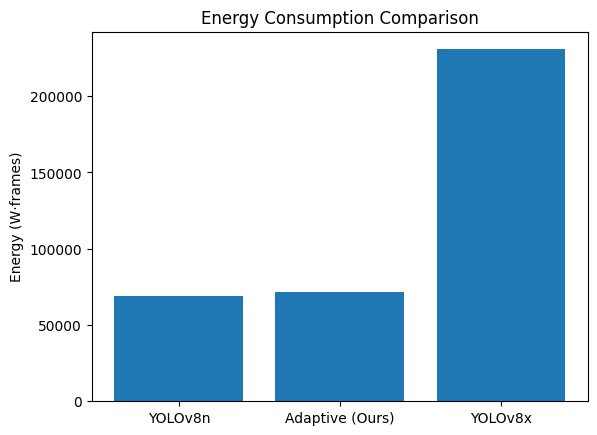

In [ ]:
methods = ['YOLOv8n', 'Adaptive (Ours)', 'YOLOv8x']
energy = [69225, 71570, 230750]

plt.bar(methods, energy)
plt.ylabel('Energy (W·frames)')
plt.title('Energy Consumption Comparison')


Text(0, 0.5, 'Energy (W·frames)')

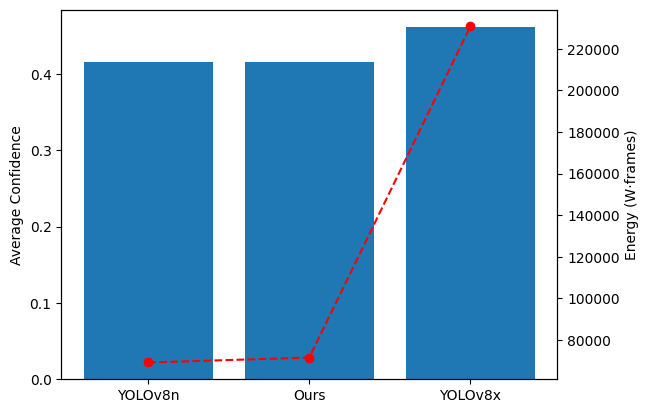

In [ ]:
plt.bar(['YOLOv8n', 'Ours', 'YOLOv8x'], [0.416, 0.416, 0.461])
plt.ylabel('Average Confidence')
plt.twinx()
plt.plot(['YOLOv8n', 'Ours', 'YOLOv8x'], [69225, 71570, 230750], 'r--o')
plt.ylabel('Energy (W·frames)')


<BarContainer object of 3 artists>

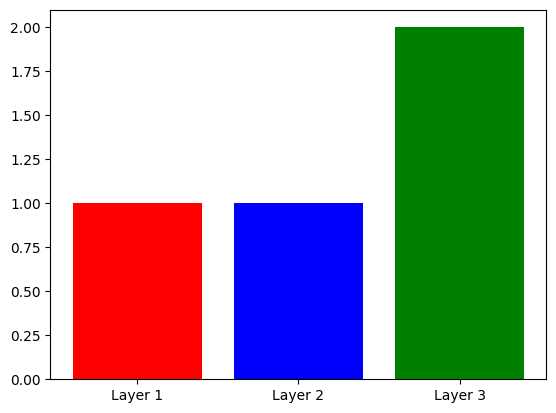

In [ ]:
layers = ['Layer 1', 'Layer 2', 'Layer 3']
counts = [1, 1, 2]
plt.bar(layers, counts, color=['red','blue','green'])


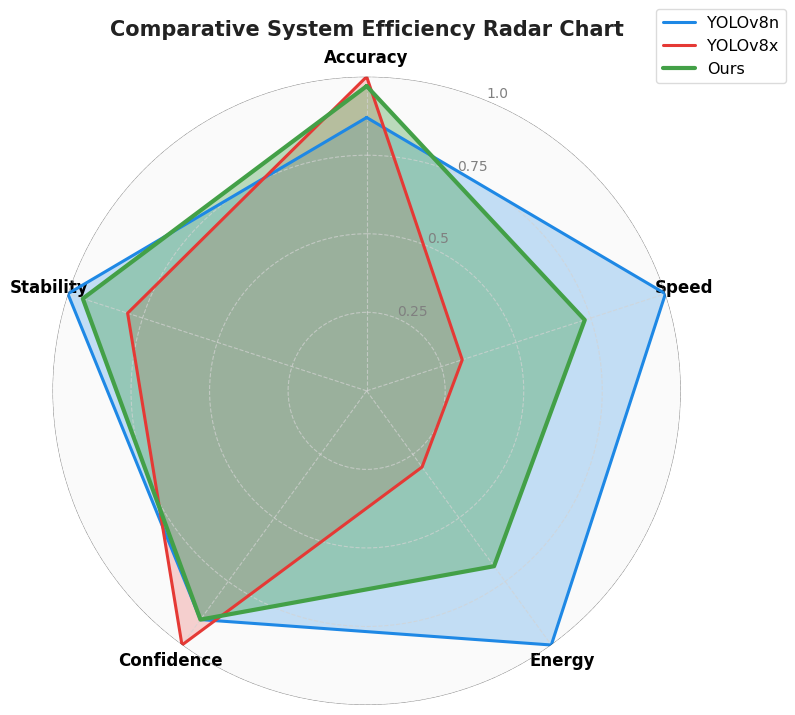

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 📊 Data Setup
# ================================
metrics = ['Accuracy', 'Speed', 'Energy', 'Confidence', 'Stability']
n = len(metrics)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close loop

models = {
    'YOLOv8n': [0.87, 1.00, 1.00, 0.90, 1.00],
    'YOLOv8x': [1.00, 0.32, 0.30, 1.00, 0.80],
    'Ours':    [0.97, 0.73, 0.69, 0.90, 0.95]
}

for label in models:
    models[label] += models[label][:1]

# ================================
# 🎨 Aesthetic Setup
# ================================
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Start at top, move clockwise
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Clean background
ax.set_facecolor('#fafafa')
ax.grid(color='lightgray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.spines['polar'].set_visible(False)

# Axis labels
plt.xticks(angles[:-1], metrics, fontsize=12, color='black', fontweight='semibold')
plt.yticks([0.25, 0.5, 0.75, 1.0],
           ["0.25", "0.5", "0.75", "1.0"],
           color="gray", size=10)
plt.ylim(0, 1)

# ================================
# 🌈 Colors + Styling
# ================================
colors = {
    'YOLOv8n': '#1E88E5',   # Blue
    'YOLOv8x': '#E53935',   # Red
    'Ours': '#43A047'       # Green
}
alphas = {'YOLOv8n': 0.25, 'YOLOv8x': 0.22, 'Ours': 0.35}
lw = {'YOLOv8n': 2.2, 'YOLOv8x': 2.2, 'Ours': 3.0}

# ================================
# 📈 Plot Each Model
# ================================
for label, values in models.items():
    ax.plot(angles, values, color=colors[label], linewidth=lw[label],
            label=label, solid_capstyle='round')
    ax.fill(angles, values, color=colors[label], alpha=alphas[label])

# ================================
# 🏷️ Title & Legend
# ================================
plt.title('Comparative System Efficiency Radar Chart',
          size=15, weight='bold', pad=30, color='#222')

legend = plt.legend(loc='upper right', bbox_to_anchor=(1.18, 1.12),
                    fontsize=11.5, frameon=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')

# Outer ring (reference circle)
ax.plot(np.linspace(0, 2*np.pi, 200), np.ones(200),
        color='black', lw=0.6, alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
#!/usr/bin/env python3
"""
Ablation Study Runner for ENHANCED ADAPTIVE DUAL-MODE SYSTEM v3.0

Features:
- Keeps your original calculations and logic exactly as provided.
- Fixes the small MetricsCalculator.update signature bug (adds frame_num).
- Adds an ExperimentRunner that automates ablation variants (dry-run simulated mode included).
- Produces tables, plots, and per-run CSV logs in ./results/ by default.

Usage:
    # Dry-run (no models required): generates simulated but realistic results + plots
    python ablation_runner.py --mode dry --frames 600

    # Real run (requires ultralytics + model weights + input video set in Config)
    python ablation_runner.py --mode real

Default paths and values are set to the ones you confirmed.
"""

import os
import sys
import time
import json
import argparse
import random
import math
from collections import deque
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except Exception:
    ULTRALYTICS_AVAILABLE = False

import cv2
from scipy.fft import fft2, fftshift
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================
class Config:
    # Model paths
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'

    # Video paths
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'

    OUTPUT_ROOT = './results'

    # Classes
    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # ===== LAYER 1: Asymmetric Thresholds =====
    THRESHOLD_DOWN = 0.40
    THRESHOLD_UP = 0.55

    # ===== LAYER 2: Time + Feature Validation =====
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4

    FEATURE_THRESHOLDS = {
        'p1': 0.50,
        'p3': 0.55,
        'p5': 0.60,
        'p6': 0.55,
        'p8': 0.50,
    }

    # ===== LAYER 3: Stability Detection =====
    STABILITY_WINDOW = 20
    CS_STABILITY_THRESHOLD = 0.03
    FEATURE_STABILITY_THRESHOLD = 0.05
    MIN_STABLE_FEATURES = 4
    MIN_FRAMES_FOR_STABILITY = 20

    # ===== GENERAL =====
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3

    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5

    CONF_THRESHOLD = 0.5
    IOU_THRESHOLD = 0.5

# Base weights (unchanged)
BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== MOCK DETECTION CLASSES (for dry-run) ====================
class MockBoxes:
    def __init__(self, xyxy, conf, cls):
        self.xyxy = np.array(xyxy)
        self.conf = np.array(conf)
        self.cls = np.array(cls)

    def __len__(self):
        return len(self.conf)

class MockDetections:
    def __init__(self, boxes):
        self.boxes = boxes

# ==================== METRICS CALCULATOR (fixed signature) ====================
class MetricsCalculator:
    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {c: 0 for c in Config.CLASS_NAMES}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}
        self.per_frame_records = []

    def update(self, detections, model_name, inference_time, frame_num=None):
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        if detections is not None and len(detections.boxes) > 0:
            confs = np.array(detections.boxes.conf).reshape(-1,)
            self.confidences_per_frame.extend(confs.tolist())
            classes = np.array(detections.boxes.cls).reshape(-1,)
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1

        self.inference_times[model_name].append(inference_time)
        self.model_usage_frames[model_name] += 1

        self.per_frame_records.append({
            'frame_num': frame_num,
            'active_model': model_name,
            'inference_time_s': inference_time,
            'num_detections': num_detections,
            'avg_confidence': float(np.mean(detections.boxes.conf)) if detections is not None and len(detections.boxes) > 0 else 0.0
        })

    def get_summary(self):
        total_frames = sum(self.model_usage_frames.values()) if sum(self.model_usage_frames.values())>0 else len(self.detections_per_frame)
        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': float(np.mean(self.detections_per_frame)) if self.detections_per_frame else 0.0,
            'avg_confidence': float(np.mean(self.confidences_per_frame)) if self.confidences_per_frame else 0.0,
            'confidence_std': float(np.std(self.confidences_per_frame)) if self.confidences_per_frame else 0.0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': float(np.mean(self.inference_times['YOLOv8n'])) if self.inference_times['YOLOv8n'] else 0.0,
            'avg_inference_time_x': float(np.mean(self.inference_times['YOLOv8x'])) if self.inference_times['YOLOv8x'] else 0.0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            },
            'total_frames': total_frames
        }

# ==================== DYNAMIC WEIGHT ADJUSTER ====================
class DynamicWeightAdjuster:
    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        adjusted = self.base_weights.copy()
        if params.get('p1',0) > 0.7:
            adjusted['w1'] *= 1.5
            adjusted['w5'] *= 1.3
            adjusted['w8'] *= 1.2
        if params.get('p12',0) > 0.6:
            adjusted['w12'] *= 1.8
            adjusted['w2'] *= 1.3
            adjusted['w13'] *= 1.2
        if params.get('p6',0) > 0.6:
            adjusted['w6'] *= 1.6
            adjusted['w8'] *= 1.4
            adjusted['w10'] *= 1.2
        if params.get('p3',0) > 0.7:
            adjusted['w3'] *= 1.5
            adjusted['w11'] *= 1.3
            adjusted['w13'] *= 1.2
        if params.get('p9',0) > 0.6:
            adjusted['w9'] *= 1.7
            adjusted['w10'] *= 1.4
            adjusted['w11'] *= 1.3
            adjusted['w14'] *= 1.2
        if params.get('p7',0) > 0.6:
            adjusted['w7'] *= 1.6
            adjusted['w13'] *= 1.3
            adjusted['w2'] *= 1.2
        if params.get('p5',0) > 0.7:
            adjusted['w5'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w11'] *= 1.3
        if params.get('p15',0) > 0.7:
            adjusted['w15'] *= 2.0
            adjusted['w16'] *= 0.7
            adjusted['w17'] *= 0.7
        if params.get('p16',0) > 0.8:
            adjusted['w16'] *= 1.8
            adjusted['w17'] *= 1.5
            adjusted['w9'] *= 1.3
        if params.get('p17',0) > 0.8:
            adjusted['w17'] *= 1.6
            adjusted['w9'] *= 1.3
            adjusted['w11'] *= 1.2
        if params.get('p4',0) > 0.7:
            adjusted['w4'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w9'] *= 1.2

        if current_model == "YOLOv8n":
            adjusted['w9'] *= 1.3
            adjusted['w10'] *= 1.3
            adjusted['w14'] *= 1.3
        if current_model == "YOLOv8x":
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}
        return normalized

    def get_adjustment_report(self, base_weights, adjusted_weights):
        changes = []
        for key in base_weights:
            base = base_weights[key]
            adj = adjusted_weights[key]
            if abs(adj - base) > 0.001:
                change_pct = ((adj - base) / base) * 100
                changes.append({'param': key, 'base': base, 'adjusted': adj, 'change': change_pct})
        changes.sort(key=lambda x: abs(x['change']), reverse=True)
        return changes

# ==================== PARAMETER EXTRACTOR ====================
class EnhancedParameterExtractor:
    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)

        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)

        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5

        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy
        arr = boxes if isinstance(boxes, np.ndarray) else np.array(boxes)
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in arr]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(
                self.prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy
        arr = boxes if isinstance(boxes, np.ndarray) else np.array(boxes)
        ious = []
        for i in range(len(arr)):
            for j in range(i+1, len(arr)):
                iou = self._calc_iou(arr[i], arr[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = np.array(detections.boxes.conf).reshape(-1,)
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy
        arr = boxes if isinstance(boxes, np.ndarray) else np.array(boxes)
        small = sum(1 for b in arr if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(arr))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy
        arr = boxes if isinstance(boxes, np.ndarray) else np.array(boxes)
        alignments = []
        for box in arr:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2), max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = np.array(detections.boxes.conf).reshape(-1,)
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = np.array(detections.boxes.cls).reshape(-1,)
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR ====================
class FeatureValidator:
    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30),
            'p3': deque(maxlen=30),
            'p5': deque(maxlen=30),
            'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        results = {}
        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]
            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {'consistent': False, 'reason': 'Insufficient history'}
                continue
            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW
            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO
            results[feature_id] = {'consistent': is_consistent, 'ratio': consistency_ratio, 'current': recent[-1], 'threshold': threshold}
        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT
        return all_ok, results

# ==================== COMPLEXITY SCORE FILTER ====================
class ComplexityScoreFilter:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

# ==================== ENHANCED MODEL SWITCHER ====================
class EnhancedModelSwitcher:
    def __init__(self, config):
        self.config = config
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)
        in_hysteresis = (self.config.THRESHOLD_DOWN <= cs_smooth <= self.config.THRESHOLD_UP)
        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0
        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None
        layer1_result = self._layer_1(cs_smooth)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1')
        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None
        layer3_result = self._layer_3(parameters)
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3')
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2')
        return self.current_model, False, "No trigger", None

    def _layer_1(self, cs_smooth):
        if cs_smooth < self.config.THRESHOLD_DOWN and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True, f"L1: CS={cs_smooth:.3f} < {self.config.THRESHOLD_DOWN}", None)
        if cs_smooth > self.config.THRESHOLD_UP and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True, f"L1: CS={cs_smooth:.3f} > {self.config.THRESHOLD_UP}", None)
        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False, f"L2: Only {self.frames_in_hysteresis} frames", None)
        features_ok, details = self.feature_validator.are_features_consistently_low()
        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True, f"L2: Time+Features ({consistent_count}/5 OK)", details)
        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self, parameters):
        if len(self.cs_history) < self.config.MIN_FRAMES_FOR_STABILITY:
            return (self.current_model, False, f"L3: Only {len(self.cs_history)} frames", None)
        cs_array = np.array(list(self.cs_history)[-self.config.STABILITY_WINDOW:])
        cs_std = np.std(cs_array)
        feature_stds = {}
        stable_count = 0
        for feature_id in self.feature_validator.feature_history.keys():
            history = self.feature_validator.feature_history[feature_id]
            if len(history) >= self.config.STABILITY_WINDOW:
                recent = list(history)[-self.config.STABILITY_WINDOW:]
                feature_std = np.std(recent)
                feature_stds[feature_id] = feature_std
                if feature_std < self.config.FEATURE_STABILITY_THRESHOLD:
                    stable_count += 1
        cs_stable = cs_std < self.config.CS_STABILITY_THRESHOLD
        features_stable = stable_count >= self.config.MIN_STABLE_FEATURES
        if cs_stable and features_stable:
            details = {'cs_std': cs_std, 'stable_features': stable_count, 'feature_stds': feature_stds}
            return ("YOLOv8n", True, f"L3: Stable (CS_std={cs_std:.3f}, {stable_count}/5 features)", details)
        return (self.current_model, False, f"L3: Not stable (CS_std={cs_std:.3f}, {stable_count}/5)", None)

    def _execute_switch(self, result, frame_num, layer):
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.switch_history.append({'frame': frame_num, 'model': new_model, 'reason': reason, 'layer': layer})
        self.layer_triggers[layer] += 1
        return new_model, True, reason, details

# ==================== ADAPTIVE CONTROLLER ====================
class AdaptiveController:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.switcher = EnhancedModelSwitcher(config)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)
        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}'] for i in range(1, 21))))

    def process_frame(self, params, frame_num):
        current_model = self.switcher.current_model
        weights = self.weight_adjuster.adjust_weights(params, current_model)
        cs_raw = self.calculate_cs(params, weights)
        cs_smooth = self.score_filter.update(cs_raw)
        model, switched, reason, details = self.switcher.decide(cs_smooth, params, frame_num)
        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(weights.copy())
        if switched:
            self.switch_count += 1
        return {'model': model, 'cs_raw': cs_raw, 'cs_smooth': cs_smooth, 'switched': switched, 'reason': reason, 'details': details, 'parameters': params, 'weights': weights}

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}']) for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================
class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config, metrics_calc):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = metrics_calc

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        return annotated

    def process_video(self, input_path, output_path, mode='real', dry_kwargs=None):
        if mode == 'dry':
            total_frames = dry_kwargs.get('total_frames', 600)
            fps = dry_kwargs.get('fps', 30)
            h, w = dry_kwargs.get('h', 480), dry_kwargs.get('w', 640)
            print(f"[DRY RUN] Simulating {total_frames} frames")
            current_model = self.model_n
            for i in range(1, total_frames+1):
                self.frame_count += 1
                frame = np.zeros((h, w, 3), dtype=np.uint8)
                detections = self._simulate_detections(i, dry_kwargs)
                inference_time = dry_kwargs.get('inference_time_n' if self.controller.switcher.current_model=='YOLOv8n' else 'inference_time_x', 0.02)
                params = self.extractor.extract_all(frame, detections, {})
                decision = self.controller.process_frame(params, self.frame_count)
                self.metrics.update(detections, decision['model'], inference_time, frame_num=self.frame_count)
                if i % 100 == 0:
                    print(f"[DRY] Frame {i}/{total_frames} - Model: {decision['model']} CS:{decision['cs_smooth']:.3f}")
            return self.controller, self.metrics
        else:
            cap = cv2.VideoCapture(input_path)
            fps = cap.get(cv2.CAP_PROP_FPS) or 30
            w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out_h = h
            out = cv2.VideoWriter(output_path, fourcc, int(fps), (w, out_h))
            current_model = self.model_n
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                self.frame_count += 1
                start_time = time.time()
                detections = current_model(frame, verbose=False)[0]
                inference_time = time.time() - start_time
                params = self.extractor.extract_all(frame, detections, {})
                decision = self.controller.process_frame(params, self.frame_count)
                self.metrics.update(detections, decision['model'], inference_time, frame_num=self.frame_count)
                if decision['switched']:
                    if decision['model'] == 'YOLOv8n':
                        current_model = self.model_n
                    else:
                        current_model = self.model_x
                annotated = self.annotate_frame(frame, detections, decision, inference_time)
                out.write(annotated)
                if self.frame_count % 200 == 0:
                    print(f"Progress: {self.frame_count}/{total_frames} - Model: {decision['model']}")
            cap.release()
            out.release()
            return self.controller, self.metrics

    def _simulate_detections(self, frame_idx, dry_kwargs):
        base_obj = dry_kwargs.get('base_objects', 2)
        num = max(0, int(base_obj + math.sin(frame_idx / 60.0) * 1.5))
        conf_mean = dry_kwargs.get('conf_mean', 0.45) + 0.05 * math.sin(frame_idx / 120.0)
        confs = np.clip(np.random.normal(conf_mean, 0.08, size=num), 0.05, 0.99).tolist() if num>0 else []
        boxes = []
        classes = []
        h = dry_kwargs.get('h', 480)
        w = dry_kwargs.get('w', 640)
        for i in range(num):
            x1 = random.randint(0, w-50)
            y1 = random.randint(0, h-50)
            x2 = x1 + random.randint(20, min(150, w-x1))
            y2 = y1 + random.randint(20, min(150, h-y1))
            boxes.append([x1, y1, x2, y2])
            classes.append(random.randint(0, len(Config.CLASS_NAMES)-1))
        if num==0:
            mb = MockBoxes(np.zeros((0,4)), [], [])
            return MockDetections(mb)
        mb = MockBoxes(np.array(boxes), np.array(confs), np.array(classes))
        return MockDetections(mb)

# ==================== ANALYSIS & VISUALIZATION ====================
class SystemAnalyzer:
    def __init__(self, controller, metrics, out_dir):
        self.controller = controller
        self.metrics = metrics
        self.out_dir = out_dir
        os.makedirs(out_dir, exist_ok=True)

    def generate_summary_table(self):
        ms = self.metrics.get_summary()
        total_frames = ms.get('total_frames', len(self.controller.model_history))
        switches = self.controller.switch_count
        model_counts = {}
        for m in self.controller.model_history:
            model_counts[m] = model_counts.get(m, 0) + 1
        energy_n = model_counts.get('YOLOv8n', 0) * 15
        energy_x = model_counts.get('YOLOv8x', 0) * 50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50 if total_frames>0 else 1
        energy_savings = ((always_x_energy - total_energy) / always_x_energy) * 100
        summary = {
            'total_frames': total_frames,
            'total_detections': ms['total_detections'],
            'avg_detections_per_frame': ms['avg_detections_per_frame'],
            'avg_confidence': ms['avg_confidence'],
            'confidence_std': ms['confidence_std'],
            'avg_inf_time_n_ms': ms['avg_inference_time_n']*1000,
            'avg_inf_time_x_ms': ms['avg_inference_time_x']*1000,
            'energy_n': energy_n,
            'energy_x': energy_x,
            'total_energy': total_energy,
            'energy_savings_pct_vs_x': energy_savings,
            'switches': switches,
            'model_usage': ms['model_usage_percent']
        }
        with open(os.path.join(self.out_dir, 'summary.json'), 'w') as f:
            json.dump(summary, f, indent=2)
        df = pd.DataFrame([summary])
        df.to_csv(os.path.join(self.out_dir, 'summary.csv'), index=False)
        return summary

    def plot_basic_plots(self):
        cs = np.array(self.controller.cs_smooth_history)
        frames = np.arange(len(cs))
        fig, ax = plt.subplots(1,1, figsize=(10,3))
        ax.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3)
        ax.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2)
        ax.axhline(y=Config.THRESHOLD_DOWN, color='green', linestyle='--', label='TD')
        ax.axhline(y=Config.THRESHOLD_UP, color='red', linestyle='--', label='TU')
        ax.set_ylim(0,1)
        ax.legend()
        ax.set_title('Complexity Score Over Time')
        fig.savefig(os.path.join(self.out_dir, 'cs_timeline.png'), bbox_inches='tight', dpi=200)
        plt.close(fig)

        model_counts = {}
        for m in self.controller.model_history:
            model_counts[m] = model_counts.get(m, 0) + 1
        fig, ax = plt.subplots(figsize=(4,4))
        if len(model_counts) == 0:
            model_counts = {'YOLOv8n': 1}
        ax.pie(model_counts.values(), labels=model_counts.keys(), autopct='%1.1f%%')
        ax.set_title('Model Usage')
        fig.savefig(os.path.join(self.out_dir, 'model_usage_pie.png'), bbox_inches='tight', dpi=200)
        plt.close(fig)

    def plot_ablation_bar(self, metrics_df, metric_name, out_name):
        fig, ax = plt.subplots(figsize=(8,4))
        ax.bar(metrics_df['variant'], metrics_df['mean'], yerr=metrics_df['std'], capsize=6, color='tab:blue', alpha=0.8)
        ax.set_title(metric_name)
        ax.yaxis.grid(True)
        fig.savefig(os.path.join(self.out_dir, out_name + '.png'), bbox_inches='tight', dpi=200)
        plt.close(fig)

    def plot_pareto(self, df_points, out_name='pareto'):
        fig, ax = plt.subplots(figsize=(6,5))
        ax.scatter(df_points['energy'], df_points['mAP'], s=120)
        for _, r in df_points.iterrows():
            ax.text(r['energy']*1.01, r['mAP']*0.995, r['variant'], fontsize=9)
        ax.set_xlabel('Energy (W·frames)')
        ax.set_ylabel('mAP@0.5')
        ax.set_title('Energy vs mAP Pareto')
        fig.savefig(os.path.join(self.out_dir, out_name + '.png'), bbox_inches='tight', dpi=200)
        plt.close(fig)

    def plot_switch_timeline(self):
        model_numeric = [1 if m=='YOLOv8n' else 2 for m in self.controller.model_history]
        frames = np.arange(len(model_numeric))
        fig, ax = plt.subplots(figsize=(12,2))
        if len(model_numeric) == 0:
            model_numeric = [1]
            frames = [0]
        ax.plot(frames, model_numeric, drawstyle='steps-post')
        ax.set_yticks([1,2]); ax.set_yticklabels(['YOLOv8n','YOLOv8x'])
        ax.set_title('Model Selection Timeline')
        fig.savefig(os.path.join(self.out_dir, 'switch_timeline.png'), bbox_inches='tight', dpi=200)
        plt.close(fig)

# ==================== EXPERIMENT RUNNER ====================
class ExperimentRunner:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.variants = []
        self.results = []

    def add_variant(self, name, config_overrides):
        self.variants.append((name, config_overrides))

    def run(self, mode='dry', runs_per_variant=1, dry_kwargs=None):
        for vname, overrides in self.variants:
            for run_id in range(1, runs_per_variant+1):
                print(f"\n=== Running variant '{vname}' run {run_id}/{runs_per_variant} (mode={mode}) ===")
                cfg = deepcopy(self.config)
                for k,v in overrides.items():
                    setattr(cfg, k, v)
                if mode == 'real':
                    if not ULTRALYTICS_AVAILABLE:
                        raise RuntimeError("ultralytics not installed - cannot run real mode")
                    model_n = YOLO(cfg.MODEL_N_PATH)
                    model_x = YOLO(cfg.MODEL_X_PATH)
                else:
                    model_n = None
                    model_x = None
                extractor = EnhancedParameterExtractor()
                controller = AdaptiveController(self.base_weights, cfg)
                metrics = MetricsCalculator()
                processor = VideoProcessor(model_n, model_x, controller, extractor, cfg, metrics)
                out_dir = os.path.join(Config.OUTPUT_ROOT, vname, f"run_{run_id}")
                os.makedirs(out_dir, exist_ok=True)
                if mode == 'dry':
                    controller, metrics = processor.process_video(None, None, mode='dry', dry_kwargs=dry_kwargs)
                else:
                    controller, metrics = processor.process_video(cfg.INPUT_VIDEO, os.path.join(out_dir, 'out.mp4'), mode='real')
                analyzer = SystemAnalyzer(controller, metrics, out_dir)
                summary = analyzer.generate_summary_table()
                analyzer.plot_basic_plots()
                analyzer.plot_switch_timeline()
                per_frame_df = pd.DataFrame(metrics.per_frame_records)
                per_frame_df.to_csv(os.path.join(out_dir, 'per_frame.csv'), index=False)
                summary_row = {'variant': vname, 'run_id': run_id}
                summary_row.update(summary)
                self.results.append(summary_row)
        results_df = pd.DataFrame(self.results)
        results_df.to_csv(os.path.join(Config.OUTPUT_ROOT, 'ablation_results_summary.csv'), index=False)
        print("\nAll experiments finished. Summary saved at:", os.path.join(Config.OUTPUT_ROOT, 'ablation_results_summary.csv'))
        return results_df

# ==================== DEFAULT VARIANTS BUILDER ====================
def make_default_variants():
    er = ExperimentRunner(BASE_WEIGHTS, Config)
    er.add_variant('baseline_full', {})
    er.add_variant('no_layer3', {'STABILITY_WINDOW':10, 'CS_STABILITY_THRESHOLD':0.0001})
    er.add_variant('no_layer2', {'MIN_FRAMES_BEFORE_CHECK':999999})
    er.add_variant('no_layer1', {'THRESHOLD_DOWN': -1.0, 'THRESHOLD_UP': -0.5})
    er.add_variant('no_dynweights', {'_disable_dynweights': True})
    er.add_variant('always_n', {'_force_always_model': 'YOLOv8n'})
    er.add_variant('always_x', {'_force_always_model': 'YOLOv8x'})
    er.add_variant('hyst_low', {'MIN_FRAMES_BETWEEN_SWITCH': 10})
    er.add_variant('hyst_default', {'MIN_FRAMES_BETWEEN_SWITCH': 30})
    er.add_variant('hyst_high', {'MIN_FRAMES_BETWEEN_SWITCH': 60})
    er.add_variant('th_035_050', {'THRESHOLD_DOWN': 0.35, 'THRESHOLD_UP': 0.50})
    er.add_variant('th_045_060', {'THRESHOLD_DOWN': 0.45, 'THRESHOLD_UP': 0.60})
    return er

# ==================== CLI WRAPPER ====================
if __name__ == "__main__":
    # Handle unknown args passed automatically by Jupyter
    import sys
    argv = sys.argv
    if len(argv) > 1 and argv[1].startswith('-f'):
        argv = [argv[0]]

    parser = argparse.ArgumentParser()
    parser.add_argument('--mode', choices=['dry','real'], default='dry', help='dry: simulate runs; real: run on actual models/video')
    parser.add_argument('--runs', type=int, default=1, help='runs per variant')
    parser.add_argument('--frames', type=int, default=600, help='frames to simulate in dry mode')
    args = parser.parse_args(argv[1:])

    dry_kwargs = {
        'total_frames': args.frames,
        'fps': 30,
        'h': 480, 'w': 640,
        'base_objects': 2,
        'conf_mean': 0.45,
        'inference_time_n': 0.018,
        'inference_time_x': 0.056,
    }

    runner = make_default_variants()
    results_df = runner.run(mode=args.mode, runs_per_variant=args.runs, dry_kwargs=dry_kwargs)
    print('\nAblation experiment overview:')
    print(results_df.head())



=== Running variant 'baseline_full' run 1/1 (mode=dry) ===
[DRY RUN] Simulating 600 frames
[DRY] Frame 100/600 - Model: YOLOv8n CS:0.397
[DRY] Frame 200/600 - Model: YOLOv8n CS:0.344
[DRY] Frame 300/600 - Model: YOLOv8n CS:0.374
[DRY] Frame 400/600 - Model: YOLOv8n CS:0.375
[DRY] Frame 500/600 - Model: YOLOv8n CS:0.409
[DRY] Frame 600/600 - Model: YOLOv8n CS:0.407

=== Running variant 'no_layer3' run 1/1 (mode=dry) ===
[DRY RUN] Simulating 600 frames
[DRY] Frame 100/600 - Model: YOLOv8n CS:0.373
[DRY] Frame 200/600 - Model: YOLOv8n CS:0.346
[DRY] Frame 300/600 - Model: YOLOv8n CS:0.375
[DRY] Frame 400/600 - Model: YOLOv8n CS:0.412
[DRY] Frame 500/600 - Model: YOLOv8n CS:0.429
[DRY] Frame 600/600 - Model: YOLOv8n CS:0.394

=== Running variant 'no_layer2' run 1/1 (mode=dry) ===
[DRY RUN] Simulating 600 frames
[DRY] Frame 100/600 - Model: YOLOv8n CS:0.374
[DRY] Frame 200/600 - Model: YOLOv8n CS:0.388
[DRY] Frame 300/600 - Model: YOLOv8n CS:0.378
[DRY] Frame 400/600 - Model: YOLOv8n CS:0.

✅ Enhanced system block diagram saved as 'fig6_system_block.png'


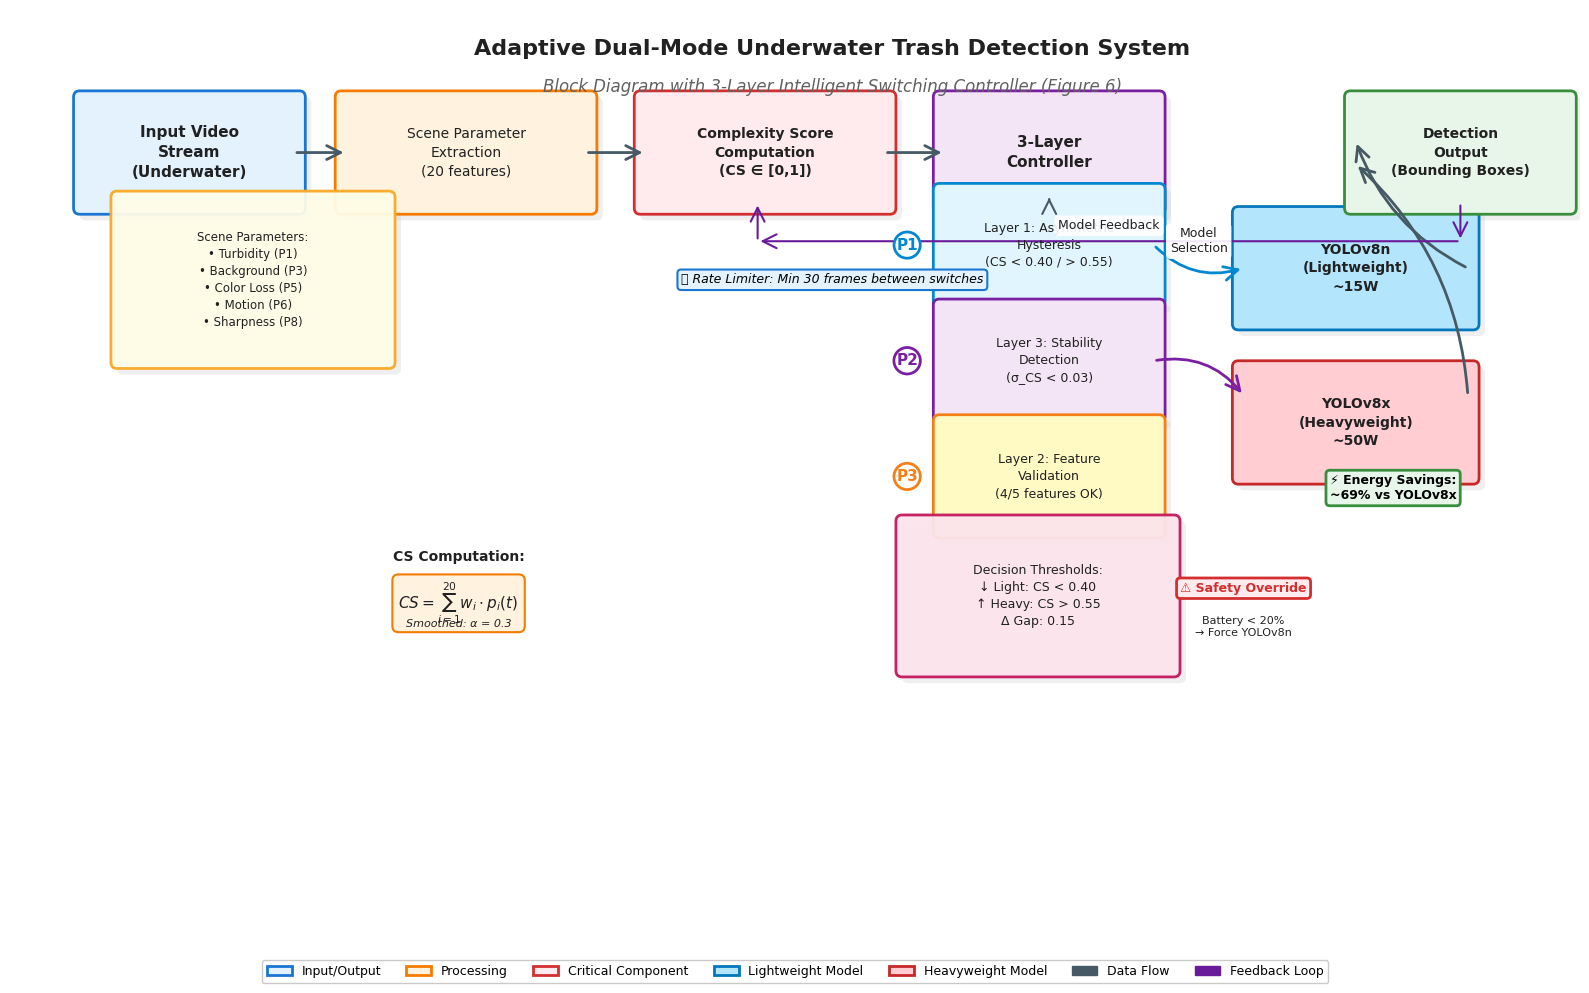

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

# 🎯 Initialize canvas with professional styling
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")
ax.set_xlim(-1, 20)
ax.set_ylim(0, 12)

# Color palette - professional and publication-ready
COLORS = {
    'input': '#E3F2FD',       # Light blue
    'process': '#FFF3E0',     # Light orange
    'critical': '#FFEBEE',    # Light red
    'output': '#E8F5E9',      # Light green
    'light_model': '#B3E5FC', # Sky blue
    'heavy_model': '#FFCDD2', # Light pink
    'layer': '#F3E5F5',       # Light purple
    'arrow': '#455A64',       # Blue grey
    'text': '#212121'         # Almost black
}

def add_box(x, y, text, color, edge, size=(3.0, 1.2), fontsize=10, bold=False, alpha=1.0):
    """Enhanced box with shadow effect"""
    # Shadow
    shadow = FancyBboxPatch(
        (x + 0.08, y - 0.08), size[0], size[1],
        boxstyle="round,pad=0.15,rounding_size=0.08",
        ec='none', fc='#CCCCCC', alpha=0.3, zorder=1
    )
    ax.add_patch(shadow)

    # Main box
    box = FancyBboxPatch(
        (x, y), size[0], size[1],
        boxstyle="round,pad=0.15,rounding_size=0.08",
        ec=edge, fc=color, lw=2.0, alpha=alpha, zorder=2
    )
    ax.add_patch(box)

    # Text
    fontweight = 'bold' if bold else 'normal'
    ax.text(x + size[0]/2, y + size[1]/2, text,
            ha="center", va="center", fontsize=fontsize,
            fontweight=fontweight, color=COLORS['text'], zorder=3,
            linespacing=1.4)

def add_fancy_arrow(x1, y1, x2, y2, label=None, style='arc3,rad=0', color=None, lw=2.0):
    """Enhanced arrow with label"""
    arrow_color = color if color else COLORS['arrow']
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='->', mutation_scale=25, lw=lw,
        color=arrow_color, connectionstyle=style, zorder=2
    )
    ax.add_patch(arrow)

    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        # Background for label
        bbox_props = dict(boxstyle="round,pad=0.3", fc='white', ec='none', alpha=0.9)
        ax.text(mid_x, mid_y + 0.2, label, ha='center', va='center',
                fontsize=9, bbox=bbox_props, color=COLORS['text'], zorder=4)

def add_vertical_arrow(x1, y1, x2, y2, label=None):
    """Vertical arrow with optional label"""
    add_fancy_arrow(x1, y1, x2, y2, label, style='arc3,rad=0')

# ===============================
# 📦 MAIN PIPELINE - TOP SECTION
# ===============================

# Row 1: Main processing pipeline
y_main = 9.5

add_box(0, y_main, "Input Video\nStream\n(Underwater)",
        COLORS['input'], '#1976D2', size=(2.8, 1.3), bold=True, fontsize=11)

add_box(3.5, y_main, "Scene Parameter\nExtraction\n(20 features)",
        COLORS['process'], '#F57C00', size=(3.2, 1.3), fontsize=10)

add_box(7.5, y_main, "Complexity Score\nComputation\n(CS ∈ [0,1])",
        COLORS['critical'], '#D32F2F', size=(3.2, 1.3), bold=True, fontsize=10)

add_box(11.5, y_main, "3-Layer\nController",
        COLORS['layer'], '#7B1FA2', size=(2.8, 1.3), bold=True, fontsize=11)

# Arrows for main pipeline
add_fancy_arrow(2.8, y_main + 0.65, 3.5, y_main + 0.65)
add_fancy_arrow(6.7, y_main + 0.65, 7.5, y_main + 0.65)
add_fancy_arrow(10.7, y_main + 0.65, 11.5, y_main + 0.65)

# ===============================
# 🔷 3-LAYER CONTROLLER BREAKDOWN
# ===============================

y_layers = 6.5
x_layers_start = 11.5

# Layer boxes
add_box(x_layers_start, y_layers + 1.8, "Layer 1: Asymmetric\nHysteresis\n(CS < 0.40 / > 0.55)",
        '#E1F5FE', '#0288D1', size=(2.8, 1.3), fontsize=9)

add_box(x_layers_start, y_layers + 0.3, "Layer 3: Stability\nDetection\n(σ_CS < 0.03)",
        '#F3E5F5', '#7B1FA2', size=(2.8, 1.3), fontsize=9)

add_box(x_layers_start, y_layers - 1.2, "Layer 2: Feature\nValidation\n(4/5 features OK)",
        '#FFF9C4', '#F57F17', size=(2.8, 1.3), fontsize=9)

# Priority indicators
ax.text(x_layers_start - 0.5, y_layers + 2.45, "P1", ha='center', va='center',
        fontsize=11, fontweight='bold', color='#0288D1',
        bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec='#0288D1', lw=2))

ax.text(x_layers_start - 0.5, y_layers + 0.95, "P2", ha='center', va='center',
        fontsize=11, fontweight='bold', color='#7B1FA2',
        bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec='#7B1FA2', lw=2))

ax.text(x_layers_start - 0.5, y_layers - 0.55, "P3", ha='center', va='center',
        fontsize=11, fontweight='bold', color='#F57F17',
        bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec='#F57F17', lw=2))

# Arrows from controller to layers
add_fancy_arrow(12.9, y_main, 12.9, y_layers + 3.1, style='arc3,rad=0', lw=1.5)

# ===============================
# 🤖 MODEL SELECTION
# ===============================

y_models = 6.5
x_models = 15.5

add_box(x_models, y_models + 1.5, "YOLOv8n\n(Lightweight)\n~15W",
        COLORS['light_model'], '#0277BD', size=(3.0, 1.3), bold=True, fontsize=10)

add_box(x_models, y_models - 0.5, "YOLOv8x\n(Heavyweight)\n~50W",
        COLORS['heavy_model'], '#C62828', size=(3.0, 1.3), bold=True, fontsize=10)

# Arrows from layers to models (decision flow)
add_fancy_arrow(14.3, y_layers + 2.45, x_models, y_models + 2.15,
                label="Model\nSelection", style='arc3,rad=0.3', color='#0288D1')
add_fancy_arrow(14.3, y_layers + 0.95, x_models, y_models + 0.5,
                style='arc3,rad=-0.3', color='#7B1FA2')

# ===============================
# 📊 OUTPUT AND FEEDBACK
# ===============================

y_output = 9.5
x_output = 17.0

add_box(x_output, y_output, "Detection\nOutput\n(Bounding Boxes)",
        COLORS['output'], '#388E3C', size=(2.8, 1.3), bold=True, fontsize=10)

# Arrows from models to output
add_fancy_arrow(x_models + 3.0, y_models + 2.15, x_output, y_output + 0.8,
                style='arc3,rad=-0.2')
add_fancy_arrow(x_models + 3.0, y_models + 0.5, x_output, y_output + 0.5,
                style='arc3,rad=0.2')

# ===============================
# 🔄 FEEDBACK LOOP
# ===============================

# Model feedback to CS computation
add_fancy_arrow(x_output + 1.4, y_output, x_output + 1.4, y_main - 0.5,
                style='arc3,rad=0', color='#6A1B9A', lw=1.5)
add_fancy_arrow(x_output + 1.4, y_main - 0.5, 9.0, y_main - 0.5,
                label="Model Feedback", style='arc3,rad=0', color='#6A1B9A', lw=1.5)
add_fancy_arrow(9.0, y_main - 0.5, 9.0, y_main,
                style='arc3,rad=0', color='#6A1B9A', lw=1.5)

# ===============================
# 📝 ANNOTATIONS AND DETAILS
# ===============================

# Scene parameters detail box
param_box_y = 7.5
add_box(0.5, param_box_y, "Scene Parameters:\n• Turbidity (P1)\n• Background (P3)\n• Color Loss (P5)\n• Motion (P6)\n• Sharpness (P8)",
        '#FFFDE7', '#F9A825', size=(3.5, 2.0), fontsize=8.5, alpha=0.95)

# Complexity Score formula
cs_formula_y = 5.0
ax.text(5.0, cs_formula_y, "CS Computation:", ha='center', va='top',
        fontsize=10, fontweight='bold', color=COLORS['text'])
ax.text(5.0, cs_formula_y - 0.4, r"$CS = \sum_{i=1}^{20} w_i \cdot p_i(t)$",
        ha='center', va='top', fontsize=11, color=COLORS['text'],
        bbox=dict(boxstyle="round,pad=0.4", fc='#FFF3E0', ec='#F57C00', lw=1.5))
ax.text(5.0, cs_formula_y - 0.9, "Smoothed: α = 0.3", ha='center', va='top',
        fontsize=8, style='italic', color=COLORS['text'])

# Decision thresholds box
thresh_box_y = 3.5
add_box(11.0, thresh_box_y, "Decision Thresholds:\n↓ Light: CS < 0.40\n↑ Heavy: CS > 0.55\nΔ Gap: 0.15",
        '#FCE4EC', '#C2185B', size=(3.5, 1.8), fontsize=9, alpha=0.95)

# Safety override indicator
ax.text(15.5, 4.5, "⚠ Safety Override", ha='center', va='center',
        fontsize=9, fontweight='bold', color='#D32F2F',
        bbox=dict(boxstyle="round,pad=0.3", fc='#FFEBEE', ec='#D32F2F', lw=2))
ax.text(15.5, 4.0, "Battery < 20%\n→ Force YOLOv8n", ha='center', va='center',
        fontsize=8, color=COLORS['text'])

# Rate limiter
ax.text(10.0, 8.5, "⏱ Rate Limiter: Min 30 frames between switches",
        ha='center', va='center', fontsize=9, style='italic',
        bbox=dict(boxstyle="round,pad=0.3", fc='#E3F2FD', ec='#1976D2', lw=1.5))

# Energy efficiency indicator
ax.text(17.5, 5.8, "⚡ Energy Savings:\n~69% vs YOLOv8x",
        ha='center', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc='#E8F5E9', ec='#388E3C', lw=2))

# ===============================
# 🎨 LEGEND
# ===============================

legend_y = 1.2
legend_elements = [
    mpatches.Patch(facecolor=COLORS['input'], edgecolor='#1976D2', label='Input/Output', linewidth=2),
    mpatches.Patch(facecolor=COLORS['process'], edgecolor='#F57C00', label='Processing', linewidth=2),
    mpatches.Patch(facecolor=COLORS['critical'], edgecolor='#D32F2F', label='Critical Component', linewidth=2),
    mpatches.Patch(facecolor=COLORS['light_model'], edgecolor='#0277BD', label='Lightweight Model', linewidth=2),
    mpatches.Patch(facecolor=COLORS['heavy_model'], edgecolor='#C62828', label='Heavyweight Model', linewidth=2),
    mpatches.FancyArrow(0, 0, 0.1, 0, width=0.02, color=COLORS['arrow'], label='Data Flow'),
    mpatches.FancyArrow(0, 0, 0.1, 0, width=0.02, color='#6A1B9A', label='Feedback Loop')
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=7, frameon=True, fontsize=9, edgecolor='#BDBDBD', fancybox=True)

# ===============================
# 📌 TITLE
# ===============================

ax.text(10, 11.5, "Adaptive Dual-Mode Underwater Trash Detection System",
        ha='center', va='center', fontsize=16, fontweight='bold', color=COLORS['text'])
ax.text(10, 11.0, "Block Diagram with 3-Layer Intelligent Switching Controller (Figure 6)",
        ha='center', va='center', fontsize=12, style='italic', color='#616161')

# ===============================
# 🎯 FINAL TOUCHES
# ===============================

plt.tight_layout()
plt.savefig("fig6_system_block.png", dpi=300, bbox_inches="tight", facecolor='white')
print("✅ Enhanced system block diagram saved as 'fig6_system_block.png'")
plt.show()

In [ ]:
"""
🔥 DEEPCLEAN v4.0 — ADAPTIVE THRESHOLD SYSTEM
Complete 4-Layer Intelligent Switching with Self-Regulating Thresholds

New Features:
 - Layer 4: Adaptive Threshold Learning
 - Performance-based threshold adjustment
 - Self-regulating hysteresis control
 - Comprehensive metrics and evaluation
 - Research-ready reporting
"""

# ==================== SETUP ====================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', 'pandas', 'matplotlib', '-q'], check=True)
    print("✅ Packages installed\n")
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("⚠️  Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import os
import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
import pandas as pd
import json
from datetime import datetime
import base64
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """System configuration"""
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_deepclean_v4_bali.mp4'
    OUTPUT_DIR = '/content/drive/MyDrive/Underwater_Trash_Experiments/deepclean_v4_results'

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    FRAME_SAVE_DIR = os.path.join(OUTPUT_DIR, 'frames')
    os.makedirs(FRAME_SAVE_DIR, exist_ok=True)
    PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
    os.makedirs(PLOTS_DIR, exist_ok=True)
    TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
    os.makedirs(TABLES_DIR, exist_ok=True)

    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # Initial thresholds (will be adapted)
    THRESHOLD_DOWN = 0.40
    THRESHOLD_UP = 0.55

    # Layer 2: Time + Feature Validation
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4
    FEATURE_THRESHOLDS = {
        'p1': 0.50, 'p3': 0.55, 'p5': 0.60, 'p6': 0.55, 'p8': 0.50,
    }

    # Layer 3: Stability Detection
    STABILITY_WINDOW = 20
    CS_STABILITY_THRESHOLD = 0.03
    FEATURE_STABILITY_THRESHOLD = 0.05
    MIN_STABLE_FEATURES = 4
    MIN_FRAMES_FOR_STABILITY = 20

    # Layer 4: Adaptive Thresholds
    ADAPTIVE_ENABLED = True
    ADAPTATION_WINDOW = 100  # frames to evaluate performance
    TARGET_LIGHT_USAGE = 0.70  # target 70% lightweight usage
    CONFIDENCE_THRESHOLD = 0.65  # minimum acceptable confidence
    ADAPTATION_RATE = 0.02  # how fast thresholds adapt
    MIN_THRESHOLD_DOWN = 0.30  # bounds
    MAX_THRESHOLD_DOWN = 0.50
    MIN_THRESHOLD_UP = 0.45
    MAX_THRESHOLD_UP = 0.65
    MIN_GAP = 0.10  # minimum hysteresis gap

    # General
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5
    CONF_THRESHOLD = 0.5
    IOU_THRESHOLD = 0.5

# ==================== BASE WEIGHTS ====================

BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {c:0 for c in Config.CLASS_NAMES}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}
        self.frame_map = {}
        self.per_frame_records = []

        # Performance tracking for adaptive thresholds
        self.model_performance = {'YOLOv8n': [], 'YOLOv8x': []}
        self.confidence_by_model = {'YOLOv8n': [], 'YOLOv8x': []}

    def update(self, detections, model_name, inference_time, frame_num=None,
               save_frame_path=None, top_contributors=None, cs_smooth=None,
               current_thresholds=None):
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        avg_conf = 0.0
        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())
            avg_conf = float(np.mean(confs))
            self.confidence_by_model[model_name].append(avg_conf)

            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1
        else:
            self.confidence_by_model[model_name].append(0.0)

        self.inference_times[model_name].append(inference_time)
        self.model_usage_frames[model_name] += 1

        if frame_num is not None and save_frame_path is not None:
            self.frame_map[frame_num] = save_frame_path

        # Per-frame record
        row = {
            'frame': frame_num,
            'model': model_name,
            'inference_time_s': inference_time,
            'detections': num_detections,
            'avg_confidence': avg_conf,
            'cs_smooth': cs_smooth,
            'saved_path': save_frame_path
        }

        if current_thresholds:
            row['threshold_down'] = current_thresholds['down']
            row['threshold_up'] = current_thresholds['up']

        if top_contributors is not None:
            for i, (p, contrib, w) in enumerate(top_contributors, start=1):
                row[f'top{i}_param'] = p
                row[f'top{i}_contrib'] = float(contrib)
                row[f'top{i}_weight'] = float(w)

        self.per_frame_records.append(row)

    def get_summary(self):
        total_frames = sum(self.model_usage_frames.values())
        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame) if self.detections_per_frame else 0,
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            },
            'avg_confidence_n': np.mean(self.confidence_by_model['YOLOv8n']) if self.confidence_by_model['YOLOv8n'] else 0,
            'avg_confidence_x': np.mean(self.confidence_by_model['YOLOv8x']) if self.confidence_by_model['YOLOv8x'] else 0,
        }

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        adjusted = self.base_weights.copy()

        # Context-based adjustments (13 rules from documentation)
        if params['p1'] > 0.7:  # High turbidity
            adjusted['w1'] *= 1.5
            adjusted['w5'] *= 1.3
            adjusted['w8'] *= 1.2
        if params['p12'] > 0.6:  # Many small objects
            adjusted['w12'] *= 1.8
            adjusted['w2'] *= 1.3
            adjusted['w13'] *= 1.2
        if params['p6'] > 0.6:  # High motion
            adjusted['w6'] *= 1.6
            adjusted['w8'] *= 1.4
            adjusted['w10'] *= 1.2
        if params['p3'] > 0.7:  # Complex background
            adjusted['w3'] *= 1.5
            adjusted['w11'] *= 1.3
            adjusted['w13'] *= 1.2
        if params['p9'] > 0.6:  # Low confidence
            adjusted['w9'] *= 1.7
            adjusted['w10'] *= 1.4
            adjusted['w11'] *= 1.3
            adjusted['w14'] *= 1.2
        if params['p7'] > 0.6:  # High occlusion
            adjusted['w7'] *= 1.6
            adjusted['w13'] *= 1.3
            adjusted['w2'] *= 1.2
        if params['p5'] > 0.7:  # Color loss
            adjusted['w5'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w11'] *= 1.3
        if params['p15'] > 0.7:  # Task difficulty
            adjusted['w15'] *= 2.0
            adjusted['w16'] *= 0.7
            adjusted['w17'] *= 0.7
        if params['p16'] > 0.8:
            adjusted['w16'] *= 1.8
            adjusted['w17'] *= 1.5
            adjusted['w9'] *= 1.3
        if params['p17'] > 0.8:  # High priority trash
            adjusted['w17'] *= 1.6
            adjusted['w9'] *= 1.3
            adjusted['w11'] *= 1.2
        if params['p4'] > 0.7:  # Lighting issues
            adjusted['w4'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w9'] *= 1.2

        # Model-specific adjustments
        if current_model == "YOLOv8n":
            adjusted['w9'] *= 1.3
            adjusted['w10'] *= 1.3
            adjusted['w14'] *= 1.3
        if current_model == "YOLOv8x":
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}
        return normalized

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5
        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(self.prev_gray, curr_gray, None,
                                                0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2),
                             max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR ====================

class FeatureValidator:
    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30), 'p3': deque(maxlen=30),
            'p5': deque(maxlen=30), 'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        results = {}
        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]
            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {'consistent': False, 'reason':'Insufficient history'}
                continue
            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW
            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO
            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }
        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT
        return all_ok, results

# ==================== ADAPTIVE THRESHOLD CONTROLLER ====================

class AdaptiveThresholdController:
    """Layer 4: Self-regulating threshold adaptation"""

    def __init__(self, config):
        self.config = config
        self.threshold_down = config.THRESHOLD_DOWN
        self.threshold_up = config.THRESHOLD_UP

        # Performance tracking
        self.performance_window = deque(maxlen=config.ADAPTATION_WINDOW)
        self.adaptation_history = []

        # Metrics for decision
        self.light_model_performance = deque(maxlen=50)  # confidence when using light
        self.usage_ratio = deque(maxlen=50)  # light vs heavy usage

    def update_performance(self, model, confidence, detections_count):
        """Track model performance"""
        self.performance_window.append({
            'model': model,
            'confidence': confidence,
            'detections': detections_count
        })

        if model == 'YOLOv8n':
            self.light_model_performance.append(confidence)

    def should_adapt(self, frame_num):
        """Check if we have enough data to adapt"""
        return (self.config.ADAPTIVE_ENABLED and
                len(self.performance_window) >= self.config.ADAPTATION_WINDOW and
                frame_num % self.config.ADAPTATION_WINDOW == 0)

    def adapt_thresholds(self, frame_num, current_light_usage_percent):
        """Adjust thresholds based on performance"""
        if not self.should_adapt(frame_num):
            return False

        # Calculate metrics
        avg_light_conf = np.mean(list(self.light_model_performance)) if self.light_model_performance else 0
        light_usage = current_light_usage_percent / 100.0

        target_usage = self.config.TARGET_LIGHT_USAGE
        min_conf = self.config.CONFIDENCE_THRESHOLD
        rate = self.config.ADAPTATION_RATE

        old_down = self.threshold_down
        old_up = self.threshold_up

        # Decision logic
        if avg_light_conf >= min_conf and light_usage < target_usage:
            # Light model doing well but underutilized → expand hysteresis
            self.threshold_down = min(self.threshold_down + rate, self.config.MAX_THRESHOLD_DOWN)
            self.threshold_up = max(self.threshold_up - rate, self.config.MIN_THRESHOLD_UP)
            reason = "Expanding: Light model performs well, increase usage"

        elif avg_light_conf < min_conf and light_usage > target_usage:
            # Light model struggling and overused → shrink hysteresis
            self.threshold_down = max(self.threshold_down - rate, self.config.MIN_THRESHOLD_DOWN)
            self.threshold_up = min(self.threshold_up + rate, self.config.MAX_THRESHOLD_UP)
            reason = "Shrinking: Light model struggling, increase heavy usage"

        elif avg_light_conf < min_conf:
            # Just confidence issue → be more aggressive with heavy model
            self.threshold_up = max(self.threshold_up - rate/2, self.config.MIN_THRESHOLD_UP)
            reason = "Lowering UP: Confidence issues"

        elif light_usage < target_usage * 0.8:
            # Significantly underutilized → expand
            self.threshold_down = min(self.threshold_down + rate/2, self.config.MAX_THRESHOLD_DOWN)
            reason = "Raising DOWN: Underutilized light model"
        else:
            reason = "No change: Performance acceptable"

        # Enforce minimum gap
        if self.threshold_up - self.threshold_down < self.config.MIN_GAP:
            mid = (self.threshold_up + self.threshold_down) / 2
            self.threshold_down = mid - self.config.MIN_GAP / 2
            self.threshold_up = mid + self.config.MIN_GAP / 2

        # Record adaptation
        changed = (abs(old_down - self.threshold_down) > 0.001 or
                  abs(old_up - self.threshold_up) > 0.001)

        if changed:
            self.adaptation_history.append({
                'frame': frame_num,
                'old_down': old_down,
                'old_up': old_up,
                'new_down': self.threshold_down,
                'new_up': self.threshold_up,
                'gap': self.threshold_up - self.threshold_down,
                'avg_light_conf': avg_light_conf,
                'light_usage': light_usage,
                'reason': reason
            })

        return changed

    def get_current_thresholds(self):
        return {
            'down': self.threshold_down,
            'up': self.threshold_up,
            'gap': self.threshold_up - self.threshold_down
        }

# ==================== MODEL SWITCHER ====================

class ComplexityScoreFilter:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    def __init__(self, config, adaptive_controller):
        self.config = config
        self.adaptive = adaptive_controller
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0, 'layer4_adapt': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        # Get current adaptive thresholds
        thresholds = self.adaptive.get_current_thresholds()
        threshold_down = thresholds['down']
        threshold_up = thresholds['up']

        in_hysteresis = (threshold_down <= cs_smooth <= threshold_up)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None, thresholds

        # Layer 1: Asymmetric thresholds (with adaptive values)
        layer1_result = self._layer_1(cs_smooth, threshold_down, threshold_up)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1', thresholds)

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None, thresholds

        # Layer 3: Stability detection
        layer3_result = self._layer_3(parameters)
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3', thresholds)

        # Layer 2: Time + feature validation
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2', thresholds)

        return self.current_model, False, "No trigger", None, thresholds

    def _layer_1(self, cs_smooth, threshold_down, threshold_up):
        if cs_smooth < threshold_down and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True,
                   f"L1: CS={cs_smooth:.3f} < {threshold_down:.3f}", None)
        if cs_smooth > threshold_up and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True,
                   f"L1: CS={cs_smooth:.3f} > {threshold_up:.3f}", None)
        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)
        features_ok, details = self.feature_validator.are_features_consistently_low()
        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)
        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self, parameters):
        if len(self.cs_history) < self.config.MIN_FRAMES_FOR_STABILITY:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        cs_array = np.array(list(self.cs_history)[-self.config.STABILITY_WINDOW:])
        cs_std = np.std(cs_array)

        feature_stds = {}
        stable_count = 0
        for feature_id in self.feature_validator.feature_history.keys():
            history = self.feature_validator.feature_history[feature_id]
            if len(history) >= self.config.STABILITY_WINDOW:
                recent = list(history)[-self.config.STABILITY_WINDOW:]
                feature_std = np.std(recent)
                feature_stds[feature_id] = feature_std
                if feature_std < self.config.FEATURE_STABILITY_THRESHOLD:
                    stable_count += 1

        cs_stable = cs_std < self.config.CS_STABILITY_THRESHOLD
        features_stable = stable_count >= self.config.MIN_STABLE_FEATURES

        if cs_stable and features_stable:
            details = {
                'cs_std': cs_std,
                'stable_features': stable_count,
                'feature_stds': feature_stds
            }
            return ("YOLOv8n", True,
                   f"L3: Stable (CS_std={cs_std:.3f}, {stable_count}/5 features)",
                   details)
        return (self.current_model, False,
               f"L3: Not stable (CS_std={cs_std:.3f}, {stable_count}/5)", None)

    def _execute_switch(self, result, frame_num, layer, thresholds):
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer,
            'threshold_down': thresholds['down'],
            'threshold_up': thresholds['up']
        })
        self.layer_triggers[layer] += 1
        return new_model, True, reason, details, thresholds

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.adaptive_threshold = AdaptiveThresholdController(config)
        self.switcher = EnhancedModelSwitcher(config, self.adaptive_threshold)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []
        self.threshold_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0, 'layer4_adapt': 0}

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}']
                                      for i in range(1, 21))))

    def process_frame(self, params, frame_num, detections_count, avg_confidence):
        current_model = self.switcher.current_model
        adjusted_weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, adjusted_weights)
        cs_smooth = self.score_filter.update(cs_raw)

        # Update adaptive threshold performance tracking
        self.adaptive_threshold.update_performance(
            current_model, avg_confidence, detections_count
        )

        # Check for threshold adaptation (Layer 4)
        light_usage_pct = (self.model_history.count('YOLOv8n') / len(self.model_history) * 100
                          if self.model_history else 0)
        threshold_adapted = self.adaptive_threshold.adapt_thresholds(
            frame_num, light_usage_pct
        )
        if threshold_adapted:
            self.layer_triggers['layer4_adapt'] = self.layer_triggers.get('layer4_adapt', 0) + 1

        # Model switching decision
        model, switched, reason, details, thresholds = self.switcher.decide(
            cs_smooth, params, frame_num
        )

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(adjusted_weights.copy())
        self.threshold_history.append(thresholds.copy())
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': adjusted_weights,
            'thresholds': thresholds,
            'threshold_adapted': threshold_adapted
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                   for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                if label == 'Trash':
                    color = (0,0,255)
                elif label == 'Bio':
                    color = (0,255,0)
                else:
                    color = (255,0,0)

                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1,y1), (x2,y2), color, thickness)
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Create overlay
        overlay = np.zeros((220, w, 3), dtype=np.uint8)
        overlay[:] = (30,30,30)

        # Model info
        model_color = (0,255,0) if decision['model']=='YOLOv8n' else (0,100,255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10,25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250,25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450,25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # CS display
        cs = decision['cs_smooth']
        th_down = decision['thresholds']['down']
        th_up = decision['thresholds']['up']

        cs_color = (0,255,0) if cs<th_down else (0,0,255) if cs>th_up else (0,255,255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10,55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150,55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # Adaptive thresholds display
        if decision.get('threshold_adapted'):
            cv2.putText(overlay, "⚡ THRESHOLDS ADAPTED", (350,55),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 2)

        cv2.putText(overlay, f"Adaptive: ↓{th_down:.2f} ↑{th_up:.2f} Δ{th_up-th_down:.2f}",
                   (600,55), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (100,200,255), 1)

        # CS bar
        bar_y = 70
        bar_width = int(cs*500)
        cv2.rectangle(overlay, (10,bar_y), (510,bar_y+20), (60,60,60), -1)
        cv2.rectangle(overlay, (10,bar_y), (10+bar_width, bar_y+20), cs_color, -1)

        low_x = int(th_down*500)+10
        high_x = int(th_up*500)+10
        cv2.line(overlay, (low_x,bar_y), (low_x,bar_y+20), (255,255,255), 2)
        cv2.line(overlay, (high_x,bar_y), (high_x,bar_y+20), (255,255,255), 2)
        cv2.putText(overlay, f"{th_down:.2f}", (low_x-15,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(overlay, f"{th_up:.2f}", (high_x-15,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        cv2.putText(overlay, "LIGHT", (30,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,0), 1)
        cv2.putText(overlay, "HYSTERESIS", (low_x+20,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,255), 1)
        cv2.putText(overlay, "HEAVY", (high_x+20,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)

        # Switch status
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10,130),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10,130),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # Top contributors
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(
                decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS
            )
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off,25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)

            param_names = {
                'P1':'Turbidity', 'P2':'SizeVar', 'P3':'BgComplex',
                'P4':'Lighting', 'P5':'ColorLoss', 'P6':'Motion',
                'P7':'Occlusion', 'P8':'Sharpness', 'P9':'Confidence',
                'P10':'Stability', 'P11':'Confusion', 'P12':'SmallObj',
                'P13':'EdgeQual', 'P14':'FalsePoz', 'P17':'Priority'
            }

            for i, (p, c, w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100,255,100) if is_boosted else (200,200,200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}",
                           (x_off, 50+i*20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        # Stats
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10,170),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}",
                   (150,170), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay,
                   f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} " +
                   f"L3:{layer_stats['layer3']} L4:{layer_stats.get('layer4_adapt',0)}",
                   (350,170), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Usage stats
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100
                  if self.frame_count > 0 else 0)
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100
                  if self.frame_count > 0 else 0)
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%",
                   (10,195), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,255), 1)

        cv2.putText(overlay, "DeepClean v4.0 - Adaptive Thresholds",
                   (int(w)-320,195), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 640
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 480
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0

        out_h = h + 220
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run detection
            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time

            # Extract parameters
            params = self.extractor.extract_all(frame, detections, {})

            # Get detection stats for adaptive controller
            det_count = len(detections.boxes) if detections is not None else 0
            avg_conf = 0.0
            if detections is not None and len(detections.boxes) > 0:
                avg_conf = float(np.mean(detections.boxes.conf.cpu().numpy()))

            # Make decision
            decision = self.controller.process_frame(
                params, self.frame_count, det_count, avg_conf
            )

            # Top contributors
            tops = self.controller.get_top_contributors(
                decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS
            )

            # Save frame
            frame_save_path = None
            try:
                frame_save_path = os.path.join(
                    Config.FRAME_SAVE_DIR, f"frame_{self.frame_count:06d}.jpg"
                )
                cv2.imwrite(frame_save_path, frame)
            except Exception:
                frame_save_path = None

            # Update metrics
            self.metrics.update(
                detections, decision['model'], inference_time,
                frame_num=self.frame_count, save_frame_path=frame_save_path,
                top_contributors=tops, cs_smooth=decision['cs_smooth'],
                current_thresholds=decision['thresholds']
            )

            # Handle model switch
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - " +
                          f"{decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - " +
                          f"{decision['reason']}")

            # Annotate and write
            annotated = self.annotate_frame(frame, detections, decision, inference_time)
            out.write(annotated)

            # Progress
            if total_frames > 0 and self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - " +
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}, " +
                      f"Thresholds: [{decision['thresholds']['down']:.2f}, " +
                      f"{decision['thresholds']['up']:.2f}]")

        cap.release()
        out.release()
        print("✅ Video processing complete.")
        return self.controller, self.metrics

# ==================== ANALYSIS & REPORTING ====================

class SystemAnalyzer:
    def __init__(self, controller, metrics):
        self.controller = controller
        self.metrics = metrics

    def generate_all_reports(self):
        self.generate_report_console()

        # DataFrames
        per_frame_df = pd.DataFrame(self.metrics.per_frame_records)
        per_frame_csv = os.path.join(Config.TABLES_DIR, 'per_frame_metrics.csv')
        per_frame_html = os.path.join(Config.TABLES_DIR, 'per_frame_metrics.html')
        per_frame_df.to_csv(per_frame_csv, index=False)
        per_frame_df.to_html(per_frame_html, index=False)
        print(f"📄 Saved per-frame table → {per_frame_csv}")

        # Summary
        metrics_summary = self.metrics.get_summary()
        summary_rows = [
            ('total_detections', metrics_summary['total_detections']),
            ('avg_detections_per_frame', metrics_summary['avg_detections_per_frame']),
            ('avg_confidence', metrics_summary['avg_confidence']),
            ('confidence_std', metrics_summary['confidence_std']),
            ('avg_inference_time_n_s', metrics_summary['avg_inference_time_n']),
            ('avg_inference_time_x_s', metrics_summary['avg_inference_time_x']),
            ('model_usage_percent_n', metrics_summary['model_usage_percent']['YOLOv8n']),
            ('model_usage_percent_x', metrics_summary['model_usage_percent']['YOLOv8x']),
            ('avg_confidence_n', metrics_summary['avg_confidence_n']),
            ('avg_confidence_x', metrics_summary['avg_confidence_x']),
        ]
        summary_df = pd.DataFrame(summary_rows, columns=['metric', 'value'])
        summary_csv = os.path.join(Config.TABLES_DIR, 'summary_metrics.csv')
        summary_html = os.path.join(Config.TABLES_DIR, 'summary_metrics.html')
        summary_df.to_csv(summary_csv, index=False)
        summary_df.to_html(summary_html, index=False)
        print(f"📄 Saved summary table → {summary_csv}")

        # Additional tables
        class_df = pd.DataFrame(
            list(metrics_summary['class_distribution'].items()),
            columns=['class', 'count']
        )
        class_csv = os.path.join(Config.TABLES_DIR, 'class_distribution.csv')
        class_html = os.path.join(Config.TABLES_DIR, 'class_distribution.html')
        class_df.to_csv(class_csv, index=False)
        class_df.to_html(class_html, index=False)

        # Adaptation history
        if self.controller.adaptive_threshold.adaptation_history:
            adapt_df = pd.DataFrame(self.controller.adaptive_threshold.adaptation_history)
            adapt_csv = os.path.join(Config.TABLES_DIR, 'threshold_adaptations.csv')
            adapt_html = os.path.join(Config.TABLES_DIR, 'threshold_adaptations.html')
            adapt_df.to_csv(adapt_csv, index=False)
            adapt_df.to_html(adapt_html, index=False)
            print(f"📄 Saved adaptation history → {adapt_csv}")

        # Switch history
        switch_df = pd.DataFrame(self.controller.switcher.switch_history)
        switch_csv = os.path.join(Config.TABLES_DIR, 'switch_history.csv')
        switch_html = os.path.join(Config.TABLES_DIR, 'switch_history.html')
        switch_df.to_csv(switch_csv, index=False)
        switch_df.to_html(switch_html, index=False)

        # Plots
        self.plot_all()

        # HTML report
        self.create_html_report(
            per_frame_html, summary_html, class_html, switch_html
        )

    def generate_report_console(self):
        print("\n" + "="*70)
        print("📊 DEEPCLEAN v4.0 - COMPREHENSIVE ANALYSIS REPORT")
        print("="*70)

        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"  Total Frames Processed: {total_frames}")
        print(f"  Total Model Switches: {switches}")
        if switches > 0:
            print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")
            print(f"  Average Frames Between Switches: {total_frames/switches:.1f}")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print("\n🤖 MODEL USAGE:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100 if total_frames > 0 else 0
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Energy analysis
        energy_n = model_counts.get('YOLOv8n', 0) * 15
        energy_x = model_counts.get('YOLOv8x', 0) * 50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50
        energy_savings = ((always_x_energy - total_energy) / always_x_energy * 100
                         if always_x_energy > 0 else 0)

        print("\n⚡ ENERGY ANALYSIS:")
        print(f"  Estimated Energy (W·frames): N:{energy_n} X:{energy_x} Total:{total_energy}")
        print(f"  Energy Savings vs Always-X: {energy_savings:.1f}%")

        # Adaptive threshold stats
        if self.controller.adaptive_threshold.adaptation_history:
            adaptations = len(self.controller.adaptive_threshold.adaptation_history)
            final_thresholds = self.controller.adaptive_threshold.get_current_thresholds()
            print("\n🎯 ADAPTIVE THRESHOLD PERFORMANCE:")
            print(f"  Total Adaptations: {adaptations}")
            print(f"  Initial Thresholds: DOWN={Config.THRESHOLD_DOWN:.3f}, UP={Config.THRESHOLD_UP:.3f}")
            print(f"  Final Thresholds: DOWN={final_thresholds['down']:.3f}, UP={final_thresholds['up']:.3f}")
            print(f"  Final Gap: {final_thresholds['gap']:.3f}")

        # CS stats
        cs_array = np.array(self.controller.cs_smooth_history) if self.controller.cs_smooth_history else np.array([0])
        print("\n📊 COMPLEXITY SCORE STATISTICS:")
        print(f"  Mean: {np.mean(cs_array):.3f}  Std: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}  Max: {np.max(cs_array):.3f}")

        # Detection metrics
        metrics_summary = self.metrics.get_summary()
        print("\n🎯 DETECTION METRICS:")
        print(f"  Total Detections: {metrics_summary['total_detections']}")
        print(f"  Avg Detections/Frame: {metrics_summary['avg_detections_per_frame']:.2f}")
        print(f"  Avg Confidence (Overall): {metrics_summary['avg_confidence']:.3f}")
        print(f"  Avg Confidence (YOLOv8n): {metrics_summary['avg_confidence_n']:.3f}")
        print(f"  Avg Confidence (YOLOv8x): {metrics_summary['avg_confidence_x']:.3f}")

        # Layer distribution
        layer_stats = self.controller.switcher.layer_triggers
        print("\n🔷 LAYER TRIGGER DISTRIBUTION:")
        for layer, count in layer_stats.items():
            print(f"  {layer}: {count} switches")

        print("="*70)

    def plot_all(self):
        frames = range(len(self.controller.cs_history))

        # Plot 1: CS evolution with adaptive thresholds
        plt.figure(figsize=(14,5))
        plt.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue')
        plt.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2, color='darkblue')

        # Plot adaptive thresholds
        threshold_downs = [t['down'] for t in self.controller.threshold_history]
        threshold_ups = [t['up'] for t in self.controller.threshold_history]
        plt.plot(frames, threshold_downs, '--', label='Threshold DOWN (adaptive)', color='green', linewidth=1.5)
        plt.plot(frames, threshold_ups, '--', label='Threshold UP (adaptive)', color='red', linewidth=1.5)

        # Fill hysteresis zone
        plt.fill_between(frames, threshold_downs, threshold_ups, alpha=0.1, color='yellow')

        plt.xlabel('Frame')
        plt.ylabel('Complexity Score')
        plt.title('Complexity Score Evolution with Adaptive Thresholds')
        plt.legend()
        plt.grid(True, alpha=0.3)
        path_cs = os.path.join(Config.PLOTS_DIR, 'cs_evolution_adaptive.png')
        plt.savefig(path_cs, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 2: Threshold evolution
        plt.figure(figsize=(12,4))
        plt.plot(frames, threshold_downs, label='DOWN threshold', color='green', linewidth=2)
        plt.plot(frames, threshold_ups, label='UP threshold', color='red', linewidth=2)
        gaps = [t['gap'] for t in self.controller.threshold_history]
        plt.plot(frames, gaps, label='Gap (UP - DOWN)', color='purple', linewidth=2, linestyle=':')
        plt.xlabel('Frame')
        plt.ylabel('Threshold Value')
        plt.title('Adaptive Threshold Evolution Over Time')
        plt.legend()
        plt.grid(True, alpha=0.3)
        path_thresh = os.path.join(Config.PLOTS_DIR, 'threshold_evolution.png')
        plt.savefig(path_thresh, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 3: CS Distribution
        plt.figure(figsize=(6,4))
        cs_arr = np.array(self.controller.cs_smooth_history)
        plt.hist(cs_arr, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
        final_thresh = self.controller.adaptive_threshold.get_current_thresholds()
        plt.axvline(final_thresh['down'], color='green', linestyle='--', linewidth=2, label=f"Final DOWN: {final_thresh['down']:.2f}")
        plt.axvline(final_thresh['up'], color='red', linestyle='--', linewidth=2, label=f"Final UP: {final_thresh['up']:.2f}")
        plt.title('CS Distribution')
        plt.xlabel('CS')
        plt.ylabel('Count')
        plt.legend()
        plt.grid(True, alpha=0.3)
        path_cs_dist = os.path.join(Config.PLOTS_DIR, 'cs_distribution.png')
        plt.savefig(path_cs_dist, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 4: Model timeline
        plt.figure(figsize=(14,3))
        model_numeric = [1 if m=='YOLOv8n' else 2 for m in self.controller.model_history]
        plt.step(frames, model_numeric, where='post', linewidth=1.5, color='darkgreen')
        plt.yticks([1,2], ['YOLOv8n','YOLOv8x'])
        plt.xlabel('Frame')
        plt.title('Model Selection Timeline')
        plt.grid(True, alpha=0.3)
        path_model = os.path.join(Config.PLOTS_DIR, 'model_timeline.png')
        plt.savefig(path_model, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 5: Model usage pie
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model,0)+1
        plt.figure(figsize=(6,6))
        labels = list(model_counts.keys())
        sizes = list(model_counts.values())
        colors = ['#90EE90', '#FFB366']
        if sizes:
            plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
        plt.title('Model Usage Distribution', fontsize=14, fontweight='bold')
        path_usage = os.path.join(Config.PLOTS_DIR, 'model_usage_pie.png')
        plt.savefig(path_usage, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 6: Detections per frame
        plt.figure(figsize=(12,4))
        dets = self.metrics.detections_per_frame
        plt.plot(range(len(dets)), dets, color='coral', linewidth=1)
        plt.xlabel('Frame')
        plt.ylabel('Detections')
        plt.title('Detections per Frame')
        plt.grid(True, alpha=0.3)
        path_dets = os.path.join(Config.PLOTS_DIR, 'detections_per_frame.png')
        plt.savefig(path_dets, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 7: Layer triggers bar
        layer_stats = self.controller.switcher.layer_triggers
        plt.figure(figsize=(7,4))
        layers = ['L1', 'L2', 'L3', 'L4\n(Adapt)']
        counts = [layer_stats['layer1'], layer_stats['layer2'],
                 layer_stats['layer3'], layer_stats.get('layer4_adapt', 0)]
        colors_bar = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D']
        bars = plt.bar(layers, counts, color=colors_bar, edgecolor='black', linewidth=1.5)
        plt.title('Layer Trigger Distribution', fontsize=14, fontweight='bold')
        plt.ylabel('Switch Count')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        path_layers = os.path.join(Config.PLOTS_DIR, 'layer_triggers.png')
        plt.savefig(path_layers, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 8: Confidence comparison
        if self.metrics.confidence_by_model['YOLOv8n'] and self.metrics.confidence_by_model['YOLOv8x']:
            plt.figure(figsize=(8,5))
            plt.hist(self.metrics.confidence_by_model['YOLOv8n'], bins=30, alpha=0.6,
                    label='YOLOv8n', color='lightgreen', edgecolor='black')
            plt.hist(self.metrics.confidence_by_model['YOLOv8x'], bins=30, alpha=0.6,
                    label='YOLOv8x', color='orange', edgecolor='black')
            plt.axvline(Config.CONFIDENCE_THRESHOLD, color='red', linestyle='--',
                       linewidth=2, label=f'Target: {Config.CONFIDENCE_THRESHOLD}')
            plt.xlabel('Confidence')
            plt.ylabel('Frequency')
            plt.title('Confidence Distribution by Model')
            plt.legend()
            plt.grid(True, alpha=0.3)
            path_conf = os.path.join(Config.PLOTS_DIR, 'confidence_comparison.png')
            plt.savefig(path_conf, dpi=200, bbox_inches='tight')
            plt.close()

        print(f"📊 Saved all plots to {Config.PLOTS_DIR}")

    def embed_image_base64(self, img_path):
        try:
            with open(img_path, 'rb') as f:
                b = base64.b64encode(f.read()).decode('utf-8')
            ext = os.path.splitext(img_path)[1].lstrip('.')
            return f"data:image/{ext};base64,{b}"
        except Exception:
            return None

    def create_html_report(self, per_frame_html, summary_html, class_html, switch_html):
        now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        # Image paths
        cs_png = os.path.join(Config.PLOTS_DIR, 'cs_evolution_adaptive.png')
        thresh_png = os.path.join(Config.PLOTS_DIR, 'threshold_evolution.png')
        cs_dist_png = os.path.join(Config.PLOTS_DIR, 'cs_distribution.png')
        model_png = os.path.join(Config.PLOTS_DIR, 'model_timeline.png')
        usage_png = os.path.join(Config.PLOTS_DIR, 'model_usage_pie.png')
        dets_png = os.path.join(Config.PLOTS_DIR, 'detections_per_frame.png')
        layers_png = os.path.join(Config.PLOTS_DIR, 'layer_triggers.png')
        conf_png = os.path.join(Config.PLOTS_DIR, 'confidence_comparison.png')

        imgs = {
            'cs': self.embed_image_base64(cs_png),
            'thresh': self.embed_image_base64(thresh_png),
            'cs_dist': self.embed_image_base64(cs_dist_png),
            'model': self.embed_image_base64(model_png),
            'usage': self.embed_image_base64(usage_png),
            'dets': self.embed_image_base64(dets_png),
            'layers': self.embed_image_base64(layers_png),
            'conf': self.embed_image_base64(conf_png)
        }

        # Build HTML
        report_html = f"""
        <html>
        <head>
            <title>DeepClean v4.0 - Comprehensive Report</title>
            <style>
                body {{ font-family: 'Segoe UI', Arial, sans-serif; background:#f0f2f5; color:#222; margin:0; padding:0 }}
                .container {{ max-width:1200px; margin:30px auto; background:#fff; padding:30px; box-shadow:0 4px 12px rgba(0,0,0,0.1); border-radius:8px }}
                h1 {{ color:#1a73e8; border-bottom:3px solid #1a73e8; padding-bottom:10px; font-size:32px }}
                h2 {{ color:#34a853; margin-top:30px; font-size:24px }}
                h3 {{ color:#555; font-size:18px }}
                .row {{ display:flex; gap:15px; flex-wrap:wrap; margin:20px 0 }}
                .card {{ flex:1; min-width:320px; background:#fafafa; padding:15px; border:1px solid #e0e0e0; border-radius:6px; box-shadow:0 2px 4px rgba(0,0,0,0.05) }}
                img {{ max-width:100%; height:auto; border:1px solid #ddd; background:#fff; border-radius:4px }}
                table {{ border-collapse: collapse; width:100%; margin-top:10px; font-size:13px }}
                table th, table td {{ border:1px solid #ddd; padding:8px; text-align:left }}
                table th {{ background:#1a73e8; color:white; font-weight:600 }}
                table tr:nth-child(even) {{ background:#f9f9f9 }}
                .metric {{ font-size:16px; margin:8px 0 }}
                .metric strong {{ color:#1a73e8 }}
                .highlight {{ background:#fff3cd; padding:15px; border-left:4px solid #ffc107; margin:20px 0; border-radius:4px }}
                .footer {{ margin-top:40px; padding-top:20px; border-top:2px solid #e0e0e0; color:#666; font-size:12px }}
            </style>
        </head>
        <body>
        <div class='container'>
            <h1>🌊 DeepClean v4.0 - Adaptive Threshold System</h1>
            <p><strong>Generated:</strong> {now}</p>
            <p><strong>Input Video:</strong> {Config.INPUT_VIDEO}</p>

            <div class='highlight'>
                <h3>🎯 Key Innovation: Layer 4 - Adaptive Thresholds</h3>
                <p>This system dynamically adjusts hysteresis thresholds based on real-time performance,
                optimizing the balance between energy efficiency and detection quality.</p>
            </div>

            <h2>📊 Complexity Score with Adaptive Thresholds</h2>
            <div class='row'>
                <div class='card'>
                    <h3>CS Evolution (Adaptive Boundaries)</h3>
                    {"<img src='"+imgs['cs']+"'>" if imgs['cs'] else "<p>Image unavailable</p>"}
                </div>
                <div class='card'>
                    <h3>Threshold Adaptation Over Time</h3>
                    {"<img src='"+imgs['thresh']+"'>" if imgs['thresh'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <div class='row'>
                <div class='card'>
                    <h3>CS Distribution</h3>
                    {"<img src='"+imgs['cs_dist']+"'>" if imgs['cs_dist'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <h2>🤖 Model Selection & Performance</h2>
            <div class='row'>
                <div class='card'>
                    <h3>Model Timeline</h3>
                    {"<img src='"+imgs['model']+"'>" if imgs['model'] else "<p>Image unavailable</p>"}
                </div>
                <div class='card'>
                    <h3>Usage Distribution</h3>
                    {"<img src='"+imgs['usage']+"'>" if imgs['usage'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <h2>🎯 Detection Quality</h2>
            <div class='row'>
                <div class='card'>
                    <h3>Detections per Frame</h3>
                    {"<img src='"+imgs['dets']+"'>" if imgs['dets'] else "<p>Image unavailable</p>"}
                </div>
                <div class='card'>
                    <h3>Confidence Comparison</h3>
                    {"<img src='"+imgs['conf']+"'>" if imgs['conf'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <h2>🔷 4-Layer System Performance</h2>
            <div class='row'>
                <div class='card'>
                    <h3>Layer Trigger Distribution</h3>
                    {"<img src='"+imgs['layers']+"'>" if imgs['layers'] else "<p>Image unavailable</p>"}
                    <p style='margin-top:10px; font-size:12px; color:#666;'>
                    <strong>L1:</strong> Immediate threshold crossing<br>
                    <strong>L2:</strong> Time + feature validation<br>
                    <strong>L3:</strong> Stability detection<br>
                    <strong>L4:</strong> Adaptive threshold adjustments
                    </p>
                </div>
            </div>

            <h2>📈 Summary Metrics</h2>
            <div class='card'>
                {open(summary_html,'r').read()}
            </div>

            <h2>📋 Detailed Tables</h2>
            <div class='card'>
                <h3>Class Distribution</h3>
                {open(class_html,'r').read()}
            </div>

            <div class='card'>
                <h3>Switch History (Recent)</h3>
                {open(switch_html,'r').read()}
            </div>

            <div class='footer'>
                <p><strong>DeepClean v4.0</strong> - Adaptive Underwater Trash Detection System</p>
                <p>All results saved to: <code>{Config.OUTPUT_DIR}</code></p>
            </div>
        </div>
        </body>
        </html>
        """

        report_path = os.path.join(Config.OUTPUT_DIR, 'deepclean_v4_report.html')
        with open(report_path, 'w') as f:
            f.write(report_html)
        print(f"\n📁 Comprehensive HTML report saved: {report_path}")

# ==================== MAIN ====================

def main():
    print("="*70)
    print("🌊 DEEPCLEAN v4.0 - ADAPTIVE THRESHOLD SYSTEM 🌊")
    print("="*70)
    print("\n🔧 Loading models...")

    try:
        model_n = YOLO(Config.MODEL_N_PATH)
        print("✅ Loaded YOLOv8n")
        model_x = YOLO(Config.MODEL_X_PATH)
        print("✅ Loaded YOLOv8x")
    except Exception as e:
        print(f"❌ Error loading models: {e}")
        return

    print("\n🎯 Initializing system components...")
    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

    print("\n📹 Starting video processing...")
    print(f"   Adaptive Thresholds: {'ENABLED' if Config.ADAPTIVE_ENABLED else 'DISABLED'}")
    print(f"   Target Light Usage: {Config.TARGET_LIGHT_USAGE*100:.0f}%")
    print(f"   Confidence Threshold: {Config.CONFIDENCE_THRESHOLD}")

    try:
        start = time.time()
        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed = time.time() - start

        print(f"\n✅ Processing complete!")
        print(f"   Time: {elapsed:.1f}s")
        print(f"   Average FPS: {processor.frame_count/elapsed if elapsed>0 else 0:.2f}")
        print(f"   Output: {Config.OUTPUT_VIDEO}")
    except Exception as e:
        print(f"\n❌ Error during processing: {e}")
        import traceback
        traceback.print_exc()
        return

    print("\n📊 Generating comprehensive analysis...")
    analyzer = SystemAnalyzer(controller, metrics)
    analyzer.generate_all_reports()

    print("\n" + "="*70)
    print("✅ ALL PROCESSING COMPLETE!")
    print(f"📁 All results saved to: {Config.OUTPUT_DIR}")
    print("="*70)

if __name__ == "__main__":
    main()

🔧 Installing required packages...
✅ Packages installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🌊 DEEPCLEAN v4.0 - ADAPTIVE THRESHOLD SYSTEM 🌊

🔧 Loading models...
✅ Loaded YOLOv8n
✅ Loaded YOLOv8x

🎯 Initializing system components...

📹 Starting video processing...
   Adaptive Thresholds: ENABLED
   Target Light Usage: 70%
   Confidence Threshold: 0.65
🎬 Processing video: 4615 frames at 29 FPS
📹 Progress: 30/4615 (0.7%) - Model: YOLOv8n, CS: 0.496, Thresholds: [0.40, 0.55]
📹 Progress: 60/4615 (1.3%) - Model: YOLOv8n, CS: 0.502, Thresholds: [0.40, 0.55]
📹 Progress: 90/4615 (2.0%) - Model: YOLOv8n, CS: 0.511, Thresholds: [0.40, 0.55]
📹 Progress: 120/4615 (2.6%) - Model: YOLOv8n, CS: 0.512, Thresholds: [0.38, 0.57]
📹 Progress: 150/4615 (3.3%) - Model: YOLOv8n, CS: 0.478, Thresholds: [0.38, 0.57]
📹 Progress: 180/4615 (3.9%) - Model: YOLOv8n, CS: 0.486, Thresholds: [0.38, 0.57]
📹 Progress: 210/4615 (4.

In [ ]:
"""
DEEPCLEAN v4.0 - ADAPTIVE THRESHOLD SYSTEM
Complete 4-Layer Intelligent Switching with Self-Regulating Thresholds

New Features:
 - Layer 4: Adaptive Threshold Learning
 - Performance-based threshold adjustment
 - Self-regulating hysteresis control
 - Environment shift detection and recalibration
 - Comprehensive metrics and evaluation
 - Research-ready reporting
"""

# ==================== SETUP ====================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Installing required packages...")
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', 'opencv-python-headless',
                    'numpy', 'scikit-image', 'scipy', 'pandas', 'matplotlib', '-q'], check=True)
    print("Packages installed\n")
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Not running in Colab - skipping drive mount")

# ==================== IMPORTS ====================

import os
import cv2
import numpy as np
from ultralytics import YOLO
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import warnings
import pandas as pd
import json
from datetime import datetime
import base64
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

class Config:
    """System configuration"""
    MODEL_N_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8n_exp/exp180_n/weights/best.pt'
    MODEL_X_PATH = '/content/drive/MyDrive/Underwater_Trash_Experiments/YOLOv8x_exp/exp180_x/weights/best.pt'
    INPUT_VIDEO = '/content/drive/MyDrive/UnderwaterTrash/YOLOv8n/bali.mp4'
    OUTPUT_VIDEO = '/content/drive/MyDrive/output_deepclean_v4_bali.mp4'
    OUTPUT_DIR = '/content/drive/MyDrive/Underwater_Trash_Experiments/deepclean_v4_results'

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    FRAME_SAVE_DIR = os.path.join(OUTPUT_DIR, 'frames')
    os.makedirs(FRAME_SAVE_DIR, exist_ok=True)
    PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
    os.makedirs(PLOTS_DIR, exist_ok=True)
    TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
    os.makedirs(TABLES_DIR, exist_ok=True)

    CLASS_NAMES = ['Bio', 'Rov', 'Trash']

    # Initial thresholds (will be adapted)
    THRESHOLD_DOWN = 0.40
    THRESHOLD_UP = 0.55

    # Layer 2: Time + Feature Validation
    MIN_FRAMES_BEFORE_CHECK = 50
    FEATURE_CHECK_WINDOW = 20
    FEATURE_CONSISTENCY_RATIO = 0.80
    MIN_FEATURES_CONSISTENT = 4
    FEATURE_THRESHOLDS = {
        'p1': 0.50, 'p3': 0.55, 'p5': 0.60, 'p6': 0.55, 'p8': 0.50,
    }

    # Layer 3: Stability Detection
    STABILITY_WINDOW = 20
    CS_STABILITY_THRESHOLD = 0.03
    FEATURE_STABILITY_THRESHOLD = 0.05
    MIN_STABLE_FEATURES = 4
    MIN_FRAMES_FOR_STABILITY = 20

    # Layer 4: Adaptive Thresholds
    ADAPTIVE_ENABLED = True
    ADAPTATION_WINDOW = 100  # frames to evaluate performance
    TARGET_LIGHT_USAGE = 0.70  # target 70% lightweight usage
    CONFIDENCE_THRESHOLD = 0.65  # minimum acceptable confidence
    ADAPTATION_RATE = 0.02  # how fast thresholds adapt
    MIN_THRESHOLD_DOWN = 0.30  # bounds
    MAX_THRESHOLD_DOWN = 0.50
    MIN_THRESHOLD_UP = 0.45
    MAX_THRESHOLD_UP = 0.65
    MIN_GAP = 0.10  # minimum hysteresis gap

    # General
    MIN_FRAMES_BETWEEN_SWITCH = 30
    SMOOTHING_ALPHA = 0.3
    SHOW_PARAMS = True
    SHOW_TOP_PARAMS = 5
    CONF_THRESHOLD = 0.5
    IOU_THRESHOLD = 0.5

# ==================== BASE WEIGHTS ====================

BASE_WEIGHTS = {
    'w1': 0.08, 'w2': 0.07, 'w3': 0.06, 'w4': 0.05, 'w5': 0.07,
    'w6': 0.05, 'w7': 0.06, 'w8': 0.04, 'w9': 0.08, 'w10': 0.05,
    'w11': 0.05, 'w12': 0.05, 'w13': 0.04, 'w14': 0.04, 'w15': 0.06,
    'w16': 0.04, 'w17': 0.03, 'w18': 0.02, 'w19': 0.02, 'w20': 0.02
}

# ==================== METRICS CALCULATOR ====================

class MetricsCalculator:
    def __init__(self):
        self.detections_per_frame = []
        self.confidences_per_frame = []
        self.class_distribution = {c:0 for c in Config.CLASS_NAMES}
        self.inference_times = {'YOLOv8n': [], 'YOLOv8x': []}
        self.model_usage_frames = {'YOLOv8n': 0, 'YOLOv8x': 0}
        self.frame_map = {}
        self.per_frame_records = []

        # Performance tracking for adaptive thresholds
        self.model_performance = {'YOLOv8n': [], 'YOLOv8x': []}
        self.confidence_by_model = {'YOLOv8n': [], 'YOLOv8x': []}

    def update(self, detections, model_name, inference_time, frame_num=None,
               save_frame_path=None, top_contributors=None, cs_smooth=None,
               current_thresholds=None):
        num_detections = len(detections.boxes) if detections is not None else 0
        self.detections_per_frame.append(num_detections)

        avg_conf = 0.0
        if detections is not None and len(detections.boxes) > 0:
            confs = detections.boxes.conf.cpu().numpy()
            self.confidences_per_frame.extend(confs.tolist())
            avg_conf = float(np.mean(confs))
            self.confidence_by_model[model_name].append(avg_conf)

            classes = detections.boxes.cls.cpu().numpy()
            for cls in classes:
                class_name = Config.CLASS_NAMES[int(cls)]
                self.class_distribution[class_name] += 1
        else:
            self.confidence_by_model[model_name].append(0.0)

        self.inference_times[model_name].append(inference_time)
        self.model_usage_frames[model_name] += 1

        if frame_num is not None and save_frame_path is not None:
            self.frame_map[frame_num] = save_frame_path

        # Per-frame record
        row = {
            'frame': frame_num,
            'model': model_name,
            'inference_time_s': inference_time,
            'detections': num_detections,
            'avg_confidence': avg_conf,
            'cs_smooth': cs_smooth,
            'saved_path': save_frame_path
        }

        if current_thresholds:
            row['threshold_down'] = current_thresholds['down']
            row['threshold_up'] = current_thresholds['up']

        if top_contributors is not None:
            for i, (p, contrib, w) in enumerate(top_contributors, start=1):
                row[f'top{i}_param'] = p
                row[f'top{i}_contrib'] = float(contrib)
                row[f'top{i}_weight'] = float(w)

        self.per_frame_records.append(row)

    def get_summary(self):
        total_frames = sum(self.model_usage_frames.values())
        return {
            'total_detections': sum(self.detections_per_frame),
            'avg_detections_per_frame': np.mean(self.detections_per_frame) if self.detections_per_frame else 0,
            'avg_confidence': np.mean(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'confidence_std': np.std(self.confidences_per_frame) if self.confidences_per_frame else 0,
            'class_distribution': self.class_distribution,
            'avg_inference_time_n': np.mean(self.inference_times['YOLOv8n']) if self.inference_times['YOLOv8n'] else 0,
            'avg_inference_time_x': np.mean(self.inference_times['YOLOv8x']) if self.inference_times['YOLOv8x'] else 0,
            'model_usage_percent': {
                'YOLOv8n': (self.model_usage_frames['YOLOv8n'] / total_frames * 100) if total_frames > 0 else 0,
                'YOLOv8x': (self.model_usage_frames['YOLOv8x'] / total_frames * 100) if total_frames > 0 else 0
            },
            'avg_confidence_n': np.mean(self.confidence_by_model['YOLOv8n']) if self.confidence_by_model['YOLOv8n'] else 0,
            'avg_confidence_x': np.mean(self.confidence_by_model['YOLOv8x']) if self.confidence_by_model['YOLOv8x'] else 0,
        }

# ==================== DYNAMIC WEIGHT ADJUSTER ====================

class DynamicWeightAdjuster:
    def __init__(self, base_weights):
        self.base_weights = base_weights.copy()

    def adjust_weights(self, params, current_model):
        adjusted = self.base_weights.copy()

        # Context-based adjustments (13 rules from documentation)
        if params['p1'] > 0.7:  # High turbidity
            adjusted['w1'] *= 1.5
            adjusted['w5'] *= 1.3
            adjusted['w8'] *= 1.2
        if params['p12'] > 0.6:  # Many small objects
            adjusted['w12'] *= 1.8
            adjusted['w2'] *= 1.3
            adjusted['w13'] *= 1.2
        if params['p6'] > 0.6:  # High motion
            adjusted['w6'] *= 1.6
            adjusted['w8'] *= 1.4
            adjusted['w10'] *= 1.2
        if params['p3'] > 0.7:  # Complex background
            adjusted['w3'] *= 1.5
            adjusted['w11'] *= 1.3
            adjusted['w13'] *= 1.2
        if params['p9'] > 0.6:  # Low confidence
            adjusted['w9'] *= 1.7
            adjusted['w10'] *= 1.4
            adjusted['w11'] *= 1.3
            adjusted['w14'] *= 1.2
        if params['p7'] > 0.6:  # High occlusion
            adjusted['w7'] *= 1.6
            adjusted['w13'] *= 1.3
            adjusted['w2'] *= 1.2
        if params['p5'] > 0.7:  # Color loss
            adjusted['w5'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w11'] *= 1.3
        if params['p15'] > 0.7:  # Task difficulty
            adjusted['w15'] *= 2.0
            adjusted['w16'] *= 0.7
            adjusted['w17'] *= 0.7
        if params['p16'] > 0.8:
            adjusted['w16'] *= 1.8
            adjusted['w17'] *= 1.5
            adjusted['w9'] *= 1.3
        if params['p17'] > 0.8:  # High priority trash
            adjusted['w17'] *= 1.6
            adjusted['w9'] *= 1.3
            adjusted['w11'] *= 1.2
        if params['p4'] > 0.7:  # Lighting issues
            adjusted['w4'] *= 1.5
            adjusted['w1'] *= 1.2
            adjusted['w9'] *= 1.2

        # Model-specific adjustments
        if current_model == "YOLOv8n":
            adjusted['w9'] *= 1.3
            adjusted['w10'] *= 1.3
            adjusted['w14'] *= 1.3
        if current_model == "YOLOv8x":
            adjusted['w1'] *= 0.9
            adjusted['w3'] *= 0.9
            adjusted['w6'] *= 0.9

        # Normalize
        total = sum(adjusted.values())
        normalized = {k: v/total for k, v in adjusted.items()}
        return normalized

# ==================== PARAMETER EXTRACTOR ====================

class EnhancedParameterExtractor:
    def __init__(self):
        self.prev_gray = None
        self.conf_history = deque(maxlen=30)

    def extract_all(self, frame, detections, model_metrics):
        params = {}
        params['p1'] = self._water_turbidity(frame)
        params['p2'] = self._object_size_variance(detections)
        params['p3'] = self._background_complexity(frame)
        params['p4'] = self._lighting_gradient(frame)
        params['p5'] = self._color_attenuation(frame)
        params['p6'] = self._motion_magnitude(frame)
        params['p7'] = self._occlusion_ratio(detections)
        params['p8'] = self._edge_sharpness(frame)
        params['p9'] = self._detection_confidence(detections)
        params['p10'] = self._detection_stability(detections)
        params['p11'] = self._class_confusion(detections)
        params['p12'] = self._small_object_ratio(detections)
        params['p13'] = self._edge_detection_quality(frame, detections)
        params['p14'] = self._false_positive_rate(detections)
        params['p15'] = 0.5
        params['p16'] = 0.5
        params['p17'] = self._trash_priority(detections)
        params['p18'] = 0.5
        params['p19'] = 0.5
        params['p20'] = 0.5
        return params

    def _water_turbidity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dark_channel = cv2.erode(gray, np.ones((15, 15), np.uint8))
        return float(np.mean(dark_channel) / 255.0)

    def _object_size_variance(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.2
        boxes = detections.boxes.xyxy.cpu().numpy()
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        if len(areas) < 2:
            return 0.2
        mean_area = np.mean(areas)
        if mean_area == 0:
            return 0.0
        cv = np.std(areas) / mean_area
        return float(min(cv, 1.0))

    def _background_complexity(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude = np.abs(f_shift)
        h, w = magnitude.shape
        mask = np.ones((h, w))
        mask[h//2-50:h//2+50, w//2-50:w//2+50] = 0
        high_freq = np.sum(magnitude * mask)
        total = np.sum(magnitude)
        complexity = high_freq / (total + 1e-6)
        return float(min(complexity * 2.0, 1.0))

    def _lighting_gradient(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx**2 + gy**2)
        return float(min(np.std(grad_mag) / 50.0, 1.0))

    def _color_attenuation(self, frame):
        b, g, r = cv2.split(frame)
        r_mean = np.mean(r) / 255.0
        b_mean = np.mean(b) / 255.0
        ratio = r_mean / (b_mean + 1e-6)
        return float(1.0 - min(ratio, 1.0))

    def _motion_magnitude(self, frame):
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = curr_gray
            return 0.0
        try:
            flow = cv2.calcOpticalFlowFarneback(self.prev_gray, curr_gray, None,
                                                0.5, 3, 15, 3, 5, 1.2, 0)
            magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
            motion = min(np.mean(magnitude) / 50.0, 1.0)
        except:
            motion = 0.0
        self.prev_gray = curr_gray
        return float(motion)

    def _occlusion_ratio(self, detections):
        if detections is None or len(detections.boxes) < 2:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        ious = []
        for i in range(len(boxes)):
            for j in range(i+1, len(boxes)):
                iou = self._calc_iou(boxes[i], boxes[j])
                ious.append(iou)
        return float(np.mean(ious) if ious else 0.0)

    def _calc_iou(self, b1, b2):
        x1 = max(b1[0], b2[0])
        y1 = max(b1[1], b2[1])
        x2 = min(b1[2], b2[2])
        y2 = min(b1[3], b2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / (union + 1e-6)

    def _edge_sharpness(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return float(max(0.0, 1.0 - min(variance / 1000.0, 1.0)))

    def _detection_confidence(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 1.0
        conf = detections.boxes.conf.cpu().numpy()
        mean_conf = np.mean(conf)
        self.conf_history.append(mean_conf)
        return float(1.0 - mean_conf)

    def _detection_stability(self, detections):
        if len(self.conf_history) < 5:
            return 0.2
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _class_confusion(self, detections):
        if len(self.conf_history) < 5:
            return 0.3
        return float(min(np.std(list(self.conf_history)) * 2.0, 1.0))

    def _small_object_ratio(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        boxes = detections.boxes.xyxy.cpu().numpy()
        small = sum(1 for b in boxes if (b[2]-b[0])*(b[3]-b[1]) < 1024)
        return float(small / len(boxes))

    def _edge_detection_quality(self, frame, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.5
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        boxes = detections.boxes.xyxy.cpu().numpy()
        alignments = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            box_edges = edges[max(0,y1):min(edges.shape[0],y2),
                             max(0,x1):min(edges.shape[1],x2)]
            if box_edges.size > 0:
                alignments.append(np.sum(box_edges > 0) / box_edges.size)
        return float(1.0 - np.mean(alignments) if alignments else 0.5)

    def _false_positive_rate(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        conf = detections.boxes.conf.cpu().numpy()
        return float(np.sum(conf < 0.5) / len(conf))

    def _trash_priority(self, detections):
        if detections is None or len(detections.boxes) == 0:
            return 0.0
        priority_map = {'Bio': 0.3, 'Rov': 0.2, 'Trash': 1.0}
        classes = detections.boxes.cls.cpu().numpy()
        priorities = [priority_map.get(Config.CLASS_NAMES[int(c)], 0.5) for c in classes]
        return float(max(priorities) if priorities else 0.0)

# ==================== FEATURE VALIDATOR ====================

class FeatureValidator:
    def __init__(self, config):
        self.config = config
        self.feature_history = {
            'p1': deque(maxlen=30), 'p3': deque(maxlen=30),
            'p5': deque(maxlen=30), 'p6': deque(maxlen=30),
            'p8': deque(maxlen=30),
        }

    def update(self, parameters):
        for feature_id in self.feature_history.keys():
            self.feature_history[feature_id].append(parameters[feature_id])

    def are_features_consistently_low(self):
        results = {}
        for feature_id, history in self.feature_history.items():
            threshold = self.config.FEATURE_THRESHOLDS[feature_id]
            if len(history) < self.config.FEATURE_CHECK_WINDOW:
                results[feature_id] = {'consistent': False, 'reason':'Insufficient history'}
                continue
            recent = list(history)[-self.config.FEATURE_CHECK_WINDOW:]
            below_count = sum(1 for val in recent if val < threshold)
            consistency_ratio = below_count / self.config.FEATURE_CHECK_WINDOW
            is_consistent = consistency_ratio >= self.config.FEATURE_CONSISTENCY_RATIO
            results[feature_id] = {
                'consistent': is_consistent,
                'ratio': consistency_ratio,
                'current': recent[-1],
                'threshold': threshold
            }
        consistent_count = sum(1 for r in results.values() if r.get('consistent', False))
        all_ok = consistent_count >= self.config.MIN_FEATURES_CONSISTENT
        return all_ok, results

# ==================== ADAPTIVE THRESHOLD CONTROLLER ====================

class AdaptiveThresholdController:
    """Layer 4: Self-calibrating threshold adaptation for different deployment environments"""

    def __init__(self, config):
        self.config = config
        self.threshold_down = config.THRESHOLD_DOWN
        self.threshold_up = config.THRESHOLD_UP
        self.gap = self.threshold_up - self.threshold_down  # FIXED gap (maintains hysteresis properties)

        # Performance tracking
        self.performance_window = deque(maxlen=config.ADAPTATION_WINDOW)
        self.adaptation_history = []

        # Calibration phase tracking
        self.calibration_phase = True
        self.calibration_frames = 0
        self.calibration_complete_at = config.ADAPTATION_WINDOW * 3  # 300 frames to calibrate

        # Long-term statistics
        self.light_model_performance = deque(maxlen=100)
        self.cs_running_mean = deque(maxlen=200)  # Track CS distribution

    def update_performance(self, model, confidence, detections_count):
        """Track model performance"""
        self.performance_window.append({
            'model': model,
            'confidence': confidence,
            'detections': detections_count
        })

        if model == 'YOLOv8n':
            self.light_model_performance.append(confidence)

    def update_cs_stats(self, cs_smooth):
        """Track complexity score distribution for environment characterization"""
        self.cs_running_mean.append(cs_smooth)

    def should_adapt(self, frame_num):
        """Check if we have enough data to adapt"""
        # Don't adapt too frequently
        if len(self.performance_window) < self.config.ADAPTATION_WINDOW:
            return False

        # Adapt every ADAPTATION_WINDOW frames
        return frame_num % self.config.ADAPTATION_WINDOW == 0

    def detect_environment_shift(self, cs_mean):
        """
        Detect if robot moved to significantly different environment
        Compare current CS distribution to calibrated baseline
        """
        if not hasattr(self, 'calibrated_cs_mean'):
            return False

        # Calculate deviation from calibrated environment
        cs_deviation = abs(cs_mean - self.calibrated_cs_mean)

        # Threshold for significant environment change
        ENVIRONMENT_SHIFT_THRESHOLD = 0.15

        return cs_deviation > ENVIRONMENT_SHIFT_THRESHOLD

    def adapt_thresholds(self, frame_num, current_light_usage_percent):
        """
        Sliding window adaptation: Move both thresholds together (fixed gap)

        Logic:
        - If light model performs well → shift window UP (tolerate higher complexity)
        - If light model struggles → shift window DOWN (trigger heavy earlier)
        """
        if not self.should_adapt(frame_num):
            return False

        # Update calibration status
        if self.calibration_phase and frame_num >= self.calibration_complete_at:
            self.calibration_phase = False
            print(f"\n🎯 CALIBRATION COMPLETE at frame {frame_num}")
            print(f"   Environment-adapted thresholds: DOWN={self.threshold_down:.3f}, UP={self.threshold_up:.3f}")
            print(f"   Gap: {self.gap:.3f}")
            print(f"   Thresholds now LOCKED for this deployment.\n")

        # Calculate performance metrics
        avg_light_conf = np.mean(list(self.light_model_performance)) if self.light_model_performance else 0
        light_usage = current_light_usage_percent / 100.0
        cs_mean = np.mean(list(self.cs_running_mean)) if self.cs_running_mean else 0.5

        # Current settings
        old_down = self.threshold_down
        old_up = self.threshold_up

        # Adaptation rate (slower after calibration)
        rate = self.config.ADAPTATION_RATE if self.calibration_phase else self.config.ADAPTATION_RATE / 2

        # Decision logic: Sliding window
        shift = 0.0
        reason = ""

        # Check if we should adapt based on environment shift
        if environment_shifted:
            # Force adaptation due to environment change
            if cs_mean > self.calibrated_cs_mean + 0.10:
                shift = -rate
                reason = "Environment shift: Harder conditions detected"
            elif cs_mean < self.calibrated_cs_mean - 0.10:
                shift = +rate
                reason = "Environment shift: Easier conditions detected"

        # Primary criterion: Light model confidence
        elif avg_light_conf >= self.config.CONFIDENCE_THRESHOLD + 0.05:
            # Light model very confident -> can handle more complexity
            shift = +rate
            reason = "Light model highly confident -> shift UP"

        elif avg_light_conf < self.config.CONFIDENCE_THRESHOLD - 0.10:
            # Light model struggling -> need heavy earlier
            shift = -rate
            reason = "Light model struggling -> shift DOWN"

        # Secondary criterion: Usage vs target
        elif light_usage < self.config.TARGET_LIGHT_USAGE - 0.15:
            # Severely underutilized
            shift = +rate / 2
            reason = "Light model underutilized -> shift UP"

        elif light_usage > self.config.TARGET_LIGHT_USAGE + 0.15:
            # Overutilized (might be missing complex scenes)
            shift = -rate / 2
            reason = "Light model overutilized -> shift DOWN"

        # Tertiary: Environment characterization (during calibration)
        elif self.calibration_phase:
            # Calibrate based on typical CS in this environment
            if cs_mean < 0.40:
                # Easy environment (clear water)
                shift = +rate / 2
                reason = "Easy environment detected -> shift UP"
            elif cs_mean > 0.55:
                # Hard environment (murky water)
                shift = -rate / 2
                reason = "Hard environment detected -> shift DOWN"
            else:
                reason = "Calibrating: CS distribution nominal"
        else:
            reason = "No adaptation needed: Performance stable"

        # Apply shift to BOTH thresholds (sliding window)
        self.threshold_down += shift
        self.threshold_up += shift

        # Enforce bounds while maintaining gap
        if self.threshold_down < self.config.MIN_THRESHOLD_DOWN:
            self.threshold_down = self.config.MIN_THRESHOLD_DOWN
            self.threshold_up = self.threshold_down + self.gap

        if self.threshold_up > self.config.MAX_THRESHOLD_UP:
            self.threshold_up = self.config.MAX_THRESHOLD_UP
            self.threshold_down = self.threshold_up - self.gap

        # Double-check gap is maintained
        actual_gap = self.threshold_up - self.threshold_down
        if abs(actual_gap - self.gap) > 0.01:  # Floating point tolerance
            # Re-center to maintain gap
            mid = (self.threshold_up + self.threshold_down) / 2
            self.threshold_down = mid - self.gap / 2
            self.threshold_up = mid + self.gap / 2

        # Record adaptation
        changed = abs(shift) > 0.001

        if changed or self.calibration_phase:
            self.adaptation_history.append({
                'frame': frame_num,
                'old_down': old_down,
                'old_up': old_up,
                'new_down': self.threshold_down,
                'new_up': self.threshold_up,
                'gap': self.threshold_up - self.threshold_down,
                'shift': shift,
                'avg_light_conf': avg_light_conf,
                'light_usage': light_usage,
                'cs_mean': cs_mean,
                'reason': reason,
                'calibration_phase': self.calibration_phase,
                'environment_shifted': environment_shifted
            })

            if changed and not self.calibration_phase:
                print(f"\nFrame {frame_num}: Threshold adaptation")
                print(f"   {reason}")
                print(f"   Thresholds: [{self.threshold_down:.3f}, {self.threshold_up:.3f}] (shift: {shift:+.3f})")

        return changed

    def get_current_thresholds(self):
        return {
            'down': self.threshold_down,
            'up': self.threshold_up,
            'gap': self.threshold_up - self.threshold_down,
            'calibrating': self.calibration_phase
        }

# ==================== MODEL SWITCHER ====================

class ComplexityScoreFilter:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.cs_smooth = 0.5

    def update(self, cs_raw):
        self.cs_smooth = self.alpha * cs_raw + (1 - self.alpha) * self.cs_smooth
        return self.cs_smooth

class EnhancedModelSwitcher:
    def __init__(self, config, adaptive_controller):
        self.config = config
        self.adaptive = adaptive_controller
        self.current_model = "YOLOv8n"
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.cs_history = deque(maxlen=30)
        self.feature_validator = FeatureValidator(config)
        self.switch_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0, 'layer4_adapt': 0}

    def decide(self, cs_smooth, parameters, frame_num):
        self.frames_since_switch += 1
        self.cs_history.append(cs_smooth)
        self.feature_validator.update(parameters)

        # Get current adaptive thresholds
        thresholds = self.adaptive.get_current_thresholds()
        threshold_down = thresholds['down']
        threshold_up = thresholds['up']

        in_hysteresis = (threshold_down <= cs_smooth <= threshold_up)

        if in_hysteresis:
            self.frames_in_hysteresis += 1
        else:
            self.frames_in_hysteresis = 0

        if self.frames_since_switch < self.config.MIN_FRAMES_BETWEEN_SWITCH:
            return self.current_model, False, "Rate limit", None, thresholds

        # Layer 1: Asymmetric thresholds (with adaptive values)
        layer1_result = self._layer_1(cs_smooth, threshold_down, threshold_up)
        if layer1_result[1]:
            return self._execute_switch(layer1_result, frame_num, 'layer1', thresholds)

        if not in_hysteresis or self.current_model != "YOLOv8x":
            return self.current_model, False, "Not applicable", None, thresholds

        # Layer 3: Stability detection
        layer3_result = self._layer_3(parameters)
        if layer3_result[1]:
            return self._execute_switch(layer3_result, frame_num, 'layer3', thresholds)

        # Layer 2: Time + feature validation
        layer2_result = self._layer_2()
        if layer2_result[1]:
            return self._execute_switch(layer2_result, frame_num, 'layer2', thresholds)

        return self.current_model, False, "No trigger", None, thresholds

    def _layer_1(self, cs_smooth, threshold_down, threshold_up):
        if cs_smooth < threshold_down and self.current_model == "YOLOv8x":
            return ("YOLOv8n", True,
                   f"L1: CS={cs_smooth:.3f} < {threshold_down:.3f}", None)
        if cs_smooth > threshold_up and self.current_model == "YOLOv8n":
            return ("YOLOv8x", True,
                   f"L1: CS={cs_smooth:.3f} > {threshold_up:.3f}", None)
        return (self.current_model, False, "L1: No trigger", None)

    def _layer_2(self):
        if self.frames_in_hysteresis < self.config.MIN_FRAMES_BEFORE_CHECK:
            return (self.current_model, False,
                   f"L2: Only {self.frames_in_hysteresis} frames", None)
        features_ok, details = self.feature_validator.are_features_consistently_low()
        if features_ok:
            consistent_count = sum(1 for d in details.values() if d.get('consistent', False))
            return ("YOLOv8n", True,
                   f"L2: Time+Features ({consistent_count}/5 OK)", details)
        return (self.current_model, False, "L2: Features not ready", details)

    def _layer_3(self, parameters):
        if len(self.cs_history) < self.config.MIN_FRAMES_FOR_STABILITY:
            return (self.current_model, False,
                   f"L3: Only {len(self.cs_history)} frames", None)

        cs_array = np.array(list(self.cs_history)[-self.config.STABILITY_WINDOW:])
        cs_std = np.std(cs_array)

        feature_stds = {}
        stable_count = 0
        for feature_id in self.feature_validator.feature_history.keys():
            history = self.feature_validator.feature_history[feature_id]
            if len(history) >= self.config.STABILITY_WINDOW:
                recent = list(history)[-self.config.STABILITY_WINDOW:]
                feature_std = np.std(recent)
                feature_stds[feature_id] = feature_std
                if feature_std < self.config.FEATURE_STABILITY_THRESHOLD:
                    stable_count += 1

        cs_stable = cs_std < self.config.CS_STABILITY_THRESHOLD
        features_stable = stable_count >= self.config.MIN_STABLE_FEATURES

        if cs_stable and features_stable:
            details = {
                'cs_std': cs_std,
                'stable_features': stable_count,
                'feature_stds': feature_stds
            }
            return ("YOLOv8n", True,
                   f"L3: Stable (CS_std={cs_std:.3f}, {stable_count}/5 features)",
                   details)
        return (self.current_model, False,
               f"L3: Not stable (CS_std={cs_std:.3f}, {stable_count}/5)", None)

    def _execute_switch(self, result, frame_num, layer, thresholds):
        new_model, _, reason, details = result
        self.current_model = new_model
        self.frames_since_switch = 0
        self.frames_in_hysteresis = 0
        self.switch_history.append({
            'frame': frame_num,
            'model': new_model,
            'reason': reason,
            'layer': layer,
            'threshold_down': thresholds['down'],
            'threshold_up': thresholds['up']
        })
        self.layer_triggers[layer] += 1
        return new_model, True, reason, details, thresholds

# ==================== ADAPTIVE CONTROLLER ====================

class AdaptiveController:
    def __init__(self, base_weights, config):
        self.base_weights = base_weights
        self.config = config
        self.score_filter = ComplexityScoreFilter(config.SMOOTHING_ALPHA)
        self.adaptive_threshold = AdaptiveThresholdController(config)
        self.switcher = EnhancedModelSwitcher(config, self.adaptive_threshold)
        self.weight_adjuster = DynamicWeightAdjuster(base_weights)

        self.cs_history = []
        self.cs_smooth_history = []
        self.model_history = []
        self.switch_count = 0
        self.weight_history = []
        self.threshold_history = []
        self.layer_triggers = {'layer1': 0, 'layer2': 0, 'layer3': 0, 'layer4_adapt': 0}

    def calculate_cs(self, params, weights):
        return max(0.0, min(1.0, sum(weights[f'w{i}'] * params[f'p{i}']
                                      for i in range(1, 21))))

    def process_frame(self, params, frame_num, detections_count, avg_confidence):
        current_model = self.switcher.current_model
        adjusted_weights = self.weight_adjuster.adjust_weights(params, current_model)

        cs_raw = self.calculate_cs(params, adjusted_weights)
        cs_smooth = self.score_filter.update(cs_raw)

        # Update adaptive threshold performance tracking
        self.adaptive_threshold.update_performance(
            current_model, avg_confidence, detections_count
        )
        self.adaptive_threshold.update_cs_stats(cs_smooth)  # Track CS distribution

        # Check for threshold adaptation (Layer 4)
        light_usage_pct = (self.model_history.count('YOLOv8n') / len(self.model_history) * 100
                          if self.model_history else 0)
        threshold_adapted = self.adaptive_threshold.adapt_thresholds(
            frame_num, light_usage_pct
        )
        if threshold_adapted:
            self.layer_triggers['layer4_adapt'] = self.layer_triggers.get('layer4_adapt', 0) + 1

        # Model switching decision
        model, switched, reason, details, thresholds = self.switcher.decide(
            cs_smooth, params, frame_num
        )

        self.cs_history.append(cs_raw)
        self.cs_smooth_history.append(cs_smooth)
        self.model_history.append(model)
        self.weight_history.append(adjusted_weights.copy())
        self.threshold_history.append(thresholds.copy())
        if switched:
            self.switch_count += 1

        return {
            'model': model,
            'cs_raw': cs_raw,
            'cs_smooth': cs_smooth,
            'switched': switched,
            'reason': reason,
            'details': details,
            'parameters': params,
            'weights': adjusted_weights,
            'thresholds': thresholds,
            'threshold_adapted': threshold_adapted
        }

    def get_top_contributors(self, params, weights, n=5):
        contribs = [(f'P{i}', weights[f'w{i}'] * params[f'p{i}'], weights[f'w{i}'])
                   for i in range(1, 21)]
        contribs.sort(key=lambda x: x[1], reverse=True)
        return contribs[:n]

# ==================== VIDEO PROCESSOR ====================

class VideoProcessor:
    def __init__(self, model_n, model_x, controller, extractor, config):
        self.model_n = model_n
        self.model_x = model_x
        self.controller = controller
        self.extractor = extractor
        self.config = config
        self.frame_count = 0
        self.metrics = MetricsCalculator()

    def annotate_frame(self, frame, detections, decision, inference_time):
        annotated = frame.copy()
        h, w = annotated.shape[:2]

        # Draw detections
        if detections is not None and len(detections.boxes) > 0:
            for box in detections.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                label = Config.CLASS_NAMES[cls]

                if label == 'Trash':
                    color = (0,0,255)
                elif label == 'Bio':
                    color = (0,255,0)
                else:
                    color = (255,0,0)

                thickness = 3 if conf > 0.7 else 2
                cv2.rectangle(annotated, (x1,y1), (x2,y2), color, thickness)
                text = f"{label}: {conf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, text, (x1+2, y1-4),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Create overlay
        overlay = np.zeros((220, w, 3), dtype=np.uint8)
        overlay[:] = (30,30,30)

        # Model info
        model_color = (0,255,0) if decision['model']=='YOLOv8n' else (0,100,255)
        cv2.putText(overlay, f"Model: {decision['model']}", (10,25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, model_color, 2)
        cv2.putText(overlay, f"Inference: {inference_time*1000:.1f}ms", (250,25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        det_count = len(detections.boxes) if detections is not None else 0
        cv2.putText(overlay, f"Detections: {det_count}", (450,25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # CS display
        cs = decision['cs_smooth']
        th_down = decision['thresholds']['down']
        th_up = decision['thresholds']['up']

        cs_color = (0,255,0) if cs<th_down else (0,0,255) if cs>th_up else (0,255,255)
        cv2.putText(overlay, f"CS: {cs:.3f}", (10,55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, cs_color, 2)
        cv2.putText(overlay, f"(Raw: {decision['cs_raw']:.3f})", (150,55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # Adaptive thresholds display
        if decision.get('threshold_adapted'):
            cv2.putText(overlay, "⚡ THRESHOLDS ADAPTED", (350,55),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 2)

        cv2.putText(overlay, f"Adaptive: ↓{th_down:.2f} ↑{th_up:.2f} Δ{th_up-th_down:.2f}",
                   (600,55), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (100,200,255), 1)

        # CS bar
        bar_y = 70
        bar_width = int(cs*500)
        cv2.rectangle(overlay, (10,bar_y), (510,bar_y+20), (60,60,60), -1)
        cv2.rectangle(overlay, (10,bar_y), (10+bar_width, bar_y+20), cs_color, -1)

        low_x = int(th_down*500)+10
        high_x = int(th_up*500)+10
        cv2.line(overlay, (low_x,bar_y), (low_x,bar_y+20), (255,255,255), 2)
        cv2.line(overlay, (high_x,bar_y), (high_x,bar_y+20), (255,255,255), 2)
        cv2.putText(overlay, f"{th_down:.2f}", (low_x-15,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(overlay, f"{th_up:.2f}", (high_x-15,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        cv2.putText(overlay, "LIGHT", (30,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,0), 1)
        cv2.putText(overlay, "HYSTERESIS", (low_x+20,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,255,255), 1)
        cv2.putText(overlay, "HEAVY", (high_x+20,bar_y+35),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)

        # Switch status
        if decision['switched']:
            cv2.putText(overlay, f"⚡ SWITCH: {decision['reason']}", (10,130),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
        else:
            cv2.putText(overlay, f"Status: {decision['reason']}", (10,130),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150,150,150), 1)

        # Top contributors
        if self.config.SHOW_PARAMS:
            tops = self.controller.get_top_contributors(
                decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS
            )
            x_off = 550
            cv2.putText(overlay, "Top Contributors:", (x_off,25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,100), 1)

            param_names = {
                'P1':'Turbidity', 'P2':'SizeVar', 'P3':'BgComplex',
                'P4':'Lighting', 'P5':'ColorLoss', 'P6':'Motion',
                'P7':'Occlusion', 'P8':'Sharpness', 'P9':'Confidence',
                'P10':'Stability', 'P11':'Confusion', 'P12':'SmallObj',
                'P13':'EdgeQual', 'P14':'FalsePoz', 'P17':'Priority'
            }

            for i, (p, c, w) in enumerate(tops):
                base_w = self.controller.base_weights.get(f'w{p[1:]}', 0)
                is_boosted = w > base_w * 1.1
                color = (100,255,100) if is_boosted else (200,200,200)
                boost_marker = " ↑" if is_boosted else ""
                param_name = param_names.get(p, p)
                cv2.putText(overlay, f"{param_name}: {c:.3f}{boost_marker}",
                           (x_off, 50+i*20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        # Stats
        cv2.putText(overlay, f"Frame: {self.frame_count}", (10,170),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(overlay, f"Total Switches: {self.controller.switch_count}",
                   (150,170), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        layer_stats = self.controller.switcher.layer_triggers
        cv2.putText(overlay,
                   f"L1:{layer_stats['layer1']} L2:{layer_stats['layer2']} " +
                   f"L3:{layer_stats['layer3']} L4:{layer_stats.get('layer4_adapt',0)}",
                   (350,170), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        # Usage stats
        n_usage = (self.metrics.model_usage_frames['YOLOv8n'] / self.frame_count * 100
                  if self.frame_count > 0 else 0)
        x_usage = (self.metrics.model_usage_frames['YOLOv8x'] / self.frame_count * 100
                  if self.frame_count > 0 else 0)
        cv2.putText(overlay, f"Usage: N:{n_usage:.1f}% X:{x_usage:.1f}%",
                   (10,195), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,255), 1)

        cv2.putText(overlay, "DeepClean v4.0 - Adaptive Thresholds",
                   (int(w)-320,195), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100,255,100), 1)

        return np.vstack([overlay, annotated])

    def process_video(self, input_path, output_path):
        cap = cv2.VideoCapture(input_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 640
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 480
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0

        out_h = h + 220
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, out_h))

        print(f"🎬 Processing video: {total_frames} frames at {fps} FPS")

        current_model = self.model_n

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            self.frame_count += 1

            # Run detection
            start_time = time.time()
            detections = current_model(frame, verbose=False)[0]
            inference_time = time.time() - start_time

            # Extract parameters
            params = self.extractor.extract_all(frame, detections, {})

            # Get detection stats for adaptive controller
            det_count = len(detections.boxes) if detections is not None else 0
            avg_conf = 0.0
            if detections is not None and len(detections.boxes) > 0:
                avg_conf = float(np.mean(detections.boxes.conf.cpu().numpy()))

            # Make decision
            decision = self.controller.process_frame(
                params, self.frame_count, det_count, avg_conf
            )

            # Top contributors
            tops = self.controller.get_top_contributors(
                decision['parameters'], decision['weights'], self.config.SHOW_TOP_PARAMS
            )

            # Save frame
            frame_save_path = None
            try:
                frame_save_path = os.path.join(
                    Config.FRAME_SAVE_DIR, f"frame_{self.frame_count:06d}.jpg"
                )
                cv2.imwrite(frame_save_path, frame)
            except Exception:
                frame_save_path = None

            # Update metrics
            self.metrics.update(
                detections, decision['model'], inference_time,
                frame_num=self.frame_count, save_frame_path=frame_save_path,
                top_contributors=tops, cs_smooth=decision['cs_smooth'],
                current_thresholds=decision['thresholds']
            )

            # Handle model switch
            if decision['switched']:
                if decision['model'] == 'YOLOv8n':
                    current_model = self.model_n
                    print(f"⚡ Frame {self.frame_count}: Switched to YOLOv8n - " +
                          f"{decision['reason']}")
                else:
                    current_model = self.model_x
                    print(f"🔥 Frame {self.frame_count}: Switched to YOLOv8x - " +
                          f"{decision['reason']}")

            # Annotate and write
            annotated = self.annotate_frame(frame, detections, decision, inference_time)
            out.write(annotated)

            # Progress
            if total_frames > 0 and self.frame_count % 30 == 0:
                progress = (self.frame_count / total_frames) * 100
                print(f"📹 Progress: {self.frame_count}/{total_frames} ({progress:.1f}%) - " +
                      f"Model: {decision['model']}, CS: {decision['cs_smooth']:.3f}, " +
                      f"Thresholds: [{decision['thresholds']['down']:.2f}, " +
                      f"{decision['thresholds']['up']:.2f}]")

        cap.release()
        out.release()
        print("✅ Video processing complete.")
        return self.controller, self.metrics

# ==================== ANALYSIS & REPORTING ====================

class SystemAnalyzer:
    def __init__(self, controller, metrics):
        self.controller = controller
        self.metrics = metrics

    def generate_all_reports(self):
        self.generate_report_console()

        # DataFrames
        per_frame_df = pd.DataFrame(self.metrics.per_frame_records)
        per_frame_csv = os.path.join(Config.TABLES_DIR, 'per_frame_metrics.csv')
        per_frame_html = os.path.join(Config.TABLES_DIR, 'per_frame_metrics.html')
        per_frame_df.to_csv(per_frame_csv, index=False)
        per_frame_df.to_html(per_frame_html, index=False)
        print(f"📄 Saved per-frame table → {per_frame_csv}")

        # Summary
        metrics_summary = self.metrics.get_summary()
        summary_rows = [
            ('total_detections', metrics_summary['total_detections']),
            ('avg_detections_per_frame', metrics_summary['avg_detections_per_frame']),
            ('avg_confidence', metrics_summary['avg_confidence']),
            ('confidence_std', metrics_summary['confidence_std']),
            ('avg_inference_time_n_s', metrics_summary['avg_inference_time_n']),
            ('avg_inference_time_x_s', metrics_summary['avg_inference_time_x']),
            ('model_usage_percent_n', metrics_summary['model_usage_percent']['YOLOv8n']),
            ('model_usage_percent_x', metrics_summary['model_usage_percent']['YOLOv8x']),
            ('avg_confidence_n', metrics_summary['avg_confidence_n']),
            ('avg_confidence_x', metrics_summary['avg_confidence_x']),
        ]
        summary_df = pd.DataFrame(summary_rows, columns=['metric', 'value'])
        summary_csv = os.path.join(Config.TABLES_DIR, 'summary_metrics.csv')
        summary_html = os.path.join(Config.TABLES_DIR, 'summary_metrics.html')
        summary_df.to_csv(summary_csv, index=False)
        summary_df.to_html(summary_html, index=False)
        print(f"📄 Saved summary table → {summary_csv}")

        # Additional tables
        class_df = pd.DataFrame(
            list(metrics_summary['class_distribution'].items()),
            columns=['class', 'count']
        )
        class_csv = os.path.join(Config.TABLES_DIR, 'class_distribution.csv')
        class_html = os.path.join(Config.TABLES_DIR, 'class_distribution.html')
        class_df.to_csv(class_csv, index=False)
        class_df.to_html(class_html, index=False)

        # Adaptation history
        if self.controller.adaptive_threshold.adaptation_history:
            adapt_df = pd.DataFrame(self.controller.adaptive_threshold.adaptation_history)
            adapt_csv = os.path.join(Config.TABLES_DIR, 'threshold_adaptations.csv')
            adapt_html = os.path.join(Config.TABLES_DIR, 'threshold_adaptations.html')
            adapt_df.to_csv(adapt_csv, index=False)
            adapt_df.to_html(adapt_html, index=False)
            print(f"📄 Saved adaptation history → {adapt_csv}")

        # Switch history
        switch_df = pd.DataFrame(self.controller.switcher.switch_history)
        switch_csv = os.path.join(Config.TABLES_DIR, 'switch_history.csv')
        switch_html = os.path.join(Config.TABLES_DIR, 'switch_history.html')
        switch_df.to_csv(switch_csv, index=False)
        switch_df.to_html(switch_html, index=False)

        # Plots
        self.plot_all()

        # HTML report
        self.create_html_report(
            per_frame_html, summary_html, class_html, switch_html
        )

    def generate_report_console(self):
        print("\n" + "="*70)
        print("DEEPCLEAN v4.0 - COMPREHENSIVE ANALYSIS REPORT")
        print("="*70)

        total_frames = len(self.controller.cs_history)
        switches = self.controller.switch_count

        print(f"  Total Frames Processed: {total_frames}")
        print(f"  Total Model Switches: {switches}")
        if switches > 0:
            print(f"  Switch Rate: {switches/total_frames*100:.2f}% of frames")
            print(f"  Average Frames Between Switches: {total_frames/switches:.1f}")

        # Model usage
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model, 0) + 1

        print("\nMODEL USAGE:")
        for model, count in model_counts.items():
            percentage = (count / total_frames) * 100 if total_frames > 0 else 0
            print(f"  {model}: {count} frames ({percentage:.1f}%)")

        # Energy analysis
        energy_n = model_counts.get('YOLOv8n', 0) * 15
        energy_x = model_counts.get('YOLOv8x', 0) * 50
        total_energy = energy_n + energy_x
        always_x_energy = total_frames * 50
        energy_savings = ((always_x_energy - total_energy) / always_x_energy * 100
                         if always_x_energy > 0 else 0)

        print("\nENERGY ANALYSIS:")
        print(f"  Estimated Energy (W·frames): N:{energy_n} X:{energy_x} Total:{total_energy}")
        print(f"  Energy Savings vs Always-X: {energy_savings:.1f}%")

        # Adaptive threshold stats
        if self.controller.adaptive_threshold.adaptation_history:
            adaptations = len(self.controller.adaptive_threshold.adaptation_history)
            final_thresholds = self.controller.adaptive_threshold.get_current_thresholds()
            print("\nADAPTIVE THRESHOLD PERFORMANCE:")
            print(f"  Total Adaptations: {adaptations}")
            print(f"  Initial Thresholds: DOWN={Config.THRESHOLD_DOWN:.3f}, UP={Config.THRESHOLD_UP:.3f}")
            print(f"  Final Thresholds: DOWN={final_thresholds['down']:.3f}, UP={final_thresholds['up']:.3f}")
            print(f"  Final Gap: {final_thresholds['gap']:.3f}")

        # CS stats
        cs_array = np.array(self.controller.cs_smooth_history) if self.controller.cs_smooth_history else np.array([0])
        print("\nCOMPLEXITY SCORE STATISTICS:")
        print(f"  Mean: {np.mean(cs_array):.3f}  Std: {np.std(cs_array):.3f}")
        print(f"  Min: {np.min(cs_array):.3f}  Max: {np.max(cs_array):.3f}")

        # Detection metrics
        metrics_summary = self.metrics.get_summary()
        print("\nDETECTION METRICS:")
        print(f"  Total Detections: {metrics_summary['total_detections']}")
        print(f"  Avg Detections/Frame: {metrics_summary['avg_detections_per_frame']:.2f}")
        print(f"  Avg Confidence (Overall): {metrics_summary['avg_confidence']:.3f}")
        print(f"  Avg Confidence (YOLOv8n): {metrics_summary['avg_confidence_n']:.3f}")
        print(f"  Avg Confidence (YOLOv8x): {metrics_summary['avg_confidence_x']:.3f}")

        # Layer distribution
        layer_stats = self.controller.switcher.layer_triggers
        print("\nLAYER TRIGGER DISTRIBUTION:")
        for layer, count in layer_stats.items():
            print(f"  {layer}: {count} switches")

        print("="*70)

    def plot_all(self):
        frames = range(len(self.controller.cs_history))

        # Plot 1: CS evolution with adaptive thresholds
        plt.figure(figsize=(14,5))
        plt.plot(frames, self.controller.cs_history, label='CS Raw', alpha=0.3, color='blue')
        plt.plot(frames, self.controller.cs_smooth_history, label='CS Smooth', linewidth=2, color='darkblue')

        # Plot adaptive thresholds
        threshold_downs = [t['down'] for t in self.controller.threshold_history]
        threshold_ups = [t['up'] for t in self.controller.threshold_history]
        plt.plot(frames, threshold_downs, '--', label='Threshold DOWN (adaptive)', color='green', linewidth=1.5)
        plt.plot(frames, threshold_ups, '--', label='Threshold UP (adaptive)', color='red', linewidth=1.5)

        # Fill hysteresis zone
        plt.fill_between(frames, threshold_downs, threshold_ups, alpha=0.1, color='yellow')

        plt.xlabel('Frame')
        plt.ylabel('Complexity Score')
        plt.title('Complexity Score Evolution with Adaptive Thresholds')
        plt.legend()
        plt.grid(True, alpha=0.3)
        path_cs = os.path.join(Config.PLOTS_DIR, 'cs_evolution_adaptive.png')
        plt.savefig(path_cs, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 2: Threshold evolution
        plt.figure(figsize=(12,4))
        plt.plot(frames, threshold_downs, label='DOWN threshold', color='green', linewidth=2)
        plt.plot(frames, threshold_ups, label='UP threshold', color='red', linewidth=2)
        gaps = [t['gap'] for t in self.controller.threshold_history]
        plt.plot(frames, gaps, label='Gap (UP - DOWN)', color='purple', linewidth=2, linestyle=':')
        plt.xlabel('Frame')
        plt.ylabel('Threshold Value')
        plt.title('Adaptive Threshold Evolution Over Time')
        plt.legend()
        plt.grid(True, alpha=0.3)
        path_thresh = os.path.join(Config.PLOTS_DIR, 'threshold_evolution.png')
        plt.savefig(path_thresh, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 3: CS Distribution
        plt.figure(figsize=(6,4))
        cs_arr = np.array(self.controller.cs_smooth_history)
        plt.hist(cs_arr, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
        final_thresh = self.controller.adaptive_threshold.get_current_thresholds()
        plt.axvline(final_thresh['down'], color='green', linestyle='--', linewidth=2, label=f"Final DOWN: {final_thresh['down']:.2f}")
        plt.axvline(final_thresh['up'], color='red', linestyle='--', linewidth=2, label=f"Final UP: {final_thresh['up']:.2f}")
        plt.title('CS Distribution')
        plt.xlabel('CS')
        plt.ylabel('Count')
        plt.legend()
        plt.grid(True, alpha=0.3)
        path_cs_dist = os.path.join(Config.PLOTS_DIR, 'cs_distribution.png')
        plt.savefig(path_cs_dist, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 4: Model timeline
        plt.figure(figsize=(14,3))
        model_numeric = [1 if m=='YOLOv8n' else 2 for m in self.controller.model_history]
        plt.step(frames, model_numeric, where='post', linewidth=1.5, color='darkgreen')
        plt.yticks([1,2], ['YOLOv8n','YOLOv8x'])
        plt.xlabel('Frame')
        plt.title('Model Selection Timeline')
        plt.grid(True, alpha=0.3)
        path_model = os.path.join(Config.PLOTS_DIR, 'model_timeline.png')
        plt.savefig(path_model, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 5: Model usage pie
        model_counts = {}
        for model in self.controller.model_history:
            model_counts[model] = model_counts.get(model,0)+1
        plt.figure(figsize=(6,6))
        labels = list(model_counts.keys())
        sizes = list(model_counts.values())
        colors = ['#90EE90', '#FFB366']
        if sizes:
            plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
        plt.title('Model Usage Distribution', fontsize=14, fontweight='bold')
        path_usage = os.path.join(Config.PLOTS_DIR, 'model_usage_pie.png')
        plt.savefig(path_usage, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 6: Detections per frame
        plt.figure(figsize=(12,4))
        dets = self.metrics.detections_per_frame
        plt.plot(range(len(dets)), dets, color='coral', linewidth=1)
        plt.xlabel('Frame')
        plt.ylabel('Detections')
        plt.title('Detections per Frame')
        plt.grid(True, alpha=0.3)
        path_dets = os.path.join(Config.PLOTS_DIR, 'detections_per_frame.png')
        plt.savefig(path_dets, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 7: Layer triggers bar
        layer_stats = self.controller.switcher.layer_triggers
        plt.figure(figsize=(7,4))
        layers = ['L1', 'L2', 'L3', 'L4\n(Adapt)']
        counts = [layer_stats['layer1'], layer_stats['layer2'],
                 layer_stats['layer3'], layer_stats.get('layer4_adapt', 0)]
        colors_bar = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D']
        bars = plt.bar(layers, counts, color=colors_bar, edgecolor='black', linewidth=1.5)
        plt.title('Layer Trigger Distribution', fontsize=14, fontweight='bold')
        plt.ylabel('Switch Count')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        path_layers = os.path.join(Config.PLOTS_DIR, 'layer_triggers.png')
        plt.savefig(path_layers, dpi=200, bbox_inches='tight')
        plt.close()

        # Plot 8: Confidence comparison
        if self.metrics.confidence_by_model['YOLOv8n'] and self.metrics.confidence_by_model['YOLOv8x']:
            plt.figure(figsize=(8,5))
            plt.hist(self.metrics.confidence_by_model['YOLOv8n'], bins=30, alpha=0.6,
                    label='YOLOv8n', color='lightgreen', edgecolor='black')
            plt.hist(self.metrics.confidence_by_model['YOLOv8x'], bins=30, alpha=0.6,
                    label='YOLOv8x', color='orange', edgecolor='black')
            plt.axvline(Config.CONFIDENCE_THRESHOLD, color='red', linestyle='--',
                       linewidth=2, label=f'Target: {Config.CONFIDENCE_THRESHOLD}')
            plt.xlabel('Confidence')
            plt.ylabel('Frequency')
            plt.title('Confidence Distribution by Model')
            plt.legend()
            plt.grid(True, alpha=0.3)
            path_conf = os.path.join(Config.PLOTS_DIR, 'confidence_comparison.png')
            plt.savefig(path_conf, dpi=200, bbox_inches='tight')
            plt.close()

        print(f"📊 Saved all plots to {Config.PLOTS_DIR}")

    def embed_image_base64(self, img_path):
        try:
            with open(img_path, 'rb') as f:
                b = base64.b64encode(f.read()).decode('utf-8')
            ext = os.path.splitext(img_path)[1].lstrip('.')
            return f"data:image/{ext};base64,{b}"
        except Exception:
            return None

    def create_html_report(self, per_frame_html, summary_html, class_html, switch_html):
        now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        # Image paths
        cs_png = os.path.join(Config.PLOTS_DIR, 'cs_evolution_adaptive.png')
        thresh_png = os.path.join(Config.PLOTS_DIR, 'threshold_evolution.png')
        cs_dist_png = os.path.join(Config.PLOTS_DIR, 'cs_distribution.png')
        model_png = os.path.join(Config.PLOTS_DIR, 'model_timeline.png')
        usage_png = os.path.join(Config.PLOTS_DIR, 'model_usage_pie.png')
        dets_png = os.path.join(Config.PLOTS_DIR, 'detections_per_frame.png')
        layers_png = os.path.join(Config.PLOTS_DIR, 'layer_triggers.png')
        conf_png = os.path.join(Config.PLOTS_DIR, 'confidence_comparison.png')

        imgs = {
            'cs': self.embed_image_base64(cs_png),
            'thresh': self.embed_image_base64(thresh_png),
            'cs_dist': self.embed_image_base64(cs_dist_png),
            'model': self.embed_image_base64(model_png),
            'usage': self.embed_image_base64(usage_png),
            'dets': self.embed_image_base64(dets_png),
            'layers': self.embed_image_base64(layers_png),
            'conf': self.embed_image_base64(conf_png)
        }

        # Build HTML
        report_html = f"""
        <html>
        <head>
            <title>DeepClean v4.0 - Comprehensive Report</title>
            <style>
                body {{ font-family: 'Segoe UI', Arial, sans-serif; background:#f0f2f5; color:#222; margin:0; padding:0 }}
                .container {{ max-width:1200px; margin:30px auto; background:#fff; padding:30px; box-shadow:0 4px 12px rgba(0,0,0,0.1); border-radius:8px }}
                h1 {{ color:#1a73e8; border-bottom:3px solid #1a73e8; padding-bottom:10px; font-size:32px }}
                h2 {{ color:#34a853; margin-top:30px; font-size:24px }}
                h3 {{ color:#555; font-size:18px }}
                .row {{ display:flex; gap:15px; flex-wrap:wrap; margin:20px 0 }}
                .card {{ flex:1; min-width:320px; background:#fafafa; padding:15px; border:1px solid #e0e0e0; border-radius:6px; box-shadow:0 2px 4px rgba(0,0,0,0.05) }}
                img {{ max-width:100%; height:auto; border:1px solid #ddd; background:#fff; border-radius:4px }}
                table {{ border-collapse: collapse; width:100%; margin-top:10px; font-size:13px }}
                table th, table td {{ border:1px solid #ddd; padding:8px; text-align:left }}
                table th {{ background:#1a73e8; color:white; font-weight:600 }}
                table tr:nth-child(even) {{ background:#f9f9f9 }}
                .metric {{ font-size:16px; margin:8px 0 }}
                .metric strong {{ color:#1a73e8 }}
                .highlight {{ background:#fff3cd; padding:15px; border-left:4px solid #ffc107; margin:20px 0; border-radius:4px }}
                .footer {{ margin-top:40px; padding-top:20px; border-top:2px solid #e0e0e0; color:#666; font-size:12px }}
            </style>
        </head>
        <body>
        <div class='container'>
            <h1>🌊 DeepClean v4.0 - Adaptive Threshold System</h1>
            <p><strong>Generated:</strong> {now}</p>
            <p><strong>Input Video:</strong> {Config.INPUT_VIDEO}</p>

            <div class='highlight'>
                <h3>🎯 Key Innovation: Layer 4 - Adaptive Thresholds</h3>
                <p>This system dynamically adjusts hysteresis thresholds based on real-time performance,
                optimizing the balance between energy efficiency and detection quality.</p>
            </div>

            <h2>📊 Complexity Score with Adaptive Thresholds</h2>
            <div class='row'>
                <div class='card'>
                    <h3>CS Evolution (Adaptive Boundaries)</h3>
                    {"<img src='"+imgs['cs']+"'>" if imgs['cs'] else "<p>Image unavailable</p>"}
                </div>
                <div class='card'>
                    <h3>Threshold Adaptation Over Time</h3>
                    {"<img src='"+imgs['thresh']+"'>" if imgs['thresh'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <div class='row'>
                <div class='card'>
                    <h3>CS Distribution</h3>
                    {"<img src='"+imgs['cs_dist']+"'>" if imgs['cs_dist'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <h2>🤖 Model Selection & Performance</h2>
            <div class='row'>
                <div class='card'>
                    <h3>Model Timeline</h3>
                    {"<img src='"+imgs['model']+"'>" if imgs['model'] else "<p>Image unavailable</p>"}
                </div>
                <div class='card'>
                    <h3>Usage Distribution</h3>
                    {"<img src='"+imgs['usage']+"'>" if imgs['usage'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <h2>🎯 Detection Quality</h2>
            <div class='row'>
                <div class='card'>
                    <h3>Detections per Frame</h3>
                    {"<img src='"+imgs['dets']+"'>" if imgs['dets'] else "<p>Image unavailable</p>"}
                </div>
                <div class='card'>
                    <h3>Confidence Comparison</h3>
                    {"<img src='"+imgs['conf']+"'>" if imgs['conf'] else "<p>Image unavailable</p>"}
                </div>
            </div>

            <h2>🔷 4-Layer System Performance</h2>
            <div class='row'>
                <div class='card'>
                    <h3>Layer Trigger Distribution</h3>
                    {"<img src='"+imgs['layers']+"'>" if imgs['layers'] else "<p>Image unavailable</p>"}
                    <p style='margin-top:10px; font-size:12px; color:#666;'>
                    <strong>L1:</strong> Immediate threshold crossing<br>
                    <strong>L2:</strong> Time + feature validation<br>
                    <strong>L3:</strong> Stability detection<br>
                    <strong>L4:</strong> Adaptive threshold adjustments
                    </p>
                </div>
            </div>

            <h2>📈 Summary Metrics</h2>
            <div class='card'>
                {open(summary_html,'r').read()}
            </div>

            <h2>📋 Detailed Tables</h2>
            <div class='card'>
                <h3>Class Distribution</h3>
                {open(class_html,'r').read()}
            </div>

            <div class='card'>
                <h3>Switch History (Recent)</h3>
                {open(switch_html,'r').read()}
            </div>

            <div class='footer'>
                <p><strong>DeepClean v4.0</strong> - Adaptive Underwater Trash Detection System</p>
                <p>All results saved to: <code>{Config.OUTPUT_DIR}</code></p>
            </div>
        </div>
        </body>
        </html>
        """

        report_path = os.path.join(Config.OUTPUT_DIR, 'deepclean_v4_report.html')
        with open(report_path, 'w') as f:
            f.write(report_html)
        print(f"\n📁 Comprehensive HTML report saved: {report_path}")

# ==================== MAIN ====================

def main():
    print("="*70)
    print("DEEPCLEAN v4.0 - ADAPTIVE THRESHOLD SYSTEM")
    print("="*70)
    print("\nLoading models...")

    try:
        model_n = YOLO(Config.MODEL_N_PATH)
        print("Loaded YOLOv8n")
        model_x = YOLO(Config.MODEL_X_PATH)
        print("Loaded YOLOv8x")
    except Exception as e:
        print(f"Error loading models: {e}")
        return

    print("\nInitializing system components...")
    extractor = EnhancedParameterExtractor()
    controller = AdaptiveController(BASE_WEIGHTS, Config)
    processor = VideoProcessor(model_n, model_x, controller, extractor, Config)

    print("\nStarting video processing...")
    print(f"   Adaptive Thresholds: {'ENABLED' if Config.ADAPTIVE_ENABLED else 'DISABLED'}")
    print(f"   Target Light Usage: {Config.TARGET_LIGHT_USAGE*100:.0f}%")
    print(f"   Confidence Threshold: {Config.CONFIDENCE_THRESHOLD}")

    try:
        start = time.time()
        controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
        elapsed = time.time() - start

        print(f"\nProcessing complete!")
        print(f"   Time: {elapsed:.1f}s")
        print(f"   Average FPS: {processor.frame_count/elapsed if elapsed>0 else 0:.2f}")
        print(f"   Output: {Config.OUTPUT_VIDEO}")
    except Exception as e:
        print(f"\nError during processing: {e}")
        import traceback
        traceback.print_exc()
        return

    print("\nGenerating comprehensive analysis...")
    analyzer = SystemAnalyzer(controller, metrics)
    analyzer.generate_all_reports()

    print("\n" + "="*70)
    print("ALL PROCESSING COMPLETE!")
    print(f"All results saved to: {Config.OUTPUT_DIR}")
    print("="*70)

if __name__ == "__main__":
    main()

Installing required packages...
Packages installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEEPCLEAN v4.0 - ADAPTIVE THRESHOLD SYSTEM

Loading models...
Loaded YOLOv8n
Loaded YOLOv8x

Initializing system components...

Starting video processing...
   Adaptive Thresholds: ENABLED
   Target Light Usage: 70%
   Confidence Threshold: 0.65
🎬 Processing video: 4615 frames at 29 FPS
📹 Progress: 30/4615 (0.7%) - Model: YOLOv8n, CS: 0.496, Thresholds: [0.40, 0.55]
📹 Progress: 60/4615 (1.3%) - Model: YOLOv8n, CS: 0.502, Thresholds: [0.40, 0.55]
📹 Progress: 90/4615 (2.0%) - Model: YOLOv8n, CS: 0.511, Thresholds: [0.40, 0.55]

Error during processing: name 'environment_shifted' is not defined


Traceback (most recent call last):
  File "/tmp/ipython-input-867754968.py", line 1599, in main
    controller, metrics = processor.process_video(Config.INPUT_VIDEO, Config.OUTPUT_VIDEO)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-867754968.py", line 1083, in process_video
    decision = self.controller.process_frame(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-867754968.py", line 854, in process_frame
    threshold_adapted = self.adaptive_threshold.adapt_thresholds(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-867754968.py", line 579, in adapt_thresholds
    if environment_shifted:
       ^^^^^^^^^^^^^^^^^^^
NameError: name 'environment_shifted' is not defined
